In [ ]:
#Importing the necessary modules
import pandas as pd
#Loading data set file in to data frame.
loan_data = pd.read_csv('/content/loan.csv')
loan_data.head(n = 20)

<ipython-input-1-8a0b2dcded2f>:4: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  loan_data = pd.read_csv('/content/loan.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
5,1075269,1311441,5000,5000,5000.0,36 months,7.90%,156.46,A,A4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
6,1069639,1304742,7000,7000,7000.0,60 months,15.96%,170.08,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
7,1072053,1288686,3000,3000,3000.0,36 months,18.64%,109.43,E,E1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
8,1071795,1306957,5600,5600,5600.0,60 months,21.28%,152.39,F,F2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
9,1071570,1306721,5375,5375,5350.0,60 months,12.69%,121.45,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [ ]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Columns: 111 entries, id to total_il_high_credit_limit
dtypes: float64(74), int64(13), object(24)
memory usage: 33.6+ MB


In [ ]:
#increasing max number of columns and rows  displayed with pandas.
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 150)
#supress scientific notation of values
pd.options.display.float_format = '{:.2f}'.format
loan_data.dtypes

,0
id,int64
member_id,int64
loan_amnt,int64
funded_amnt,int64
funded_amnt_inv,float64
term,object
int_rate,object
installment,float64
grade,object
sub_grade,object


In [ ]:
#shape of data frame
loan_data.shape

(39717, 111)

In [ ]:
#Finding percentage of null or missing values
null_prc_val = round(100*(loan_data.isnull().sum()/len(loan_data.index)), 2)

In [ ]:
#Printing columns which have more than 0% missing values
null_prc_val[ null_prc_val > 0 ]

,0
emp_title,6.19
emp_length,2.71
desc,32.59
title,0.03
mths_since_last_delinq,64.66
mths_since_last_record,92.99
revol_util,0.13
last_pymnt_d,0.18
next_pymnt_d,97.13
last_credit_pull_d,0.01


In [ ]:
#Removing columns which has more than 30% null values in it.
loan_data.drop(null_prc_val[ null_prc_val > 30 ].index, axis=1, inplace=True)

In [ ]:
#Finding number of unique values in each vcolumn
loan_data.nunique().sort_values().head(15)

,0
tax_liens,1
delinq_amnt,1
chargeoff_within_12_mths,1
acc_now_delinq,1
application_type,1
policy_code,1
collections_12_mths_ex_med,1
initial_list_status,1
pymnt_plan,1
term,2


In [ ]:
#Dropping columns that has only one unique value in all rows
loan_data.drop(['tax_liens', 'delinq_amnt', 'chargeoff_within_12_mths', 'acc_now_delinq', 'application_type', 'policy_code', 'collections_12_mths_ex_med', 'initial_list_status', 'pymnt_plan'], axis=1, inplace=True)

In [ ]:
#Finding number of unique values, printing high unique valued columns
loan_data.nunique().sort_values(ascending=False).head(12)

,0
id,39717
url,39717
member_id,39717
total_pymnt,37850
total_pymnt_inv,37518
total_rec_int,35148
last_pymnt_amnt,34930
emp_title,28820
revol_bal,21711
title,19615


In [ ]:
#Removing identifiers, post-outcome data, or other non-informative columns.
loan_data.drop(['member_id', 'url','emp_title', 'title','total_rec_int', 'total_rec_prncp', 'total_rec_late_fee', 'last_credit_pull_d', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d','out_prncp', 'out_prncp_inv'], axis=1, inplace=True)


In [ ]:
#Finding percentage of null or missing values
null_perc = round(100*(loan_data.isnull().sum()/len(loan_data.index)), 2)
null_perc[ null_perc > 0 ]

,0
emp_length,2.71
revol_util,0.13
pub_rec_bankruptcies,1.75


In [ ]:


#Removing the the null valued rows in the above columns.

loan_data.dropna(subset=['emp_length', 'revol_util', 'pub_rec_bankruptcies'], inplace=True)
#Finding percentage of null or missing values
null_perc = round(100*(loan_data.isnull().sum()/len(loan_data.index)), 2)
null_perc[ null_perc > 0 ]


,0


In [ ]:
loan_data.dtypes

,0
id,int64
loan_amnt,int64
funded_amnt,int64
funded_amnt_inv,float64
term,object
int_rate,object
installment,float64
grade,object
sub_grade,object
emp_length,object


In [ ]:
# Removing "Current" related rows as to predict loan defaults, we need data for defaulted or been fully paid.
loan_data = loan_data[loan_data.loan_status != 'Current']

In [ ]:
loan_data.head(10)

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,total_pymnt_inv,last_pymnt_amnt,pub_rec_bankruptcies
0,1077501,5000,5000,4975.00,36 months,10.65%,162.87,B,B2,10+ years,RENT,24000.00,Verified,Dec-11,Fully Paid,credit_card,860xx,AZ,27.65,0,Jan-85,1,3,0,13648,83.70%,9,5863.16,5833.84,171.62,0.00
1,1077430,2500,2500,2500.00,60 months,15.27%,59.83,C,C4,< 1 year,RENT,30000.00,Source Verified,Dec-11,Charged Off,car,309xx,GA,1.00,0,Apr-99,5,3,0,1687,9.40%,4,1008.71,1008.71,119.66,0.00
2,1077175,2400,2400,2400.00,36 months,15.96%,84.33,C,C5,10+ years,RENT,12252.00,Not Verified,Dec-11,Fully Paid,small_business,606xx,IL,8.72,0,Nov-01,2,2,0,2956,98.50%,10,3005.67,3005.67,649.91,0.00
3,1076863,10000,10000,10000.00,36 months,13.49%,339.31,C,C1,10+ years,RENT,49200.00,Source Verified,Dec-11,Fully Paid,other,917xx,CA,20.00,0,Feb-96,1,10,0,5598,21%,37,12231.89,12231.89,357.48,0.00
5,1075269,5000,5000,5000.00,36 months,7.90%,156.46,A,A4,3 years,RENT,36000.00,Source Verified,Dec-11,Fully Paid,wedding,852xx,AZ,11.20,0,Nov-04,3,9,0,7963,28.30%,12,5632.21,5632.21,161.03,0.00
6,1069639,7000,7000,7000.00,60 months,15.96%,170.08,C,C5,8 years,RENT,47004.00,Not Verified,Dec-11,Fully Paid,debt_consolidation,280xx,NC,23.51,0,Jul-05,1,7,0,17726,85.60%,11,10110.84,10110.84,1313.76,0.00
7,1072053,3000,3000,3000.00,36 months,18.64%,109.43,E,E1,9 years,RENT,48000.00,Source Verified,Dec-11,Fully Paid,car,900xx,CA,5.35,0,Jan-07,2,4,0,8221,87.50%,4,3939.14,3939.14,111.34,0.00
8,1071795,5600,5600,5600.00,60 months,21.28%,152.39,F,F2,4 years,OWN,40000.00,Source Verified,Dec-11,Charged Off,small_business,958xx,CA,5.55,0,Apr-04,2,11,0,5210,32.60%,13,646.02,646.02,152.39,0.00
9,1071570,5375,5375,5350.00,60 months,12.69%,121.45,B,B5,< 1 year,RENT,15000.00,Verified,Dec-11,Charged Off,other,774xx,TX,18.08,0,Sep-04,0,2,0,9279,36.50%,3,1476.19,1469.34,121.45,0.00
10,1070078,6500,6500,6500.00,60 months,14.65%,153.45,C,C3,5 years,OWN,72000.00,Not Verified,Dec-11,Fully Paid,debt_consolidation,853xx,AZ,16.12,0,Jan-98,2,14,0,4032,20.60%,23,7678.02,7678.02,1655.54,0.00


In [ ]:
loan_data.shape

(36800, 31)

In [ ]:
#Let's remove % at the end and convert to float for int_rate and revol_util
loan_data['int_rate'] = loan_data.int_rate.str.strip('%').astype(float)
loan_data['revol_util'] = loan_data.revol_util.str.strip('%').astype(float)



In [ ]:
#Stripping empty space in values in term
loan_data['term'] = loan_data.term.str.strip()

In [ ]:
loan_data.dtypes

,0
id,int64
loan_amnt,int64
funded_amnt,int64
funded_amnt_inv,float64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_length,object


In [ ]:
#converting 'issue_d', 'earliest_cr_line' to date type
loan_data['issue_d'] = pd.to_datetime(loan_data.issue_d, format='%b-%y')

In [ ]:
loan_data['earliest_cr_line'] = pd.to_datetime(loan_data.earliest_cr_line, format='%b-%y')

Univariate Analysis: Univariate analysis is the simplest form of data analysis, where you analyze each variable independently. The primary goal is to understand the distribution, central tendency, and spread of the data for a single variable.

<ipython-input-23-be6b193c3132>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=loan_data.loan_amnt, kde=True)


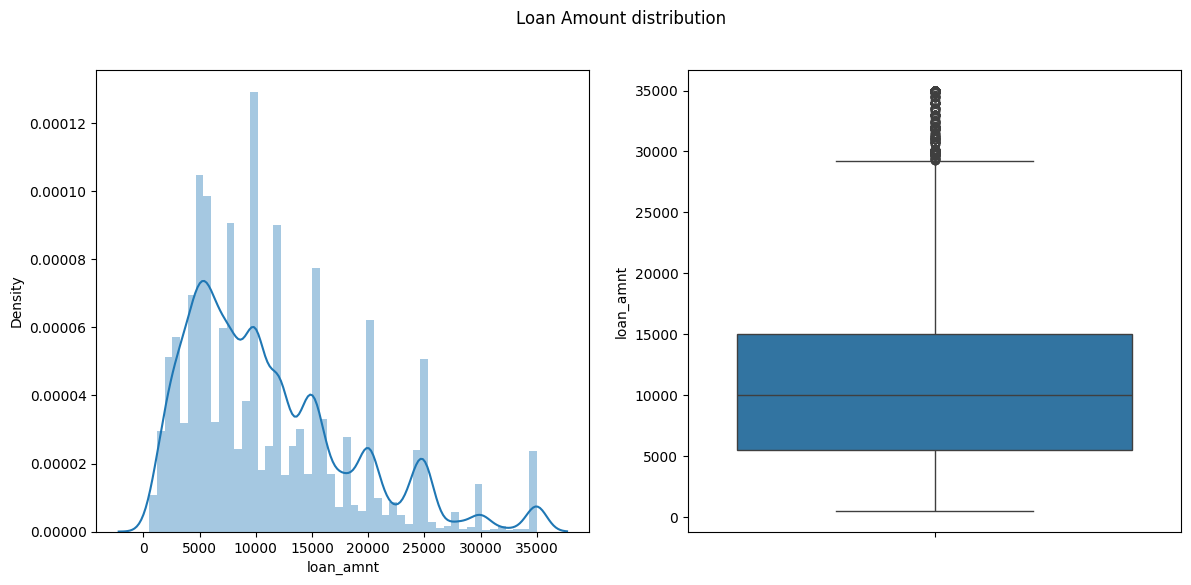

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Loan Amount

plt.figure(figsize=(14,6))
#Setting subplot index
plt.subplot(1,2,1)
#Histogram Plot
sns.distplot(a=loan_data.loan_amnt, kde=True)
plt.subplot(1,2,2)
#Box plot
sns.boxplot(data=loan_data.loan_amnt)
#Single title for both subplots.
plt.suptitle('Loan Amount distribution')
plt.show()

In [ ]:
#Probability of laon amount
loan_data.loan_amnt.describe(percentiles=[0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99])



,loan_amnt
count,36800.00
mean,11149.54
std,7369.86
min,500.00
5%,2400.00
10%,3200.00
25%,5500.00
50%,10000.00
75%,15000.00
90%,22000.00


Observations:
From the above plots, The median loan amount (represented by the line within the box) is around 10,000 to 15,000, aligning with the central peak in the histogram.There is a small proportion of high loan amounts that are outliers, as reflected in both the histogram and box plot.The presence of these outliers indicates that while most loans are modest, some borrowers do take out significantly larger loans.And very few people took more than 30000 loan amount.

<ipython-input-25-3b7cab21b20b>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=loan_data.int_rate, kde=True)


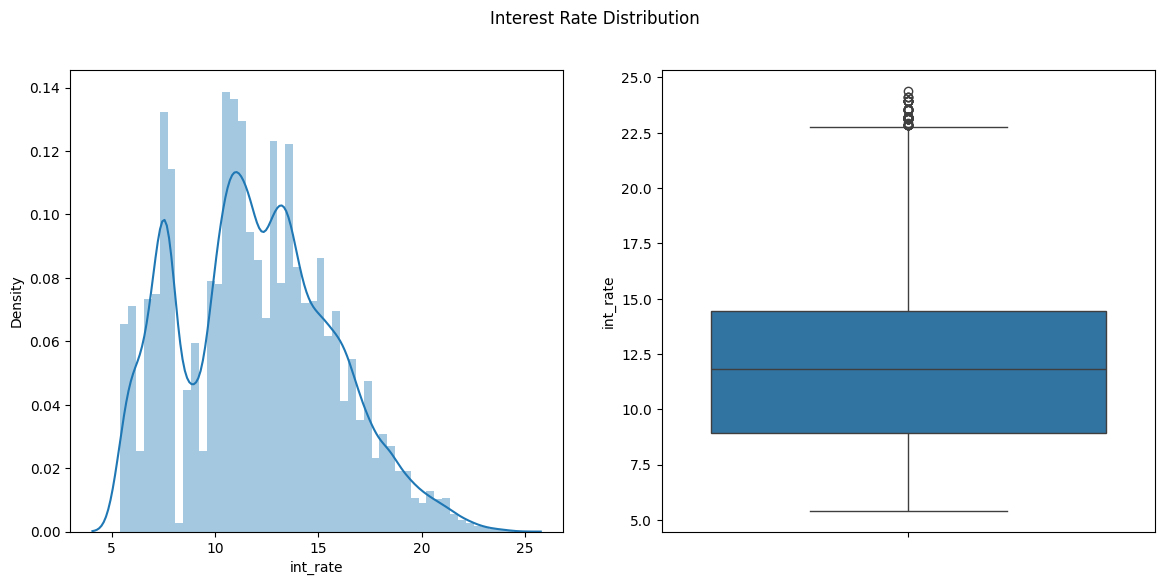

In [ ]:
#Interest Rate
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.distplot(a=loan_data.int_rate, kde=True)
plt.subplot(1,2,2)
sns.boxplot(data=loan_data.int_rate)
plt.suptitle('Interest Rate Distribution')
plt.show()

Observations:
From the above 2 plots,we can conclude that most of the interest rates lies between 9% to 14.5%.The median interest rate is around 12.5.
Some people took loan at higher rates of interest i.e., 22.5%


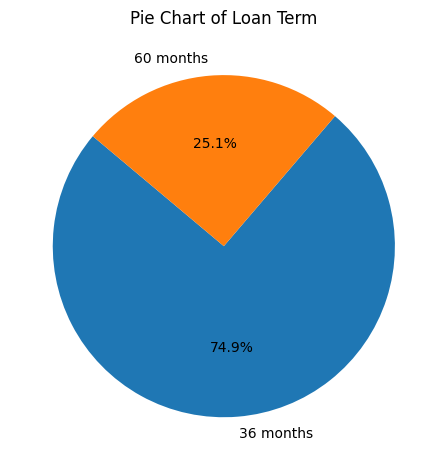

In [ ]:
#Term

plt.subplot(1, 1, 1)
loan_term_counts = loan_data['term'].value_counts()
plt.pie(loan_term_counts, labels=loan_term_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of Loan Term')

# Adjusting layout
plt.tight_layout()
plt.show()

Observations:
Barrowrs took 36 months tenure more than 60 months tenure.

Text(0, 0.5, 'proportion')

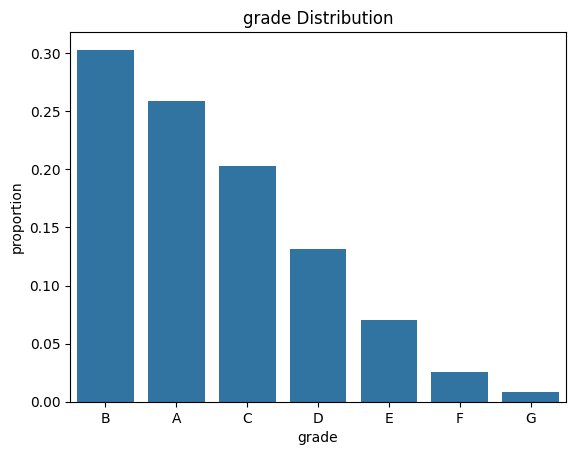

In [ ]:
#Grade
var = 'grade'
#Probability / Percentage of each values
prob_df = loan_data[var].value_counts(normalize=True).reset_index()
prob_df
sns.barplot(x='grade', y='proportion', data=prob_df)

# Set the title and labels
plt.title('grade Distribution')
plt.xlabel('grade')
plt.ylabel('proportion')

Observations:
Most of the borrowers fall under A and B grades then other grades.As the grades move from "B" to "G,
" the frequency decreases. This indicates a general trend of fewer students receiving lower grades.

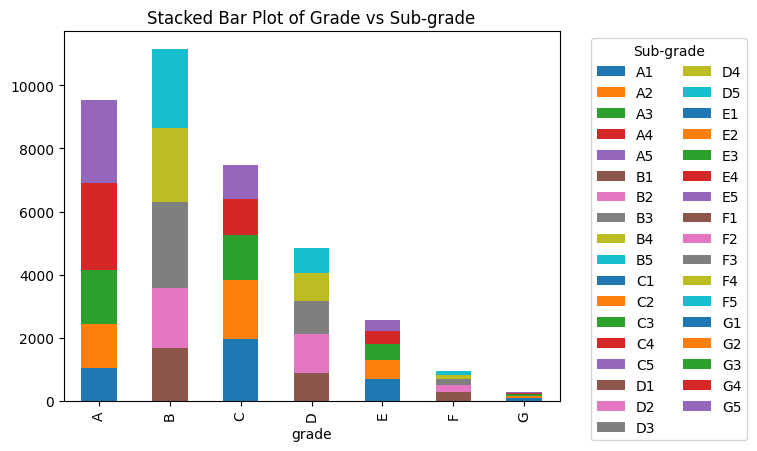

In [ ]:
# Stacked Bar Plot - Grade vs Sub-grade
plt.subplot(1, 1, 1)
sub_grade_counts = loan_data.groupby(['grade', 'sub_grade']).size().unstack().fillna(0)
sub_grade_counts.plot(kind='bar', stacked=True, ax=plt.gca())

# Move the legend outside the plot
plt.legend(title='Sub-grade', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

plt.title('Stacked Bar Plot of Grade vs Sub-grade')


plt.show()

Observation:Grade Distribution:
The overall distribution of grades is skewed to the left, with a larger proportion of grades in the "A" and "B" categories compared to the lower grades.
Sub-Grade Distribution: Within each grade, the distribution of sub-grades varies. For example, grade "A" has a higher proportion of sub-grades starting with "A," while grade "D" has a higher proportion of sub-grades starting with "D."
Trends: There appears to be a general trend where sub-grades within a grade are ordered in a way that reflects the overall grade level. For example, within grade "B," sub-grades starting with "B" are more frequent than those starting with "A" or "C."

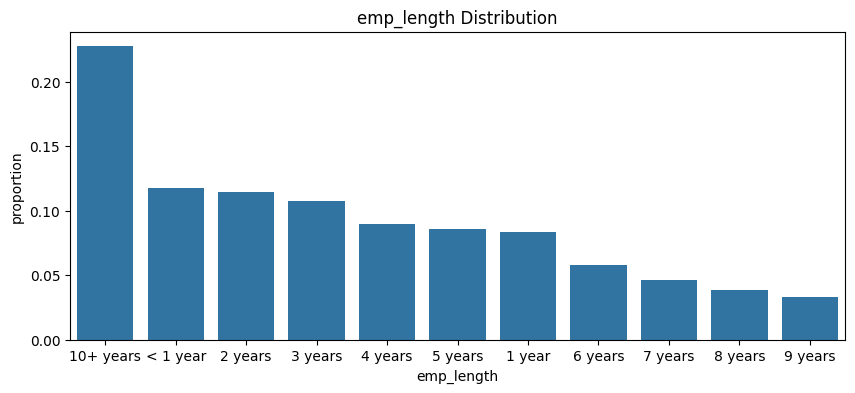

In [ ]:
#Employment length
plt.figure(figsize=(10,4))
var = 'emp_length'
#Probability / Percentage of each values
prob_df = loan_data[var].value_counts(normalize=True).reset_index()
prob_df
sns.barplot(x='emp_length', y='proportion', data=prob_df)
plt.xlabel(var)
plt.ylabel('proportion')
plt.title(var+' Distribution')
plt.show()

Observations:
Borrowers are mostly 10+ years emploment length.

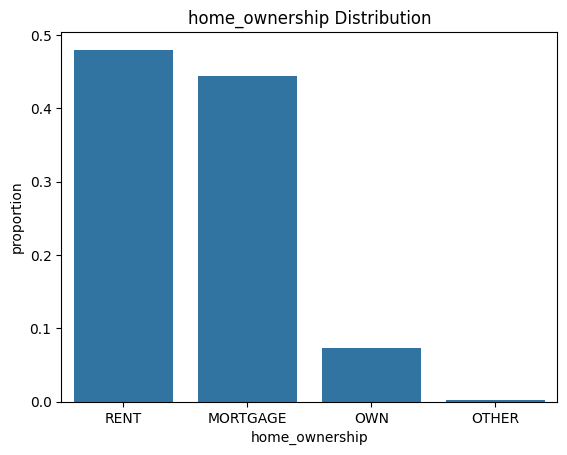

In [ ]:
#Home Ownership
var = 'home_ownership'
#Probability / Percentage of each values
prob_df = loan_data[var].value_counts(normalize=True).reset_index()
#Plotting percentage proporation vs home ownership
sns.barplot(x='home_ownership', y='proportion', data=prob_df)
plt.xlabel(var)
plt.ylabel('proportion')
plt.title(var+' Distribution')
plt.show()

Observations:
The loan borrowers are mostly having rented and mortgage houses.

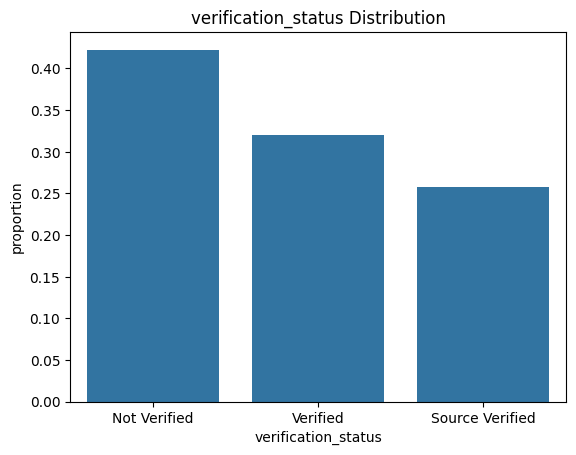

In [ ]:
#Verification Status
var = 'verification_status'
#Probability / Percentage of each values
prob_df = loan_data[var].value_counts(normalize=True).reset_index()

sns.barplot(x='verification_status', y='proportion', data=prob_df)
plt.xlabel(var)
plt.ylabel('proportion')
plt.title(var+' Distribution')
plt.show()

Observations:
Majority of loans were given without verification of applicants income.

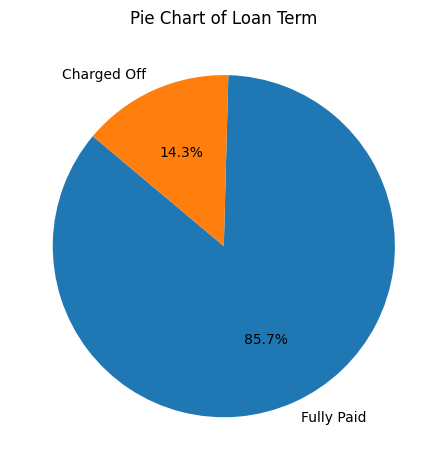

In [ ]:
#Loan Status
plt.subplot(1, 1, 1)
loan_term_counts = loan_data['loan_status'].value_counts()
plt.pie(loan_term_counts, labels=loan_term_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of Loan Term')

# Adjusting layout
plt.tight_layout()
plt.show()

Observations:
82.8% of borrowers has paid the loan fully. where are 17% are defaulted the loan.

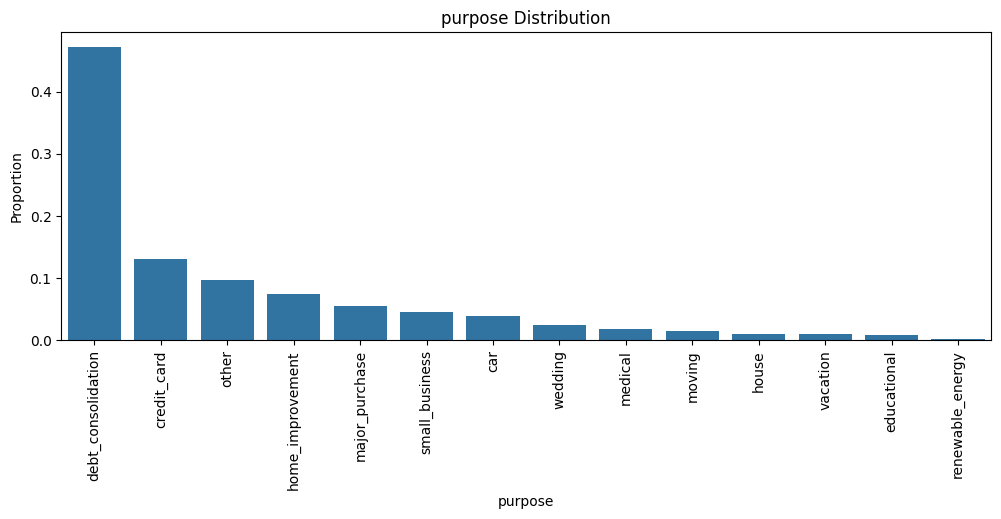

In [ ]:
#Purpose
plt.figure(figsize=(12,4))
var = 'purpose'
#Probability / Percentage of each values
prob_df = loan_data[var].value_counts(normalize=True).reset_index()

sns.barplot(x='purpose', y='proportion', data=prob_df)
plt.xlabel(var)
plt.xticks(rotation=90)
plt.ylabel('Proportion')
plt.title(var+' Distribution')
plt.show()

Observations:
This chart shows people took loan for debt consolidation and a very few people took for renewable energy


<ipython-input-34-96f2a3351732>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=loan_data.funded_amnt, rug=True)


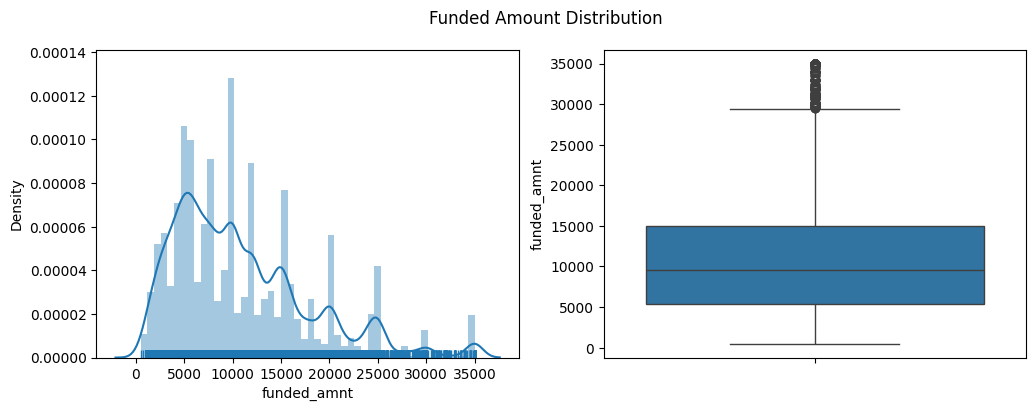

In [ ]:
#Funded Amount

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.distplot(a=loan_data.funded_amnt, rug=True)
plt.subplot(1,2,2)
sns.boxplot(data=loan_data.funded_amnt)
plt.suptitle('Funded Amount Distribution')
plt.show()

In [ ]:
#stats of Funded Amount
loan_data.funded_amnt.describe(percentiles=[0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99])

,funded_amnt
count,36800.00
mean,10880.79
std,7109.16
min,500.00
5%,2400.00
10%,3200.00
25%,5400.00
50%,9600.00
75%,15000.00
90%,20375.00


Observations:
Funded amount data behaves similar to loan Amount, Which tells us that Lending club approved most of Applied loan amount.

<ipython-input-36-3a6f315c8e7b>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=loan_data.funded_amnt_inv, rug=True)


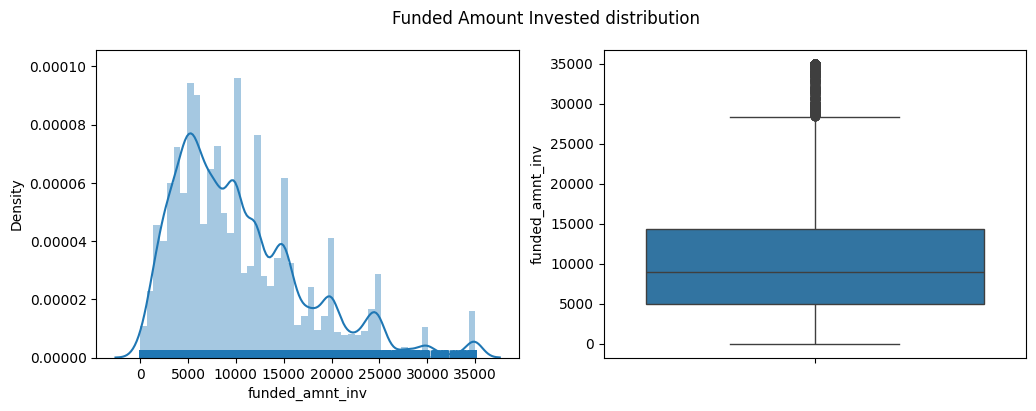

In [ ]:
#funded_amnt_inv
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.distplot(a=loan_data.funded_amnt_inv, rug=True)
plt.subplot(1,2,2)
sns.boxplot(data=loan_data.funded_amnt_inv)
plt.suptitle('Funded Amount Invested distribution')
plt.show()

In [ ]:
#stats of funded_amnt_inv
loan_data.funded_amnt_inv.describe(percentiles=[0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99])

,funded_amnt_inv
count,36800.00
mean,10439.06
std,7008.52
min,0.00
5%,2000.00
10%,3000.00
25%,5000.00
50%,9000.00
75%,14350.00
90%,20000.00


Observations:
Funded amount investment data behaves similar to loan Amount, Which tells us that Lending club approved atmost of Applied loan amount.


<ipython-input-38-6ab914c8432c>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=loan_data.approved_loan_amnt_ratio)


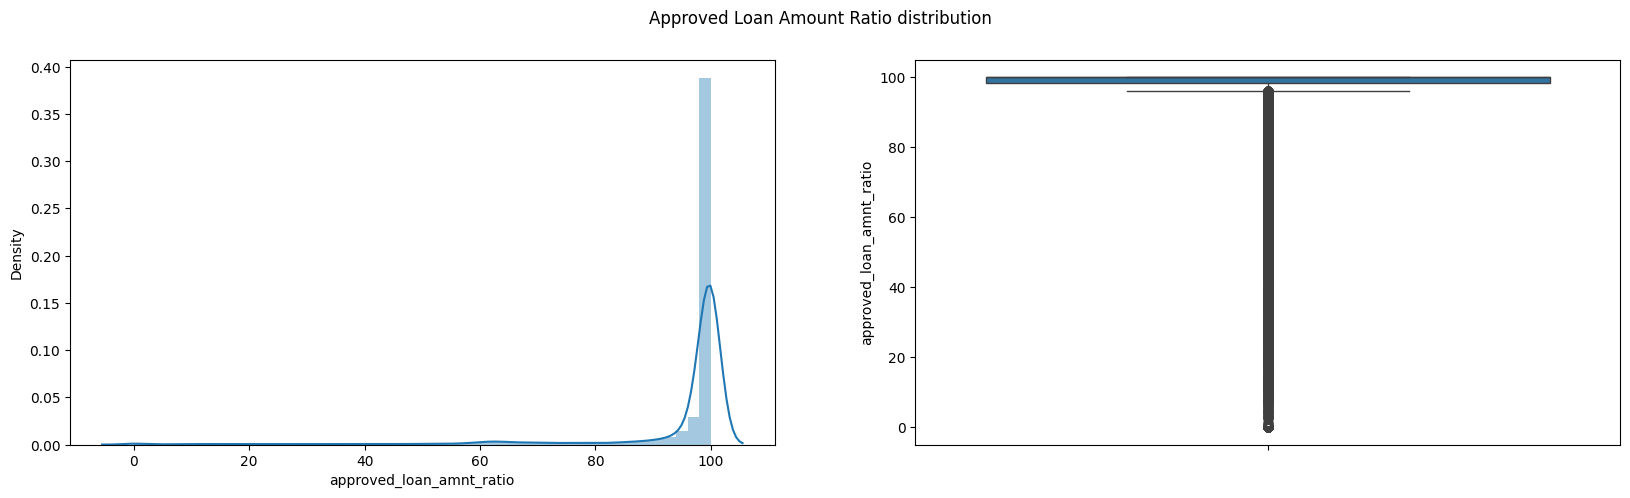

In [ ]:
#Approved Loan Amount Ratio
loan_data['approved_loan_amnt_ratio'] = round(loan_data.funded_amnt_inv*100/loan_data.loan_amnt,2)
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.distplot(a=loan_data.approved_loan_amnt_ratio)
plt.subplot(1,2,2)
sns.boxplot(data=loan_data.approved_loan_amnt_ratio)
plt.suptitle('Approved Loan Amount Ratio distribution')
plt.show()

Observations: 70% of Borrowers got 100% loan amount from investors.

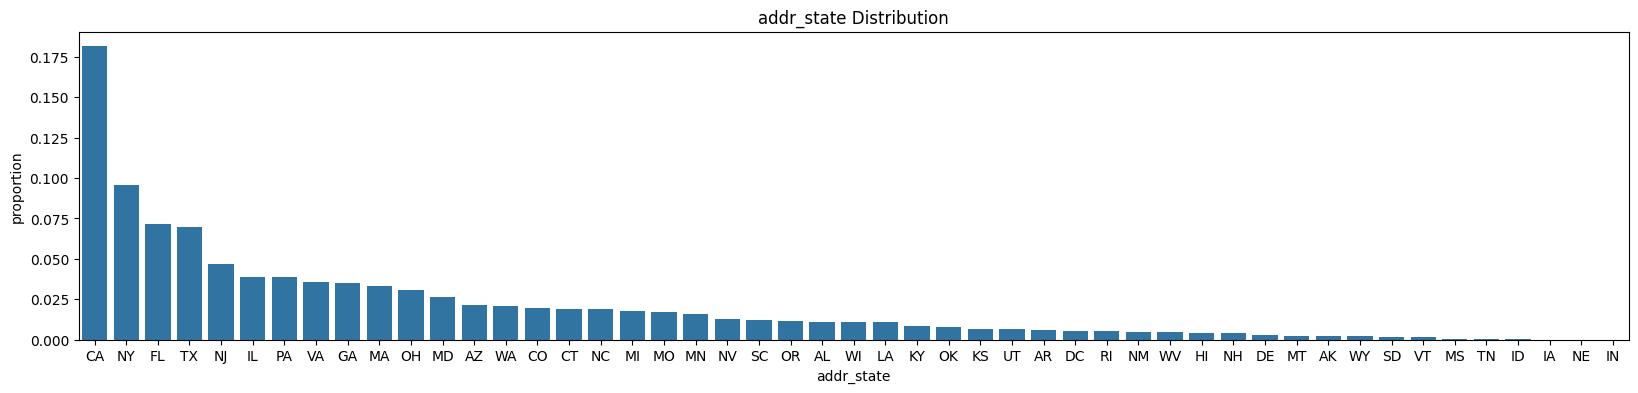

In [ ]:
#Borrower's State (add_state)
plt.figure(figsize=(20,4))
var = 'addr_state'
#Probability / Percentage of each values
prob_df = loan_data[var].value_counts(normalize=True).reset_index()

sns.barplot(x='addr_state', y='proportion', data=prob_df)
plt.xlabel(var)
plt.ylabel('proportion')
plt.title(var+' Distribution')
plt.show()

Observations:
Most of the borrowers are from CA and NY

Segmented Univariate Analysis

<Axes: title={'center': 'Grade vs Loan Amount'}, xlabel='grade', ylabel='loan_amnt'>

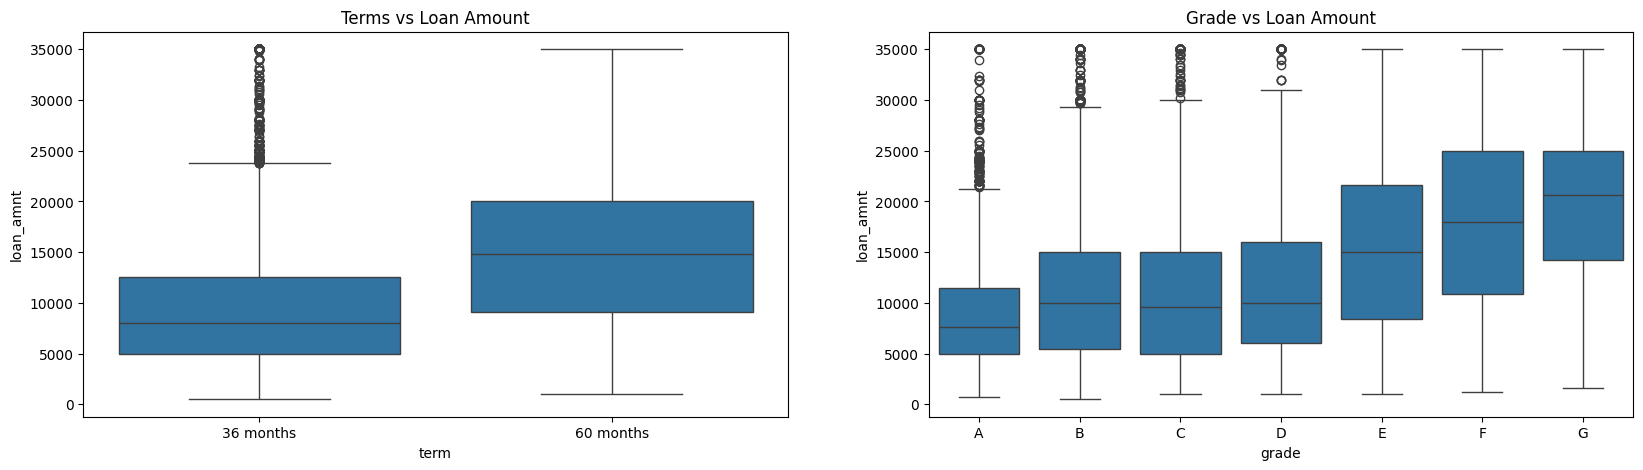

In [ ]:
#Loan Amount
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='term', y=loan_data.loan_amnt, data=loan_data)
plt.title('Terms vs Loan Amount')
plt.subplot(122)
plt.title('Grade vs Loan Amount')
#Finding grades with sorted alphabetical order
grade_ord = loan_data.grade.unique()
grade_ord.sort()
sns.boxplot(x='grade', y=loan_data.loan_amnt, order = grade_ord, data=loan_data)

Observations:
Higher amount loans have high tenure i.e, 60 months.
Grade 'G' and 'H' have taken max loan amount. As Grades are decreasing the loan amount is increasing.

<Axes: title={'center': 'verification_status vs Loan Amount'}, xlabel='verification_status', ylabel='loan_amnt'>

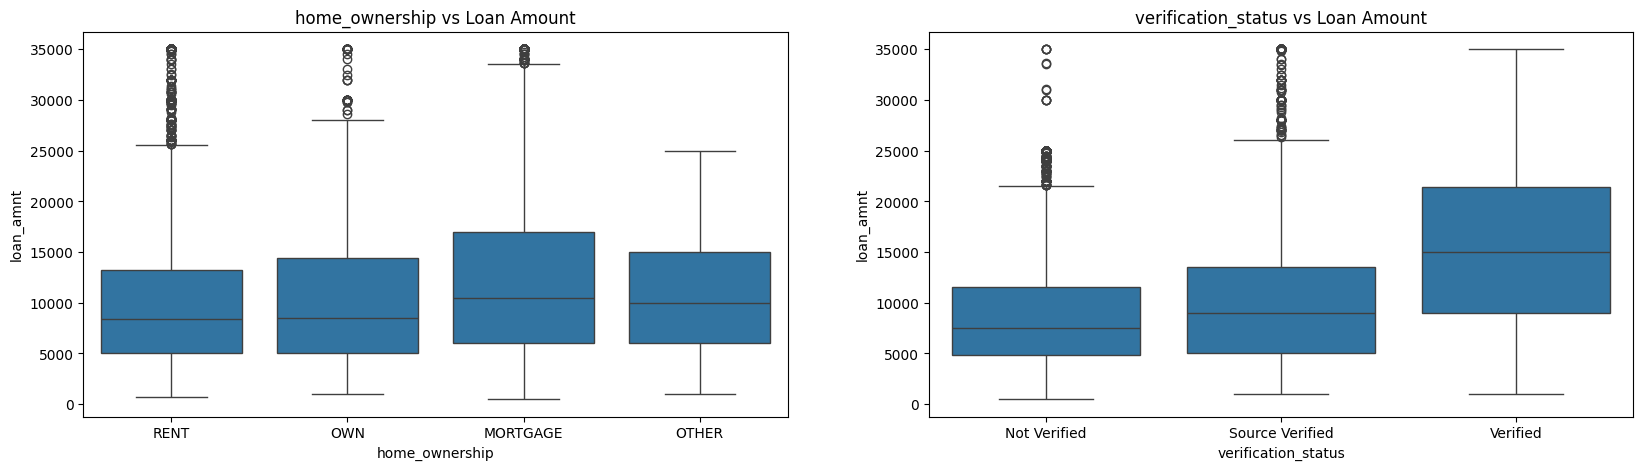

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='home_ownership', y=loan_data.loan_amnt, data=loan_data)
plt.title('home_ownership vs Loan Amount')
plt.subplot(122)
plt.title('verification_status vs Loan Amount')
verification_status_ord = loan_data.verification_status.unique()
verification_status_ord.sort()
sns.boxplot(x='verification_status', y=loan_data.loan_amnt, order = verification_status_ord, data=loan_data)

Observations:
more borrowers are from MORTAGE and also the median loan amount also high for MORTAGE owned borrowers.
And most of borrowers are verified for borrowing loan >9k


Text(0.5, 1.0, 'loan_status vs Loan Amount')

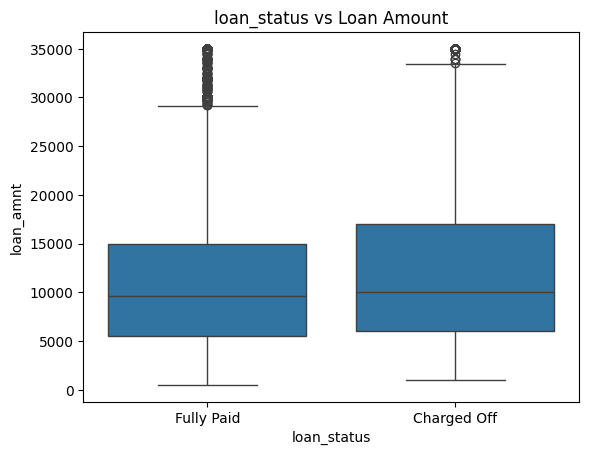

In [ ]:
sns.boxplot(x='loan_status', y=loan_data.loan_amnt, data=loan_data)
plt.title('loan_status vs Loan Amount')

Observations:
Charged Off loans have higher amounts than Fully Paid ones.

Text(0.5, 1.0, 'purpose vs Loan Amount')

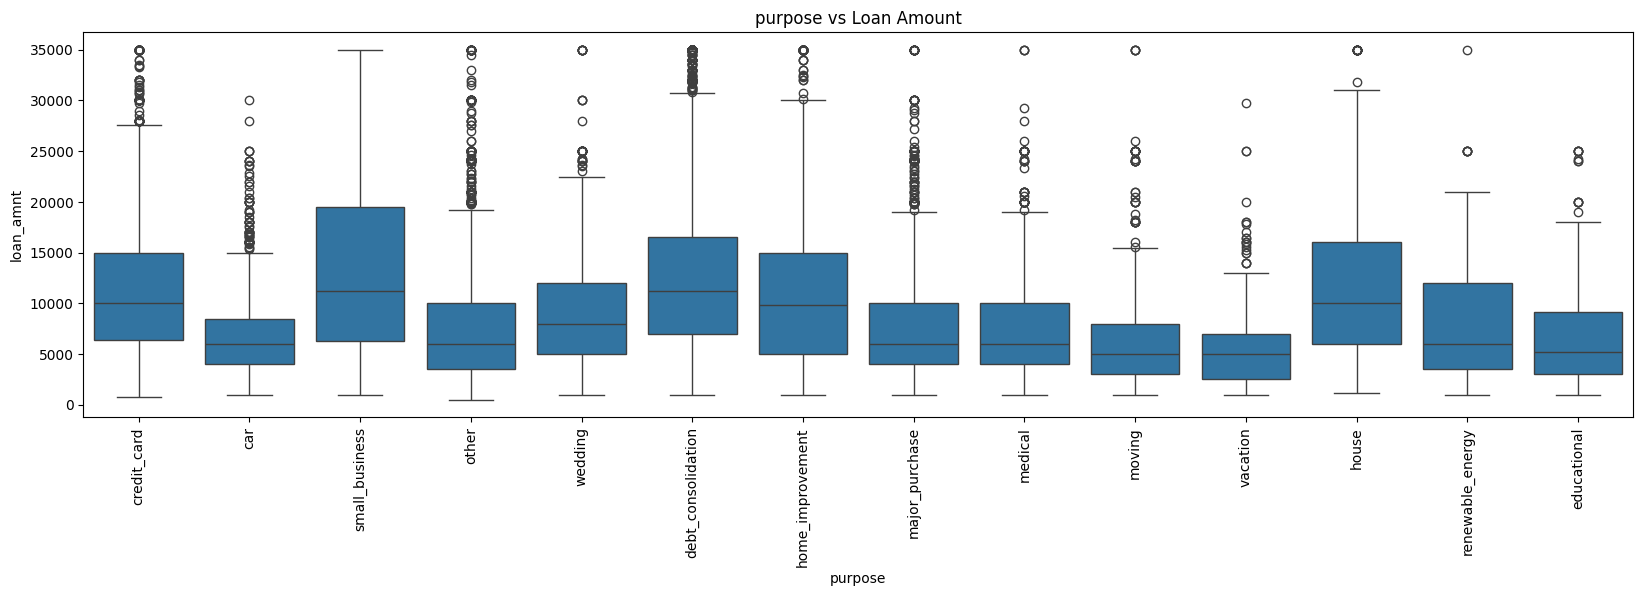

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='purpose', y=loan_data.loan_amnt, data=loan_data)
#Rotating x values 90 for better visibility
plt.xticks(rotation=90)
plt.title('purpose vs Loan Amount')

Observations:
More loan amount is from Small bussiness followed by debt consolidation.

Text(0.5, 1.0, 'emp_length vs Loan Amount')

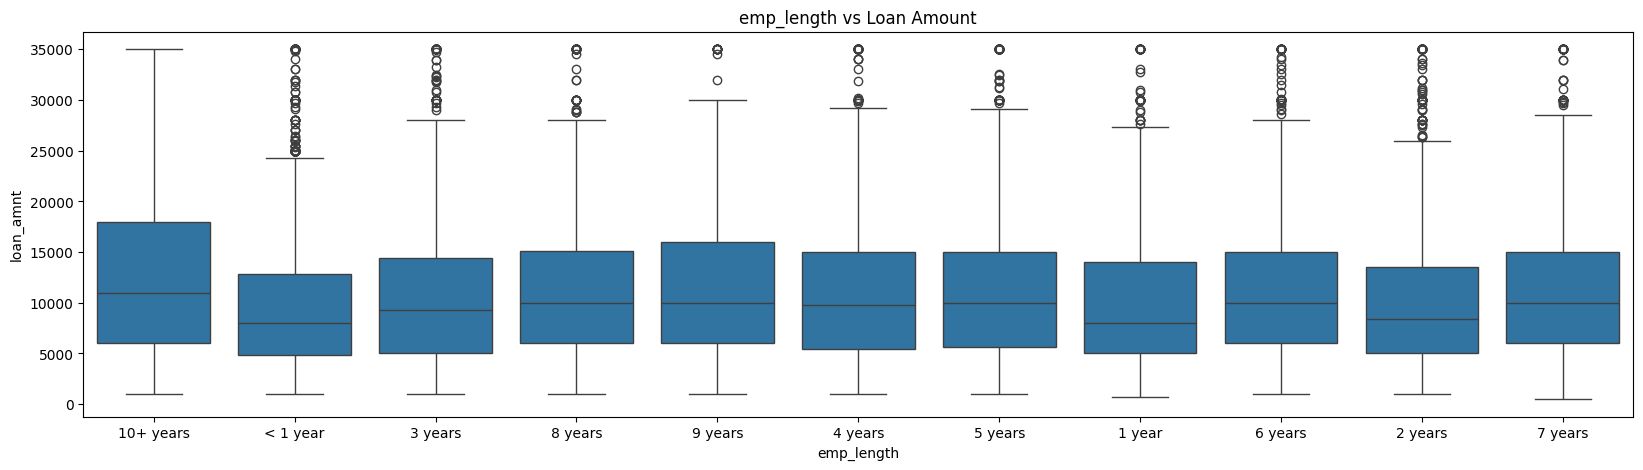

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='emp_length', y=loan_data.loan_amnt, data=loan_data)
plt.title('emp_length vs Loan Amount')

Observations:
more borrowers are from 10+ years and least is <1 year

In [ ]:
#issue_d column
loan_data['issue_d_year'] = loan_data.issue_d.dt.year
loan_data['issue_d_month'] = loan_data.issue_d.dt.strftime('%b')
loan_data['issue_d_weekday'] = loan_data.issue_d.dt.weekday
#data type conversion of year and weekday
loan_data['issue_d_year'] = loan_data['issue_d_year'].astype(object)
loan_data['issue_d_weekday'] = loan_data['issue_d_weekday'].astype(object)

#earliest_cr_line
loan_data['earliest_cr_line_year'] = loan_data.earliest_cr_line.dt.year
loan_data['earliest_cr_line_month'] = loan_data.earliest_cr_line.dt.strftime('%b')
#data type conversion of year and weekday
loan_data['earliest_cr_line_year'] = loan_data['earliest_cr_line_year'].astype(object)

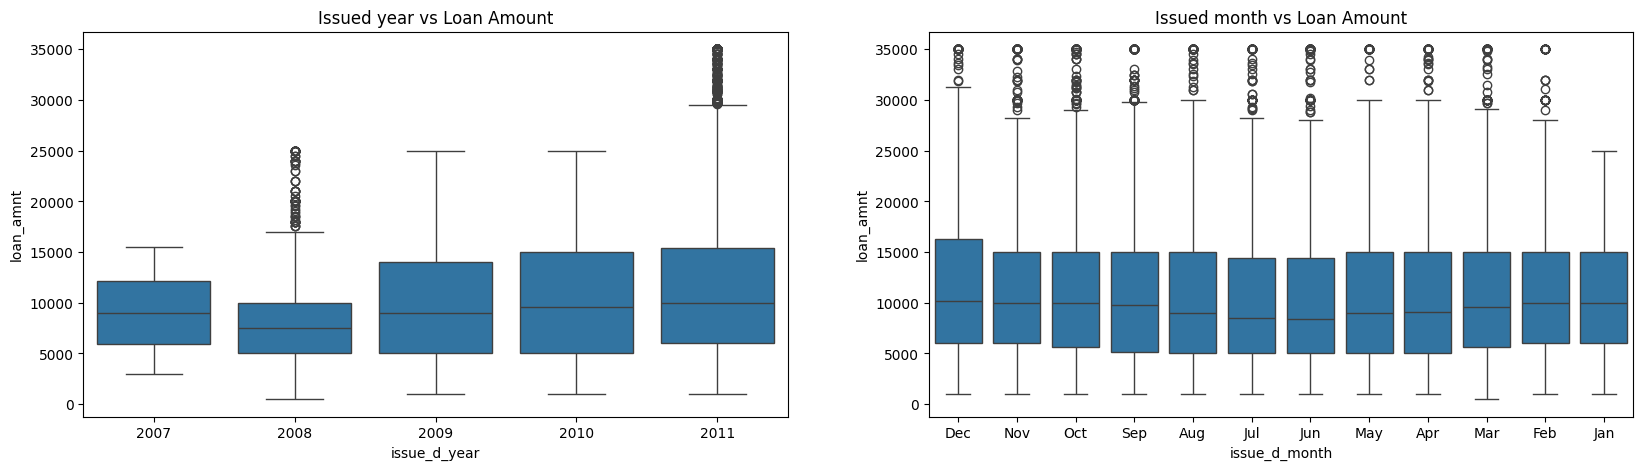

In [ ]:
#Issue_d
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x=loan_data.issue_d_year, y=loan_data.loan_amnt, data=loan_data)
plt.title('Issued year vs Loan Amount')
plt.subplot(122)
sns.boxplot(x=loan_data.issue_d_month, y=loan_data.loan_amnt, data=loan_data)
plt.title('Issued month vs Loan Amount')
plt.show()

Observations:

    The meadian loan amount in each year did not change much but the distribution is more spread as the years increase, which means people have taken different loan amounts in each year.
    Few Loan borrowers took heigher loan amount in 2008 and 2011 which are plotted as ouliers.
    Loan borrowers took almost similar amounts in all the months except in December, people have taken heigher amounts as distribution is high above median.



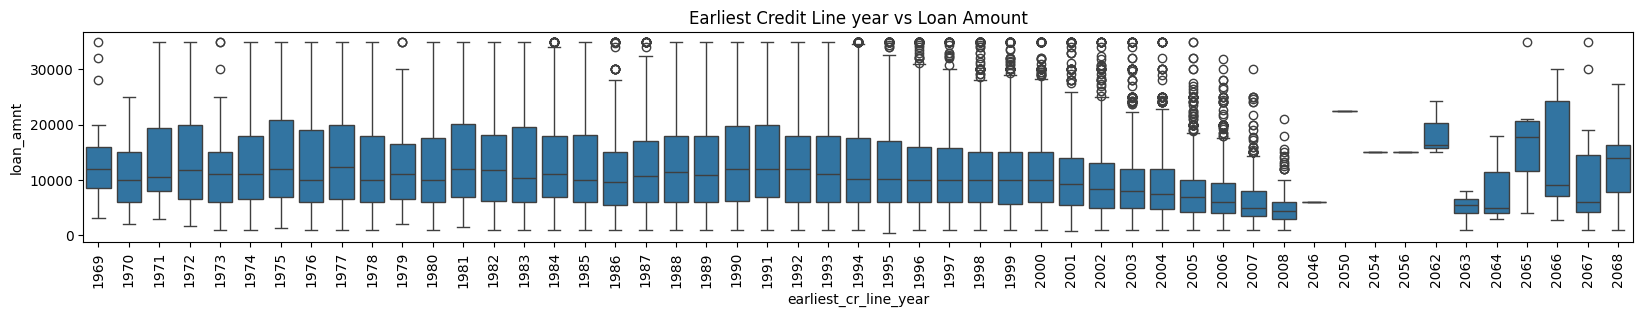

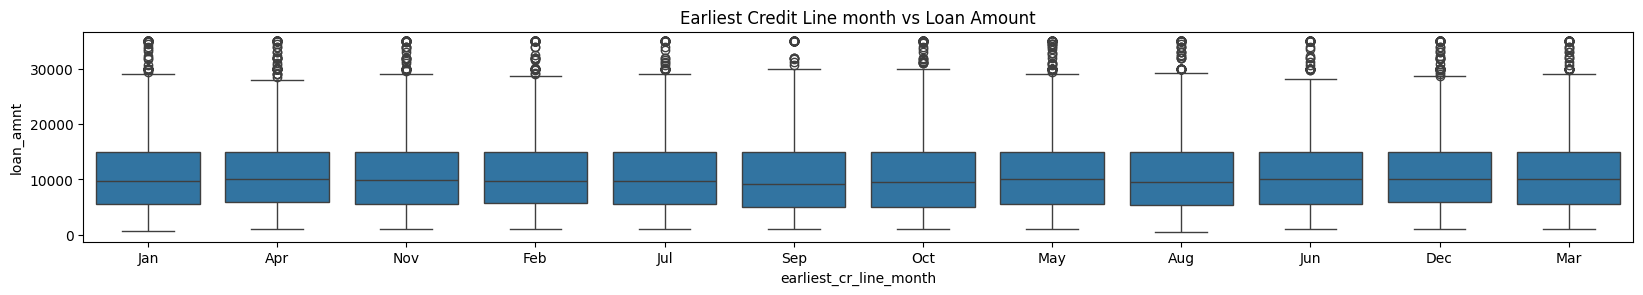

In [ ]:
#earliest_cr_line
plt.figure(figsize=(20,6))
plt.subplot(211)
sns.boxplot(x=loan_data.earliest_cr_line_year, y=loan_data.loan_amnt, data=loan_data)
plt.xticks(rotation=90)
plt.title('Earliest Credit Line year vs Loan Amount')
plt.figure(figsize=(20,6))
plt.subplot(212)
sns.boxplot(x=loan_data.earliest_cr_line_month, y=loan_data.loan_amnt, data=loan_data)
plt.title('Earliest Credit Line month vs Loan Amount')
plt.show()

<Axes: title={'center': 'Grade vs funded amount'}, xlabel='grade', ylabel='funded_amnt'>

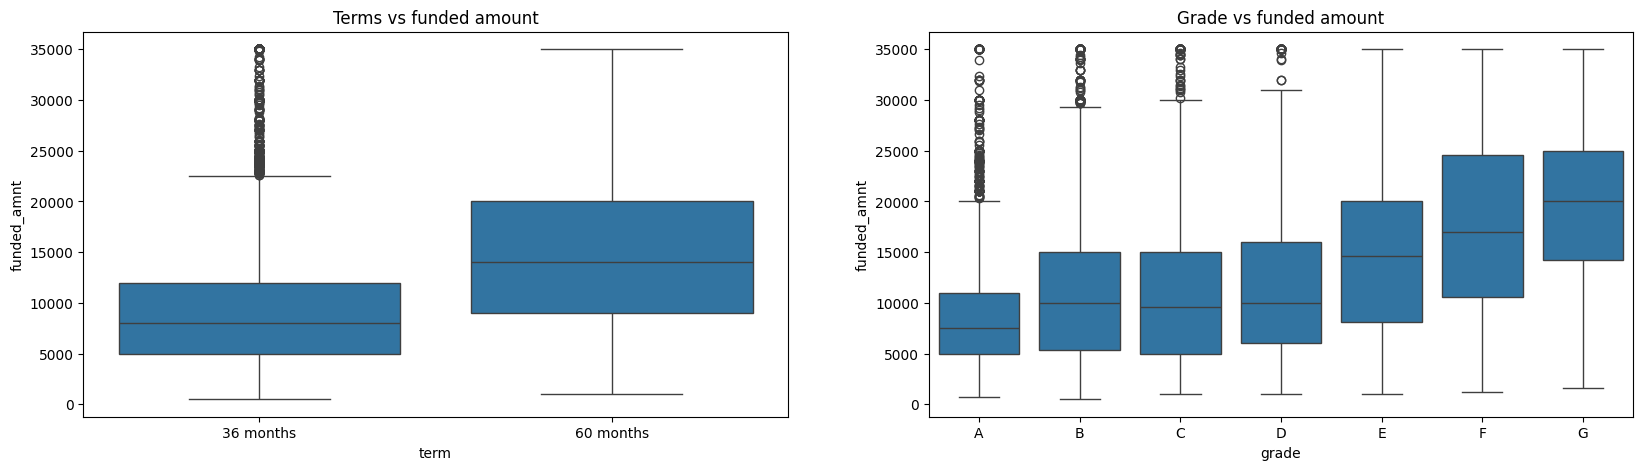

In [ ]:
#funded_amnt
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='term', y=loan_data.funded_amnt, data=loan_data)
plt.title('Terms vs funded amount')
plt.subplot(122)
plt.title('Grade vs funded amount')
grade_ord = loan_data.grade.unique()
grade_ord.sort()
sns.boxplot(x='grade', y=loan_data.funded_amnt, order = grade_ord, data=loan_data)

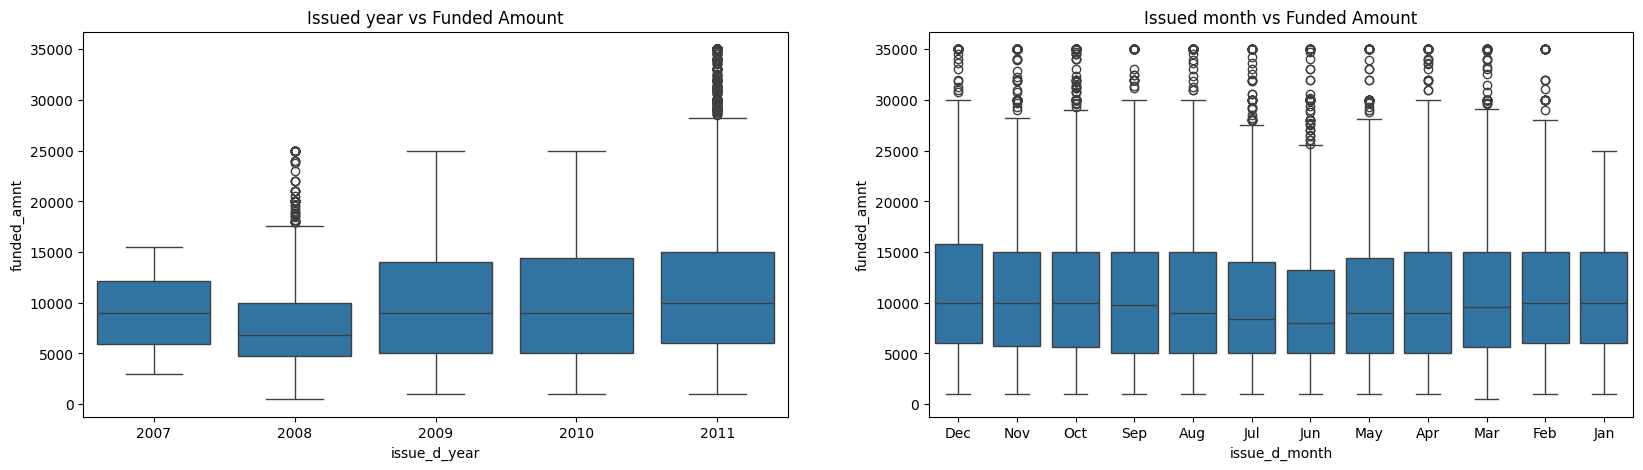

In [ ]:
#Issue_d
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x=loan_data.issue_d_year, y=loan_data.funded_amnt, data=loan_data)
plt.title('Issued year vs Funded Amount')
plt.subplot(122)
sns.boxplot(x=loan_data.issue_d_month, y=loan_data.funded_amnt, data=loan_data)
plt.title('Issued month vs Funded Amount')
plt.show()

Text(0.5, 1.0, 'loan_status vs Funded amnt')

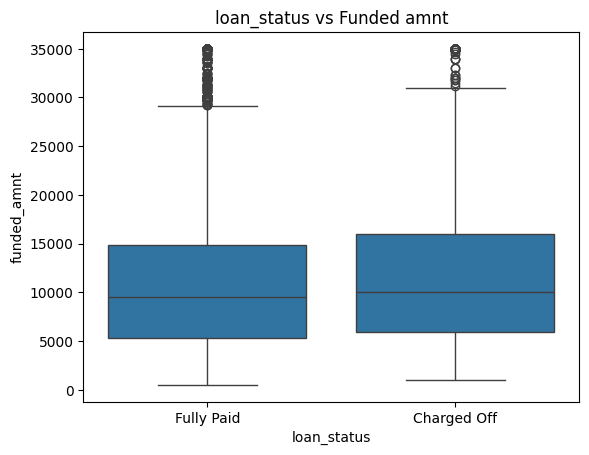

In [ ]:
sns.boxplot(x='loan_status', y=loan_data.funded_amnt, data=loan_data)
plt.title('loan_status vs Funded amnt')

Text(0.5, 1.0, 'purpose vs funded amount')

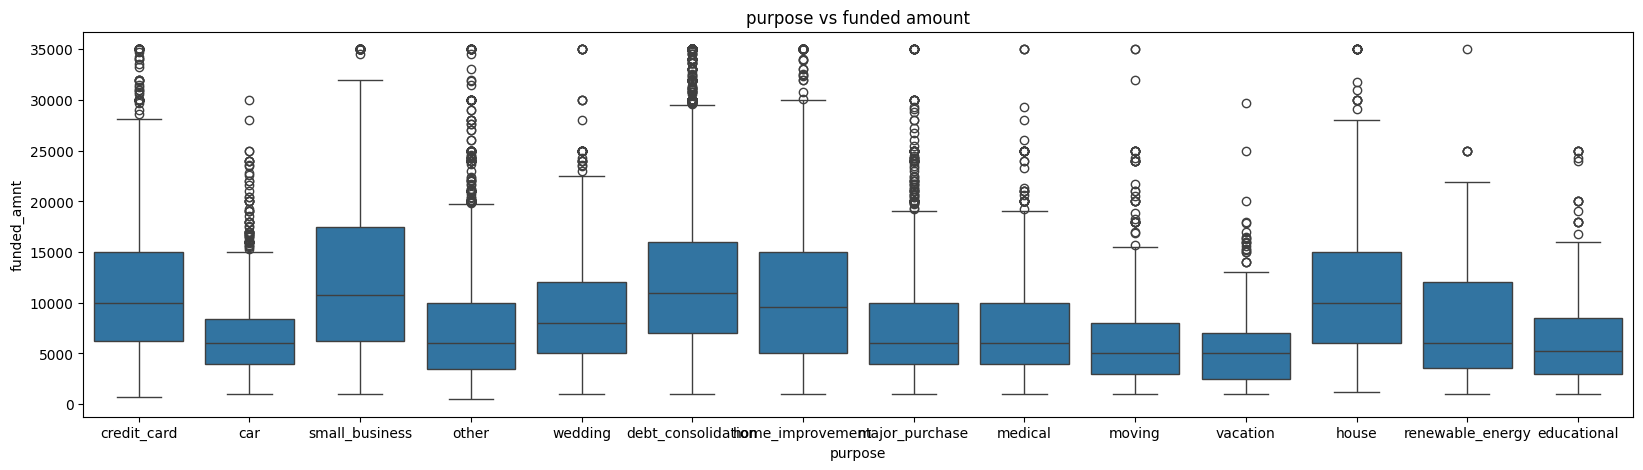

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='purpose', y=loan_data.funded_amnt, data=loan_data)
plt.title('purpose vs funded amount')

Text(0.5, 1.0, 'emp_length vs funded amount')

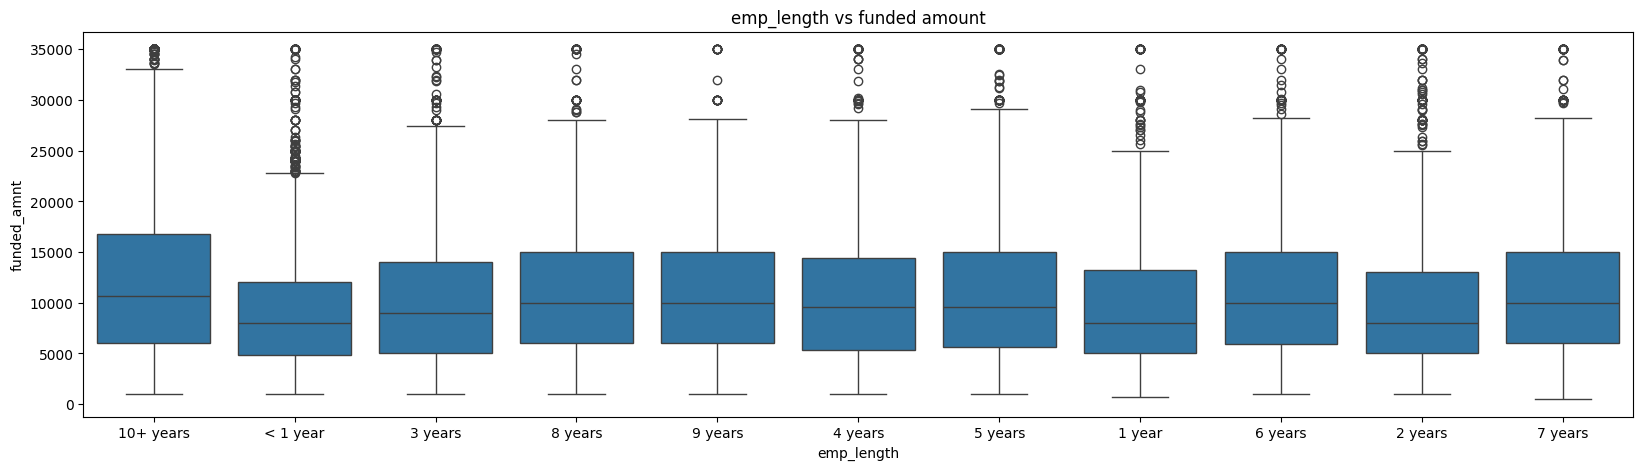

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='emp_length', y=loan_data.funded_amnt, data=loan_data)
plt.title('emp_length vs funded amount')

Observations:
The Funded Amount has similar observations as Loan Amount.

<Axes: title={'center': 'Grade vs Interest Rate'}, xlabel='grade', ylabel='int_rate'>

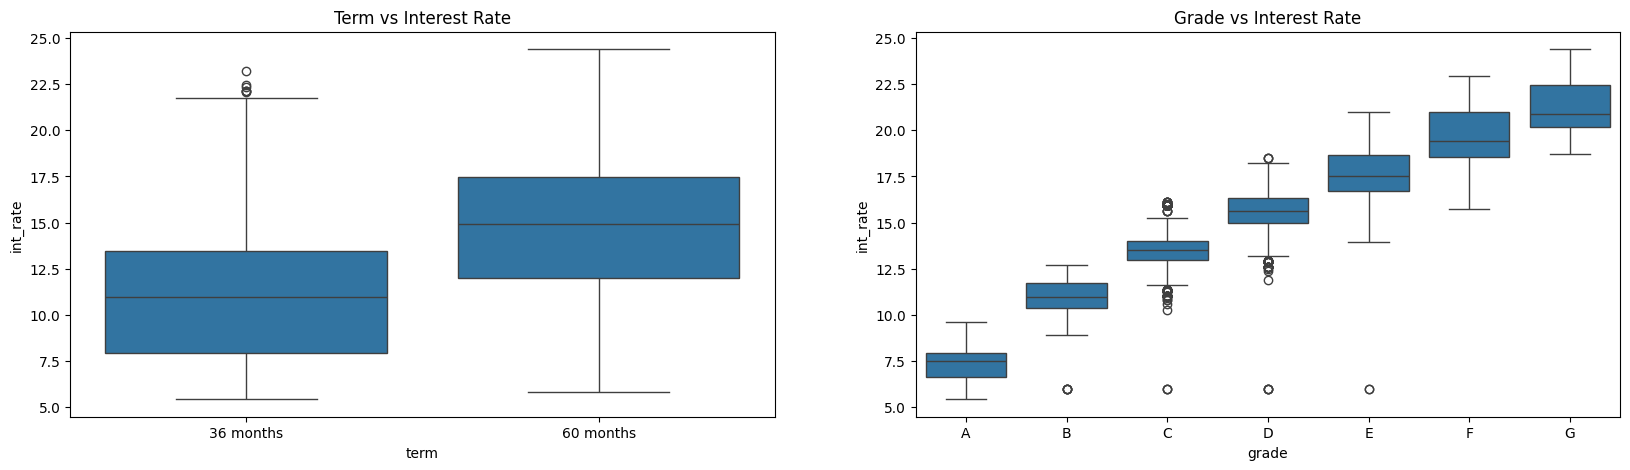

In [ ]:
#int_rate
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='term', y=loan_data.int_rate, data=loan_data)
plt.title('Term vs Interest Rate')
plt.subplot(122)
plt.title('Grade vs Interest Rate')
grade_ord = loan_data.grade.unique()
grade_ord.sort()
sns.boxplot(x='grade', y=loan_data.int_rate, order = grade_ord, data=loan_data)

Observation:
The interest rates are higher for Higher tenure loans.
And Also Interest Rates are Higher as Grades are Lowering (A to G).

<Axes: title={'center': 'verification_status vs Interest Rate'}, xlabel='verification_status', ylabel='int_rate'>

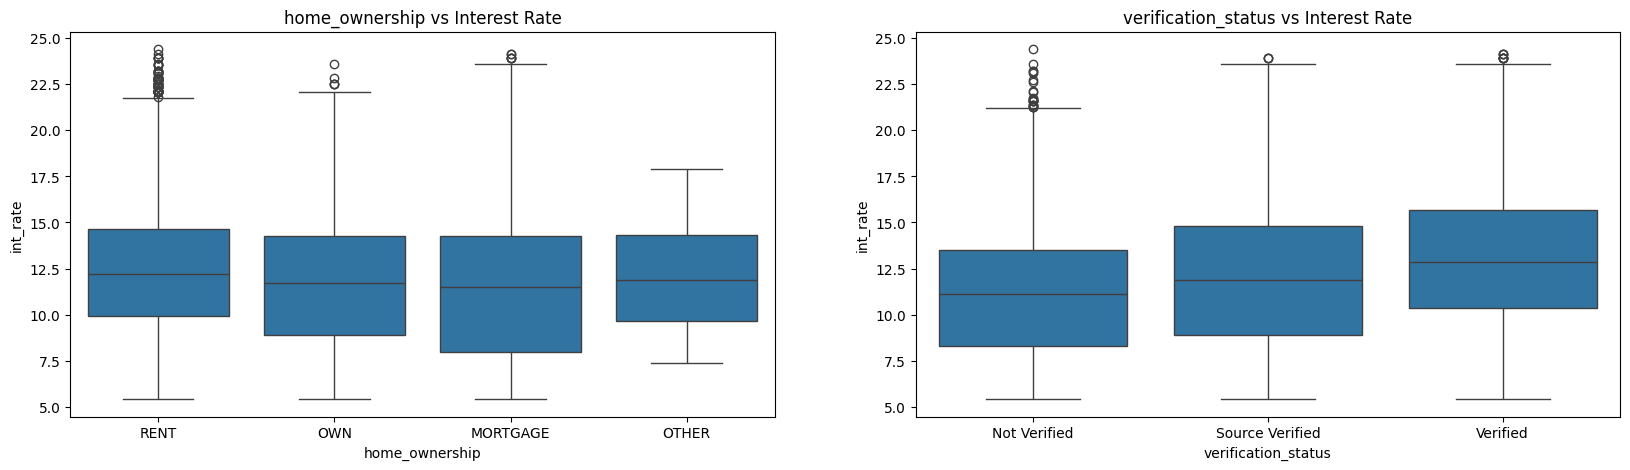

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='home_ownership', y=loan_data.int_rate, data=loan_data)
plt.title('home_ownership vs Interest Rate')
plt.subplot(122)
plt.title('verification_status vs Interest Rate')
verification_status_ord = loan_data.verification_status.unique()
verification_status_ord.sort()
sns.boxplot(x='verification_status', y=loan_data.int_rate, order = verification_status_ord, data=loan_data)

Observations:

    Barrowers with Own and Mortgage got loans with less interest rates as the security will be there.
    And The Non Verified Barrowers got less interest rates compared to Verified and Source Verified barrowers.



Text(0.5, 1.0, 'loan_status vs Interest Rate')

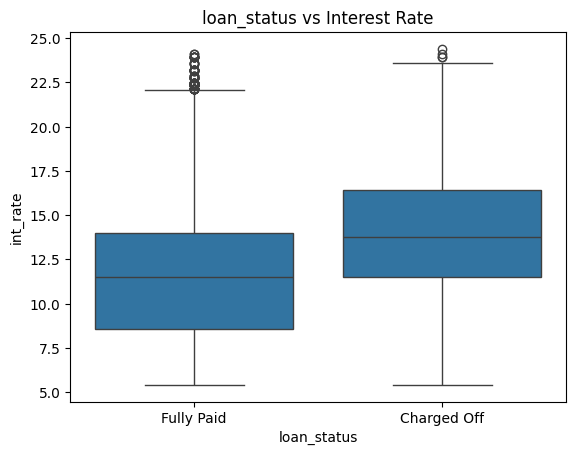

In [ ]:
sns.boxplot(x='loan_status', y=loan_data.int_rate, data=loan_data)
plt.title('loan_status vs Interest Rate')

Observations:
This clearly tells us, grater the interest rate more the chance of Defaulting the loan.

Text(0.5, 1.0, 'purpose vs Interest Rate')

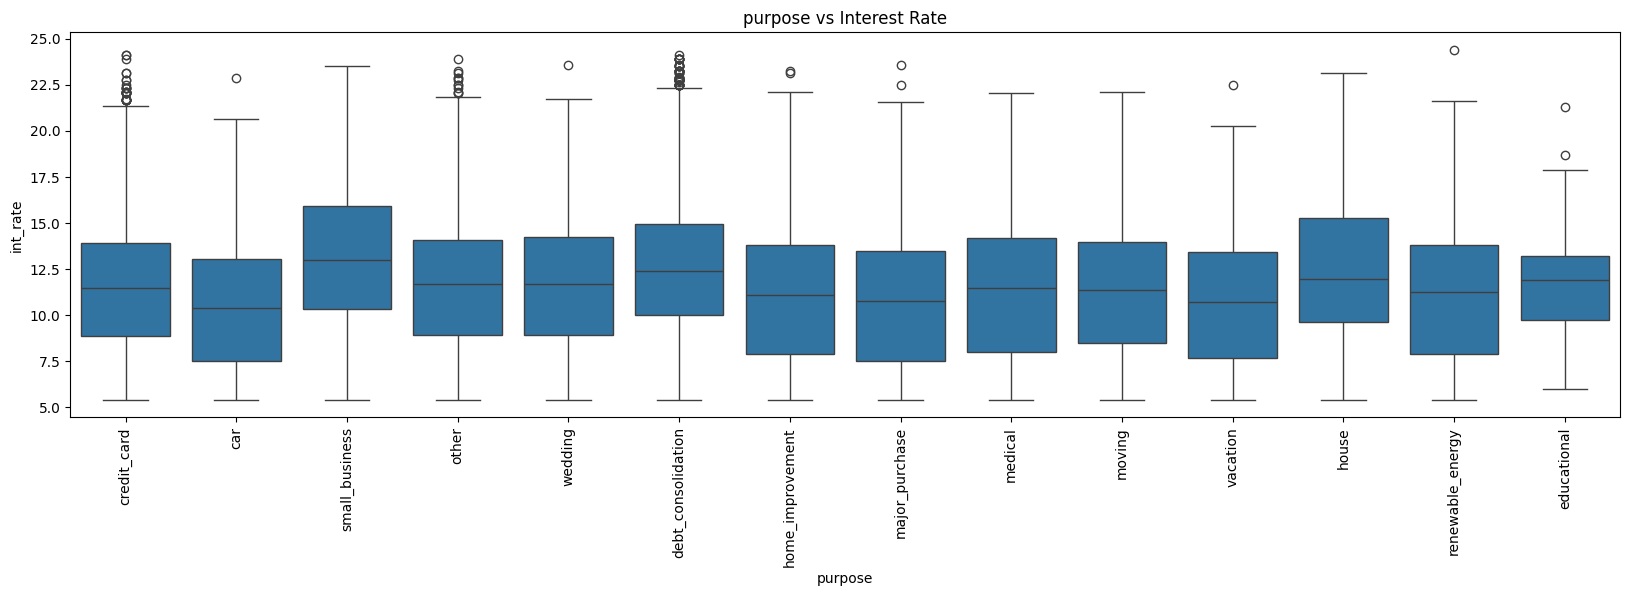

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='purpose', y=loan_data.int_rate, data=loan_data)
plt.xticks(rotation=90)
plt.title('purpose vs Interest Rate')

Observations:
Small Business, Debt Consolidation and House loans are given with more interest rates comparativesly others.

Text(0.5, 1.0, 'emp_length vs Interest Rate')

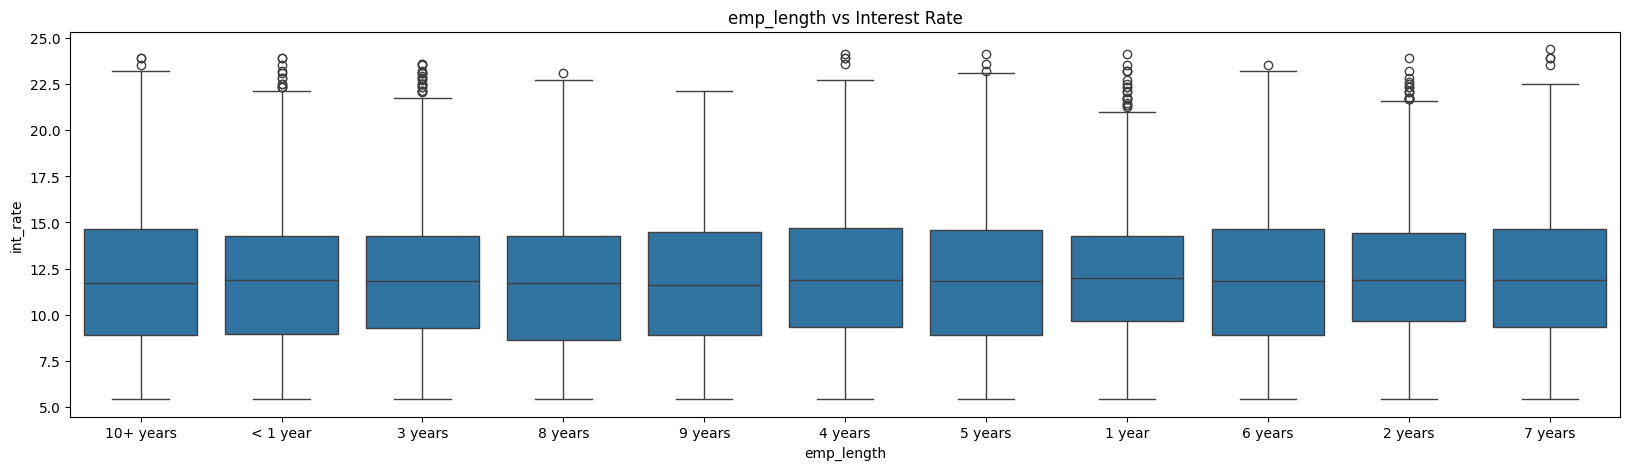

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='emp_length', y=loan_data.int_rate, data=loan_data)
plt.title('emp_length vs Interest Rate')

Observations:
Looks like there is no much relation between Employment length and interest rate.

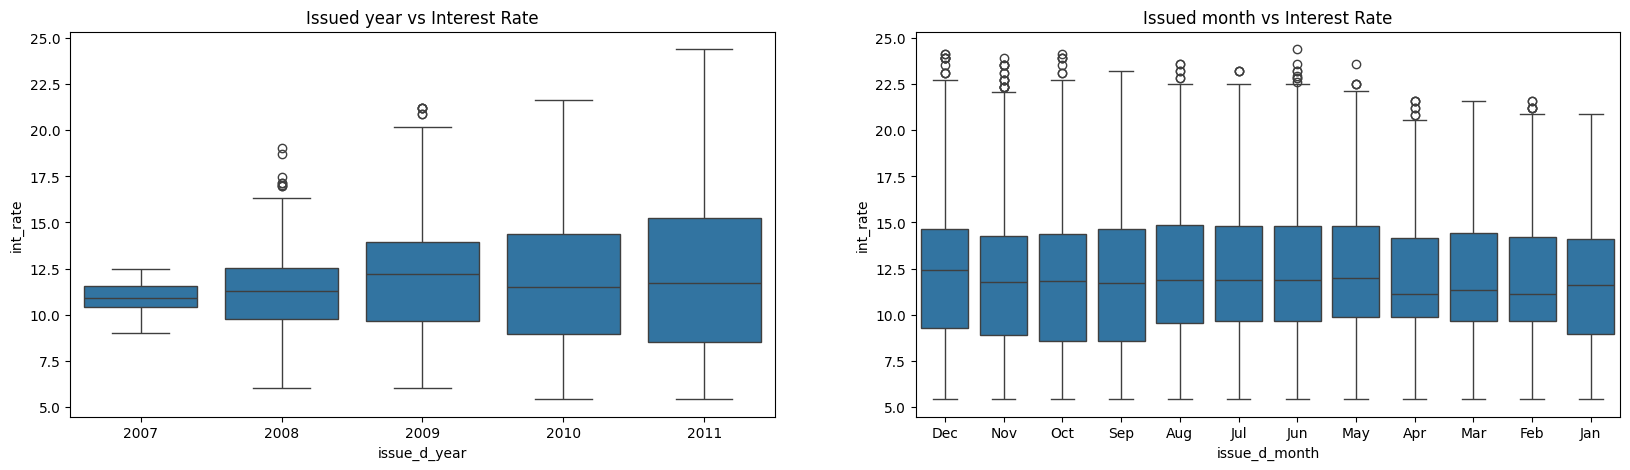

In [ ]:
#Issue_d
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x=loan_data.issue_d_year, y=loan_data.int_rate, data=loan_data)
plt.title('Issued year vs Interest Rate')
plt.subplot(122)
sns.boxplot(x=loan_data.issue_d_month, y=loan_data.int_rate, data=loan_data)
plt.title('Issued month vs Interest Rate')
plt.show()

Observations:
As the years of business increase the interest rates are getting more diversed but median of of interest rate is quite same in all the years.

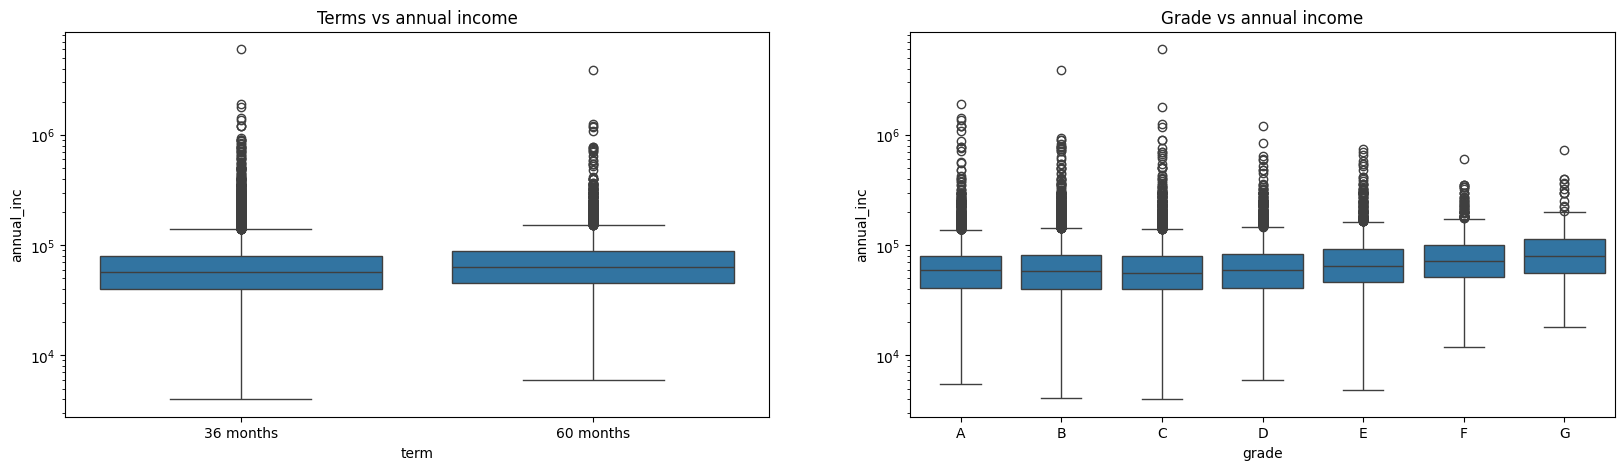

In [ ]:
#annual_inc
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='term', y=loan_data.annual_inc, data=loan_data)
plt.title('Terms vs annual income')
plt.yscale('log')
plt.subplot(122)
plt.title('Grade vs annual income')
grade_ord = loan_data.grade.unique()
grade_ord.sort()
sns.boxplot(x='grade', y=loan_data.annual_inc, order = grade_ord, data=loan_data)
plt.yscale('log')

Observations:
Comparatively Annual income is higher for lower grades.

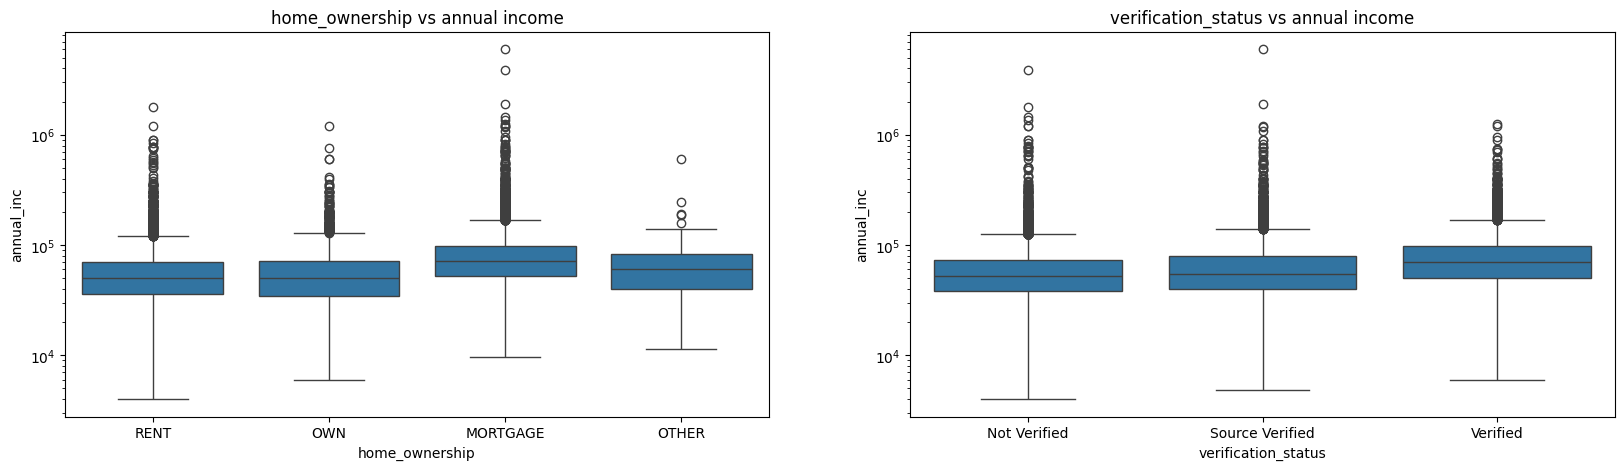

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='home_ownership', y=loan_data.annual_inc, data=loan_data)
plt.title('home_ownership vs annual income')
plt.yscale('log')
plt.subplot(122)
plt.title('verification_status vs annual income')
verification_status_ord = loan_data.verification_status.unique()
verification_status_ord.sort()
sns.boxplot(x='verification_status', y=loan_data.annual_inc, order = verification_status_ord, data=loan_data)
plt.yscale('log')

Observations:
The home ownership status for MORTAGE has higher income.
The income source was verfied for most of the borrower's who had higher annual incomes.

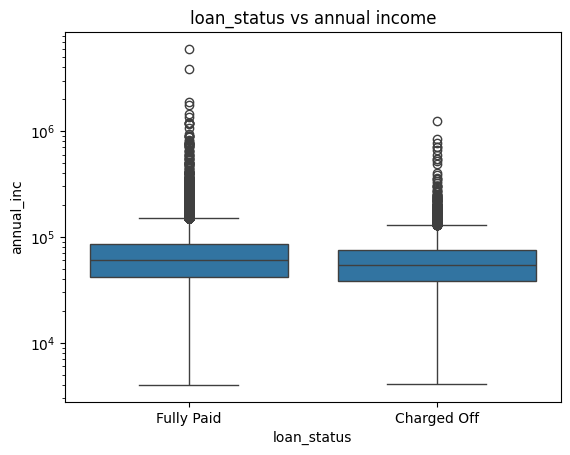

In [ ]:
sns.boxplot(x='loan_status', y=loan_data.annual_inc, data=loan_data)
plt.title('loan_status vs annual income')
plt.yscale('log')

Observations:
Current status of the loan is Fully paid for most of the borrower's who had higher annual incomes.

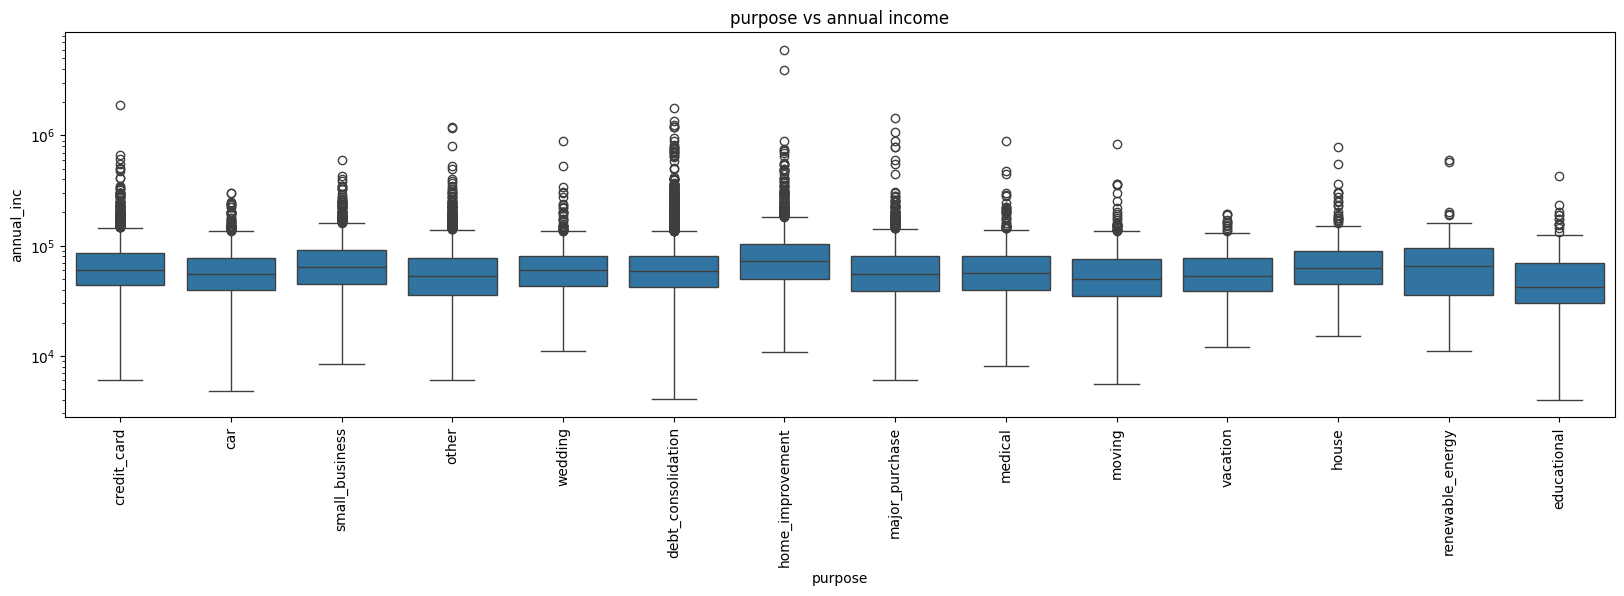

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='purpose', y=loan_data.annual_inc, data=loan_data)
plt.xticks(rotation=90)
plt.title('purpose vs annual income')
plt.yscale('log')

Observations:
A category belonging to Renewable energy, small business and home improvements have higher annual income provided by the borrower for the loan request

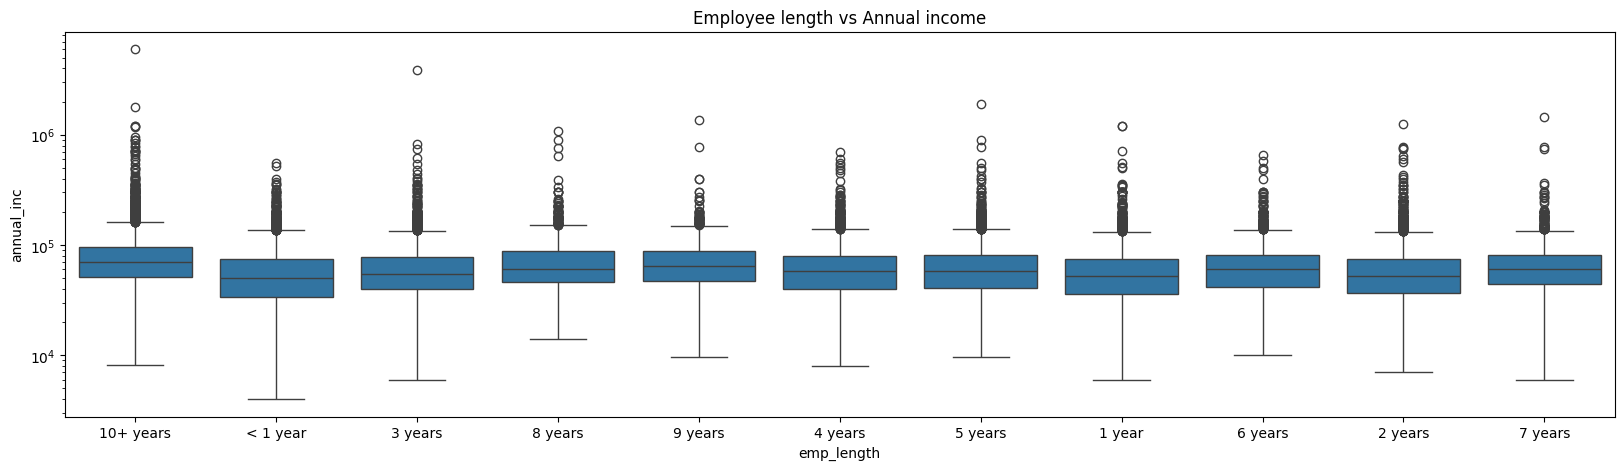

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='emp_length', y=loan_data.annual_inc, data=loan_data)
plt.title('Employee length vs Annual income')
plt.yscale('log')

Observations:
The borrower's who has higer income have taken loans for 10+ years of duration.

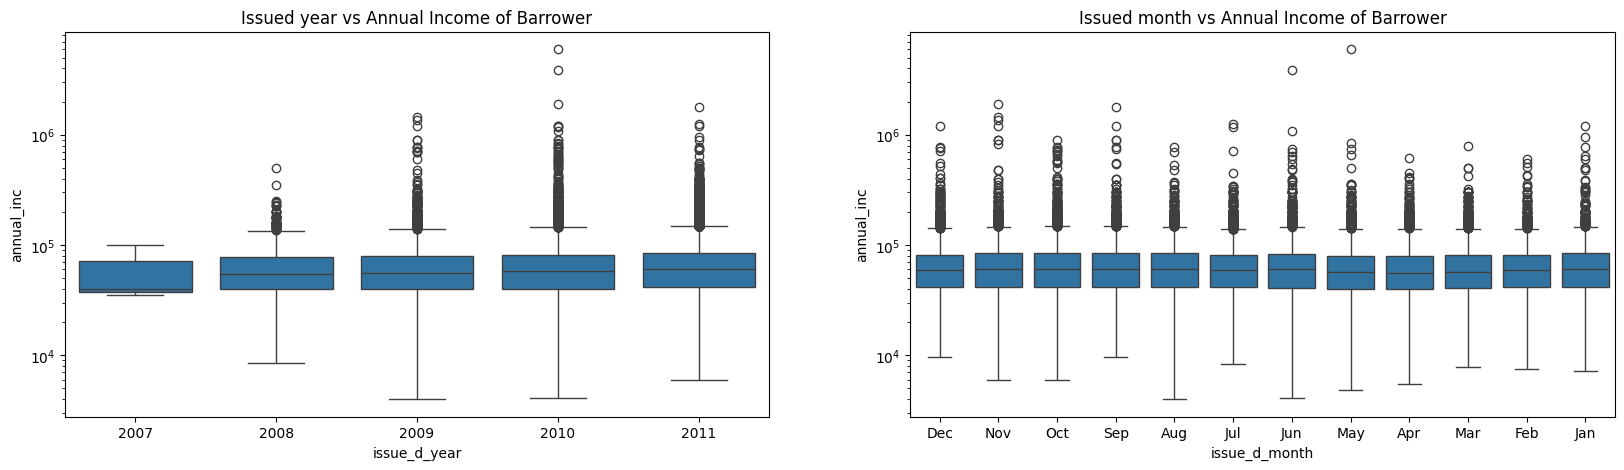

In [ ]:
#Issue_d
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x=loan_data.issue_d_year, y=loan_data.annual_inc, data=loan_data)
plt.title('Issued year vs Annual Income of Barrower')
plt.yscale('log')
plt.subplot(122)
sns.boxplot(x=loan_data.issue_d_month, y=loan_data.annual_inc, data=loan_data)
plt.title('Issued month vs Annual Income of Barrower')
plt.yscale('log')
plt.show()

Observations:
Annual income has no impact with the month when the loan was funded

<Axes: title={'center': 'Grade vs dti'}, xlabel='grade', ylabel='dti'>

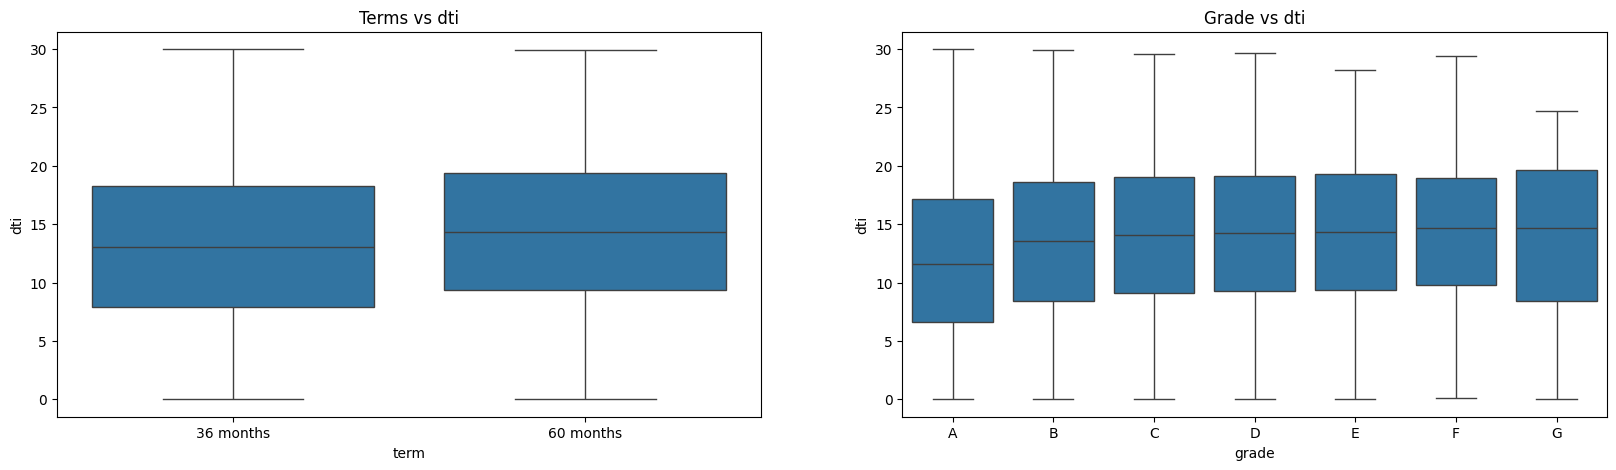

In [ ]:
#DTI(Debt to Income Ratio)
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='term', y=loan_data.dti, data=loan_data)
plt.title('Terms vs dti')
plt.subplot(122)
plt.title('Grade vs dti')
grade_ord = loan_data.grade.unique()
grade_ord.sort()
sns.boxplot(x='grade', y=loan_data.dti, order = grade_ord, data=loan_data)


Observation:
DTI is bit high for people who got more tenure i.e., 60 months.
A Grade barrowers are having low DTI than Other grades. DTI should be low for having high repayment percentage.

<Axes: title={'center': 'verification_status vs dti'}, xlabel='verification_status', ylabel='dti'>

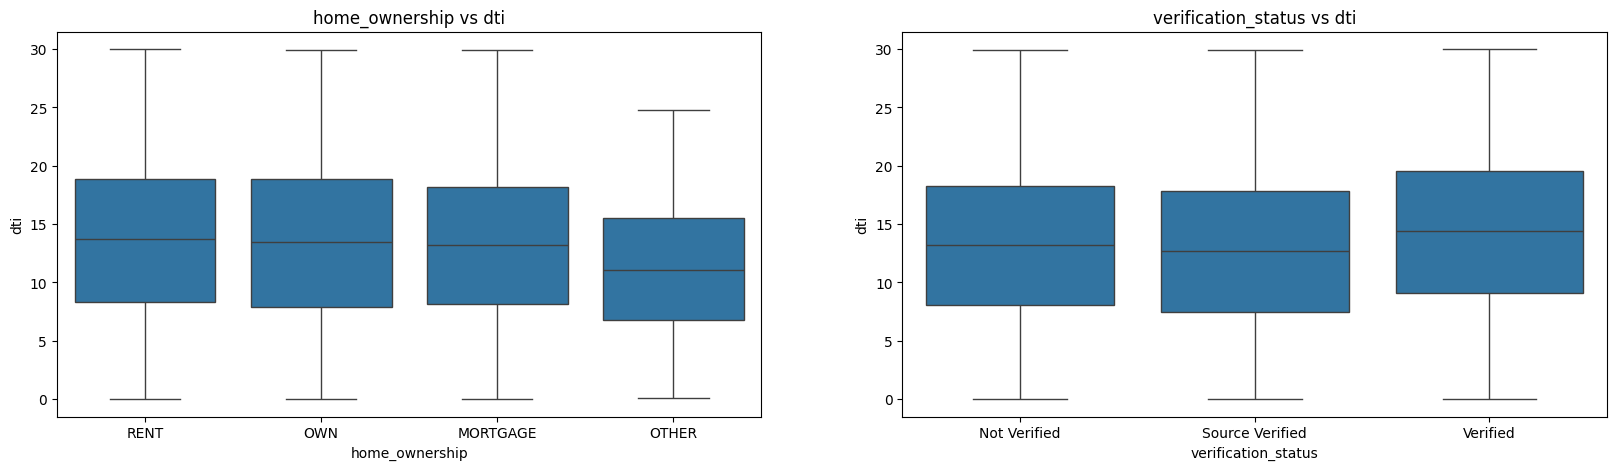

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='home_ownership', y=loan_data.dti, data=loan_data)
plt.title('home_ownership vs dti')
plt.subplot(122)
plt.title('verification_status vs dti')
verification_status_ord = loan_data.verification_status.unique()
verification_status_ord.sort()
sns.boxplot(x='verification_status', y=loan_data.dti, order = verification_status_ord, data=loan_data)

Observations:
People in Other home ownership has less DTI than others. This is may be bacause other people have mortgage and home loans.

Text(0.5, 1.0, 'loan_status vs dti')

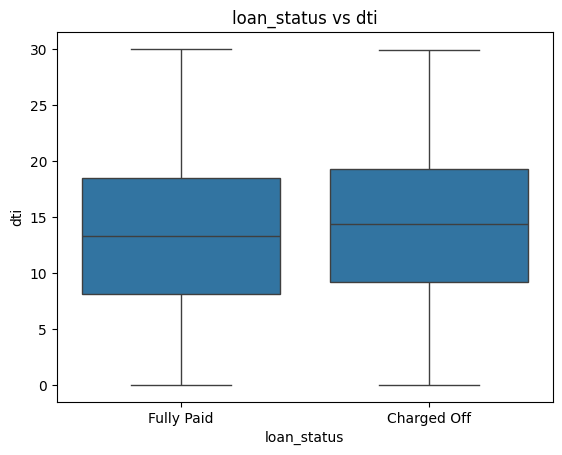

In [ ]:
sns.boxplot(x='loan_status', y=loan_data.dti, data=loan_data)
plt.title('loan_status vs dti')

Observations
Borrowers with high DTI has bit more probability to default

Text(0.5, 1.0, 'purpose vs dti')

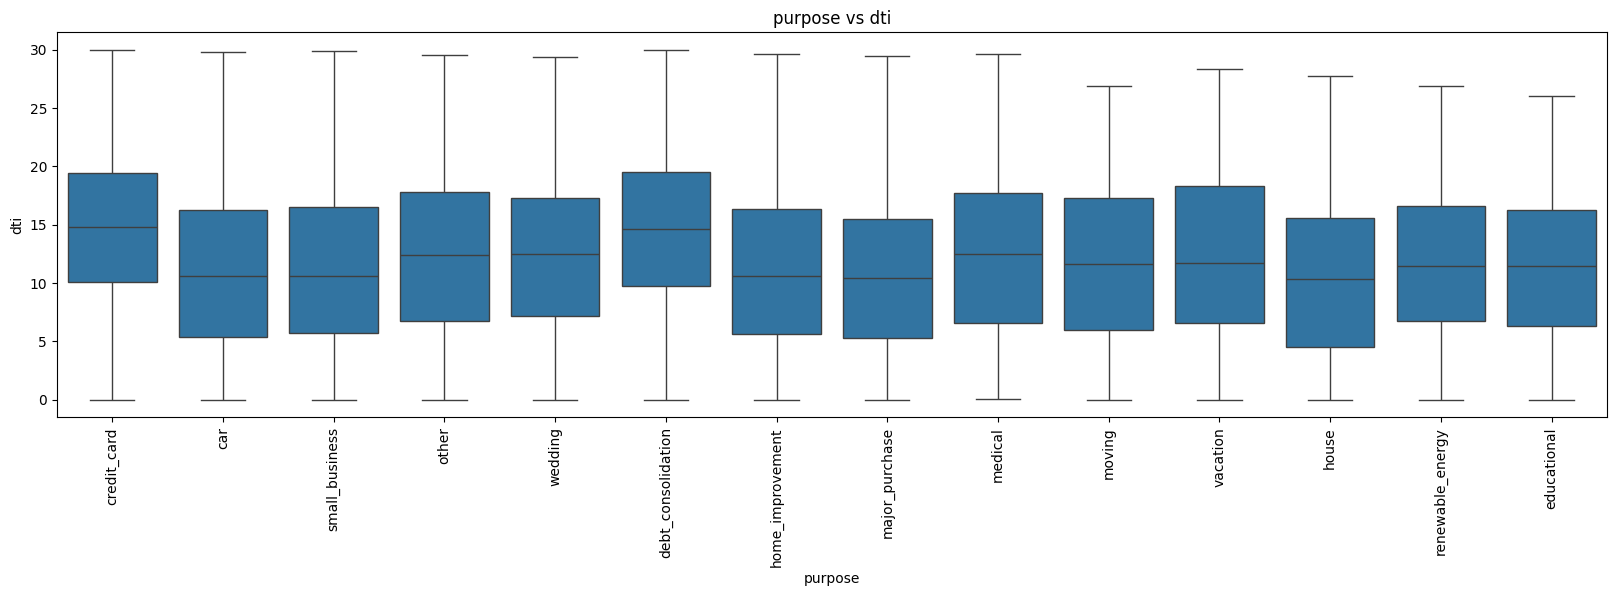

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='purpose', y=loan_data.dti, data=loan_data)
plt.xticks(rotation=90)
plt.title('purpose vs dti')

Observations:
People who took loan for credit card and debt consolidation purpose has more DTI than other purposes.

Text(0.5, 1.0, 'emp_length vs dti')

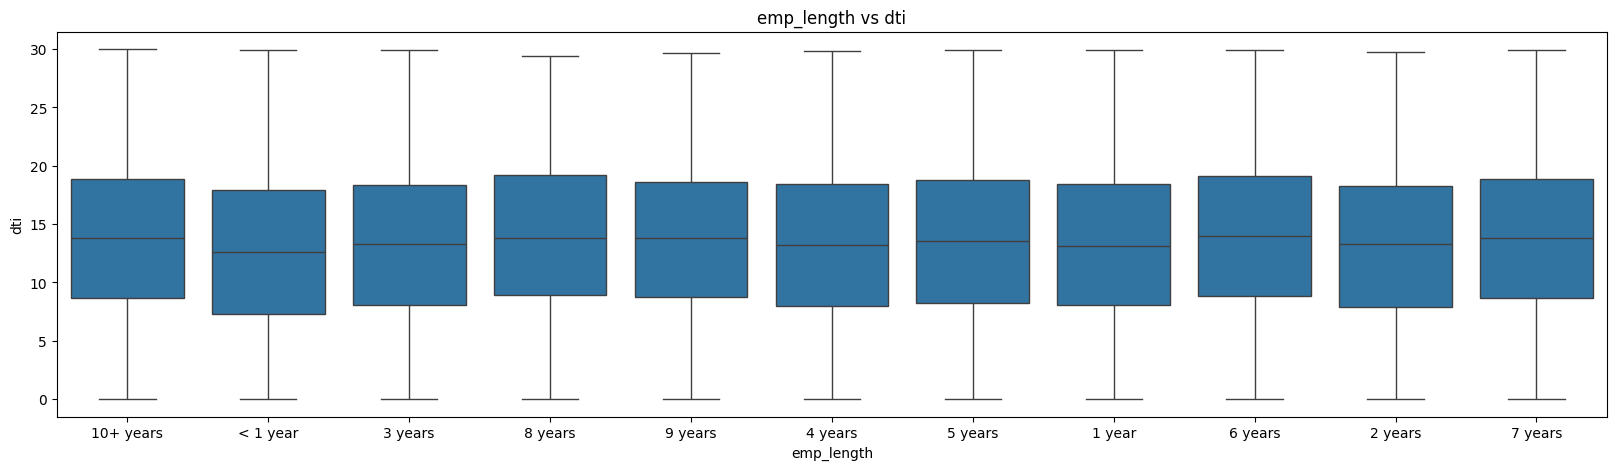

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='emp_length', y=loan_data.dti, data=loan_data)
plt.title('emp_length vs dti')

Observations:
The dti is pretti much similar for barrowers with all the employment length.

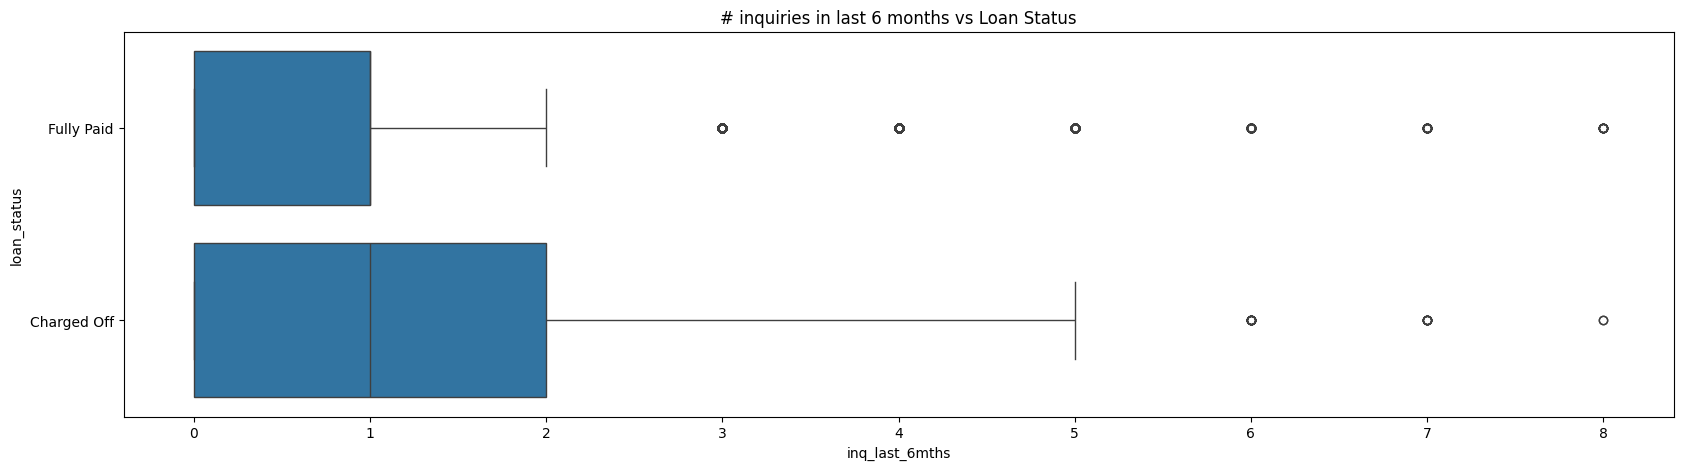

In [ ]:
#inq_last_6mths
plt.figure(figsize=(20,5))
sns.boxplot(x=loan_data.inq_last_6mths, y='loan_status', data=loan_data)
plt.title('# inquiries in last 6 months vs Loan Status')
plt.show()

Text(0.5, 1.0, 'emp_length vs Approval Loan Amount Ratio')

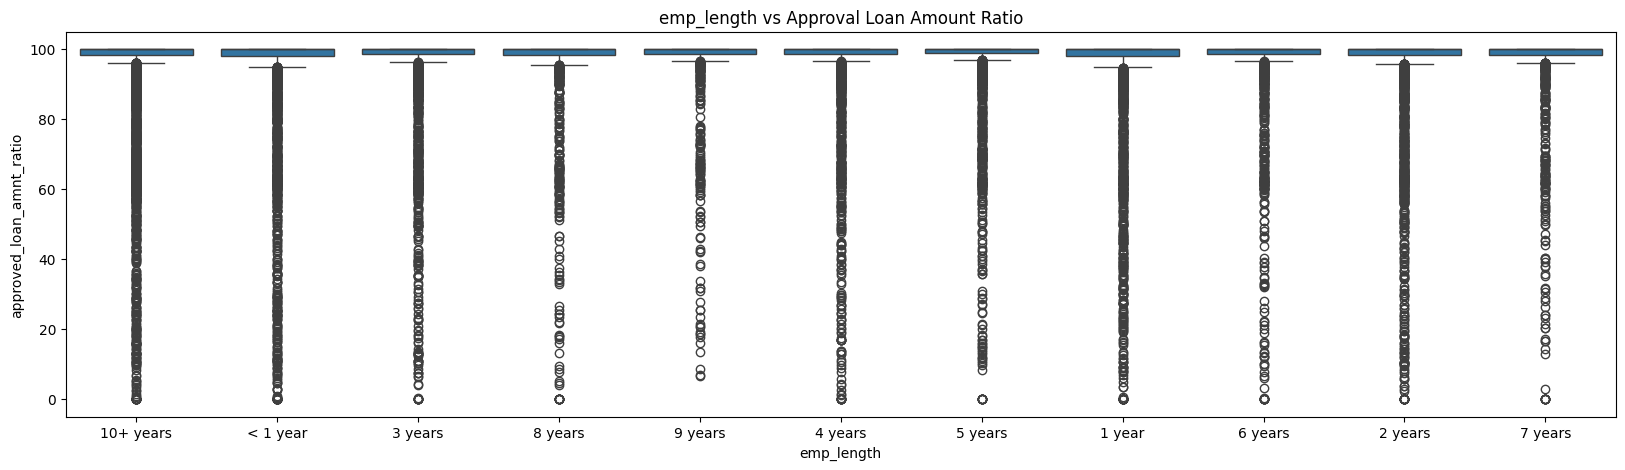

In [ ]:
#Approval Loan Amount Ratio
plt.figure(figsize=(20,5))
sns.boxplot(x='emp_length', y=loan_data.approved_loan_amnt_ratio, data=loan_data)
plt.title('emp_length vs Approval Loan Amount Ratio')

Observations:
There is not much relation between approval of loan amount ratio and employment length

Text(0.5, 1.0, 'Purpose vs Approval Loan Amount Ratio')

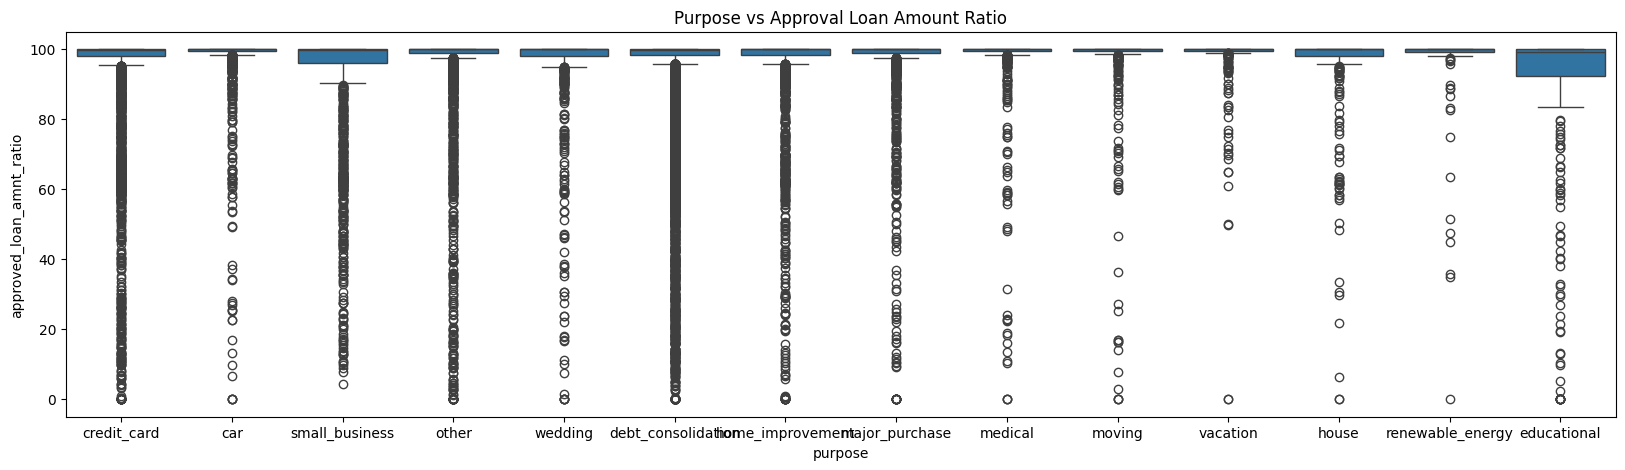

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='purpose', y=loan_data.approved_loan_amnt_ratio, data=loan_data)
plt.title('Purpose vs Approval Loan Amount Ratio')

Observations:
The Funded amount by investors is lower than requested loan amount in education and small business purposes.

Text(0.5, 1.0, 'Home Ownership vs Approval Loan Amount Ratio')

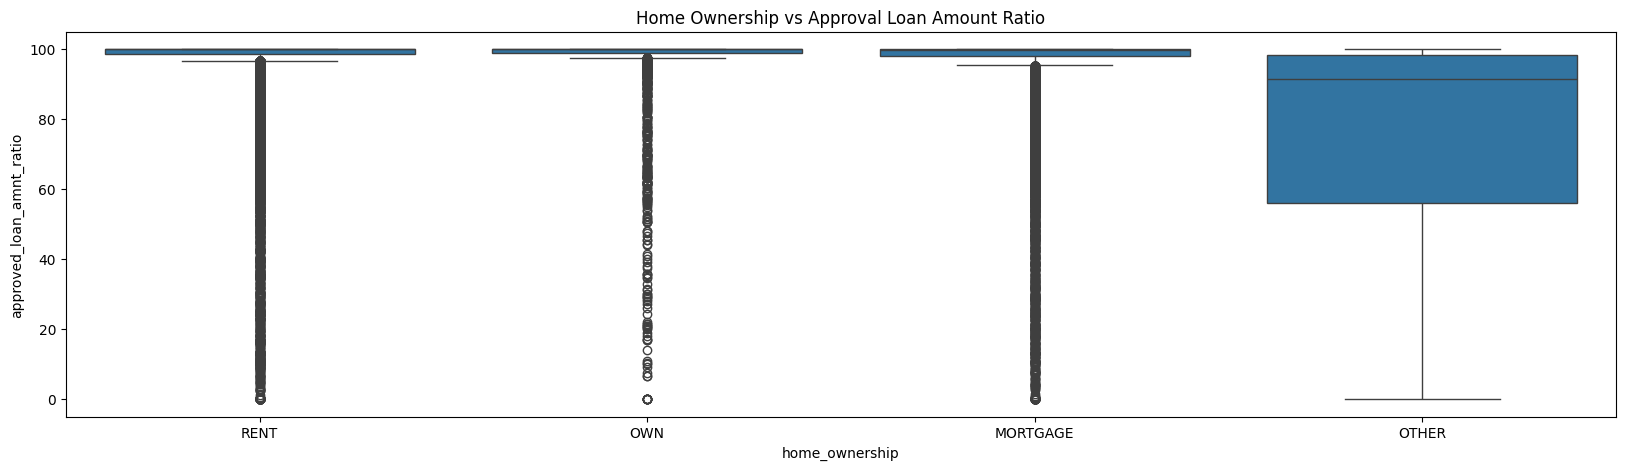

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x='home_ownership', y=loan_data.approved_loan_amnt_ratio, data=loan_data)
plt.title('Home Ownership vs Approval Loan Amount Ratio')

Observations:
Borrowers with Other home ownership are having less approved ratio which mean they got less amount than request amount.

Bivariate Analysis

In [ ]:
#Grade
#Sorting Grades from A to G
grade_ord = loan_data.grade.unique()
grade_ord.sort()

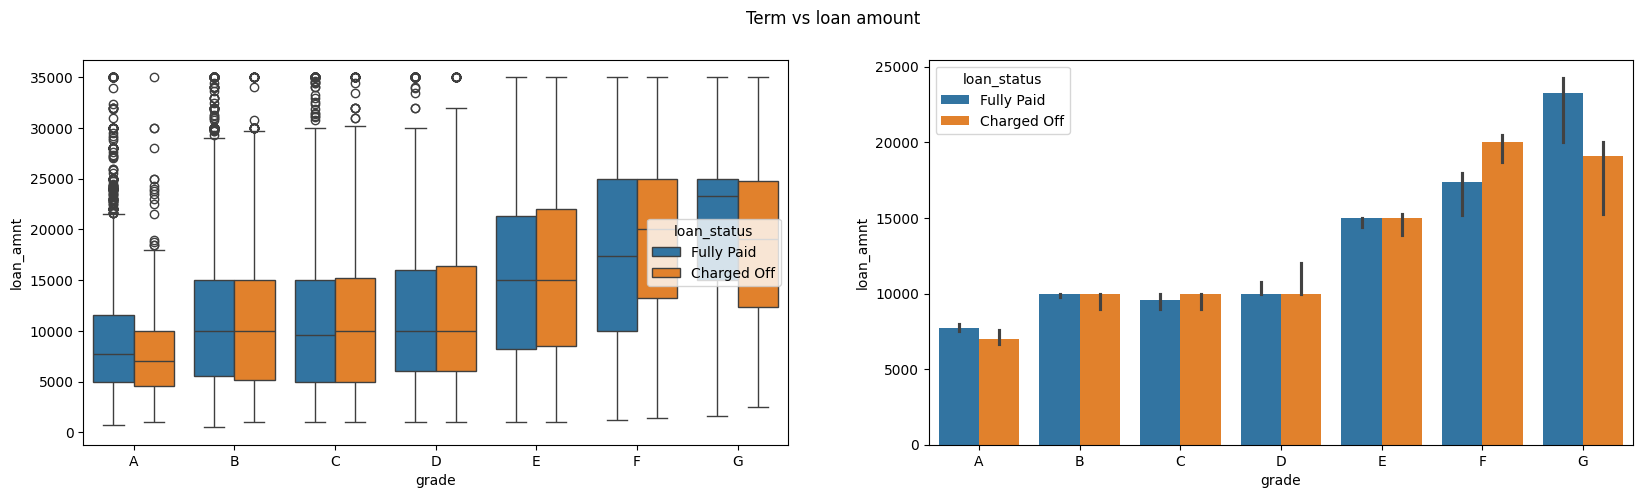

In [ ]:
import numpy as np
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='grade', y='loan_amnt', hue='loan_status', data=loan_data, order = grade_ord)
plt.subplot(122)
sns.barplot(x='grade', y='loan_amnt', hue='loan_status', data=loan_data, estimator=np.median, order = grade_ord)
plt.suptitle('Term vs loan amount')
plt.show()

Observations:

    For lower grades 'F' and 'G' there are more difference between charged-off and fully paid.
    The lower grade people has taken higher amount of loans and also they are more prone to default the loan.



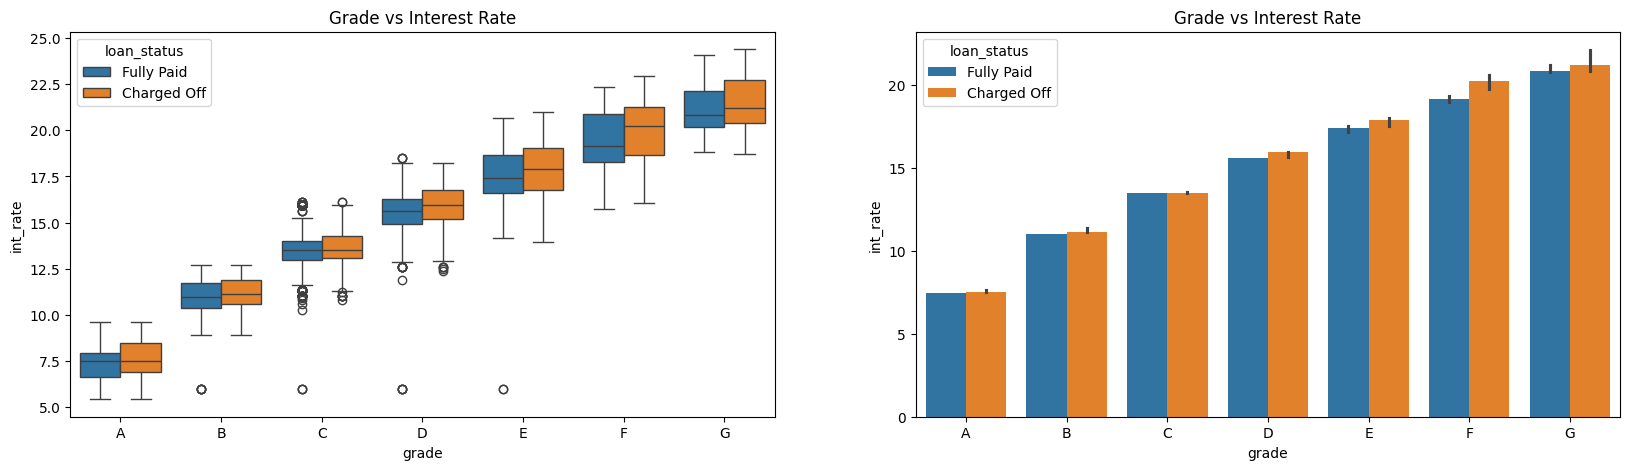

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='grade', y='int_rate', hue='loan_status', data=loan_data, order = grade_ord)
plt.title('Grade vs Interest Rate')
plt.subplot(122)
sns.barplot(x='grade', y='int_rate', hue='loan_status', data=loan_data, order = grade_ord, estimator=np.median)
plt.title('Grade vs Interest Rate')
plt.show()

Observations:
As grade decreases the interest rate gradually increases. and they are more and more prone to default the loan.

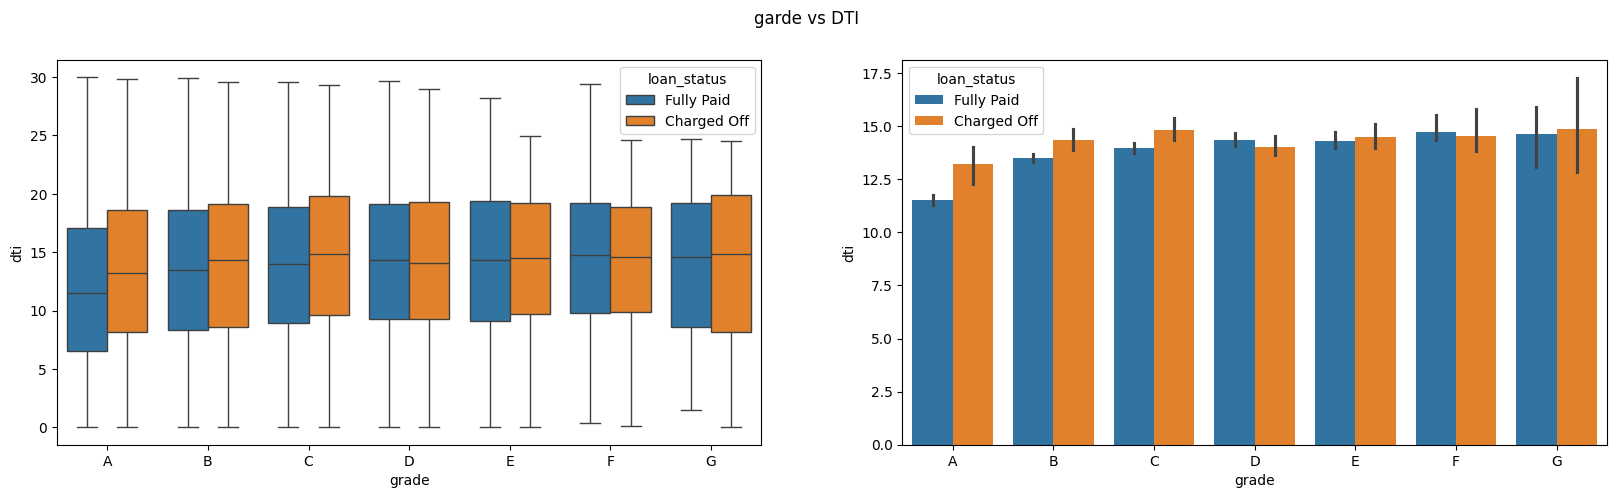

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='grade', y='dti', hue='loan_status', data=loan_data, order=grade_ord)
plt.subplot(122)
sns.barplot(x='grade', y='dti', hue='loan_status', data=loan_data, estimator=np.median, order = grade_ord)
plt.suptitle('garde vs DTI')
plt.show()

Observations:
There is not much change in dti in each grade and loan status.

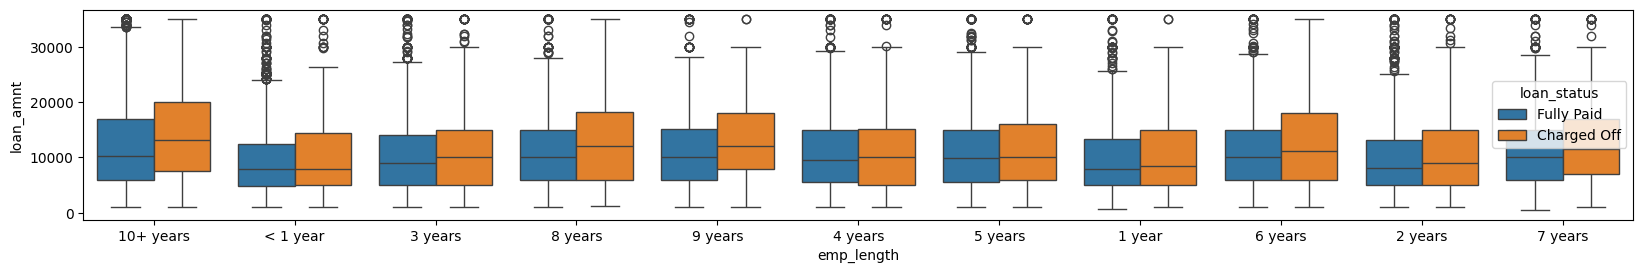

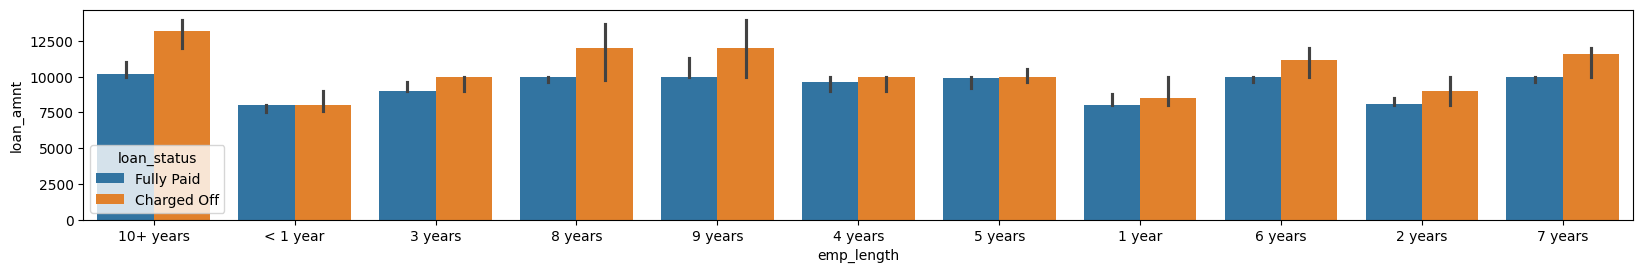

In [ ]:
#Employment Length
plt.figure(figsize=(20,6))
plt.subplot(211)
sns.boxplot(x='emp_length', y='loan_amnt', hue='loan_status', data=loan_data)
plt.figure(figsize=(20,6))
plt.subplot(212)
sns.barplot(x='emp_length', y='loan_amnt', hue='loan_status', data=loan_data, estimator=np.median)
plt.show()

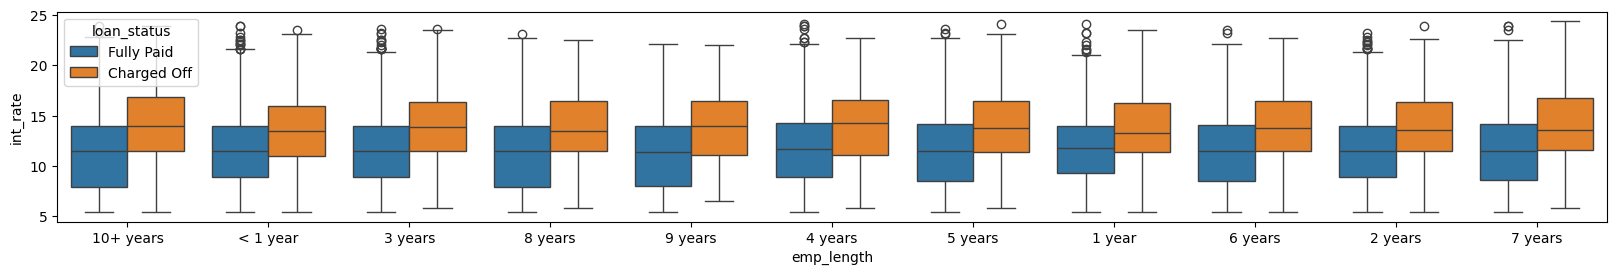

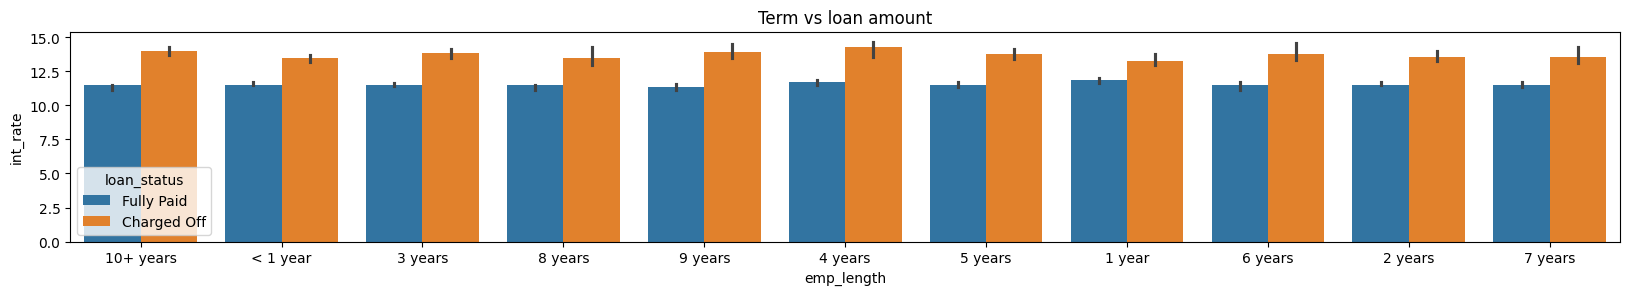

In [ ]:
plt.figure(figsize=(20,6))
plt.subplot(211)
sns.boxplot(x='emp_length', y='int_rate', hue='loan_status', data=loan_data)
plt.figure(figsize=(20,6))
plt.subplot(212)
sns.barplot(x='emp_length', y='int_rate', hue='loan_status', data=loan_data, estimator=np.median)
plt.title('Term vs loan amount')
plt.show()

Observations:
Irrespictive of employment length loans with more interest rates got defaulted more.

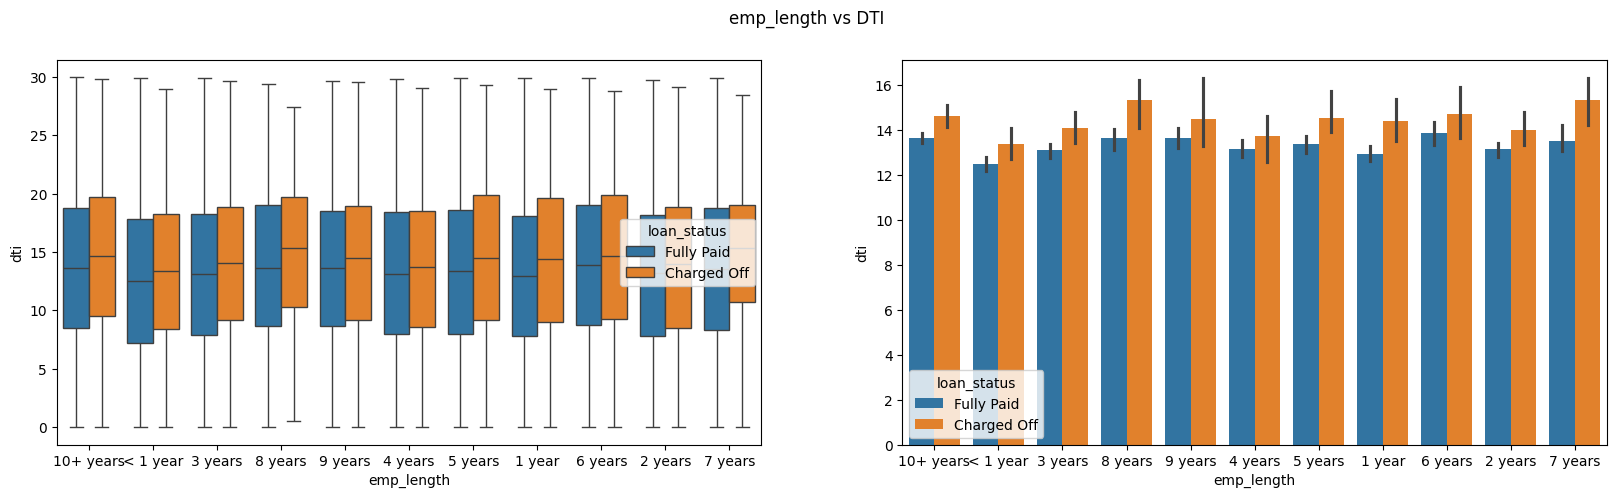

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='emp_length', y='dti', hue='loan_status', data=loan_data)
plt.subplot(122)
sns.barplot(x='emp_length', y='dti', hue='loan_status', data=loan_data, estimator=np.median)
plt.suptitle('emp_length vs DTI')
plt.show()

Observations:
Employment Length and DTI are not showing any patterns towards defaults.

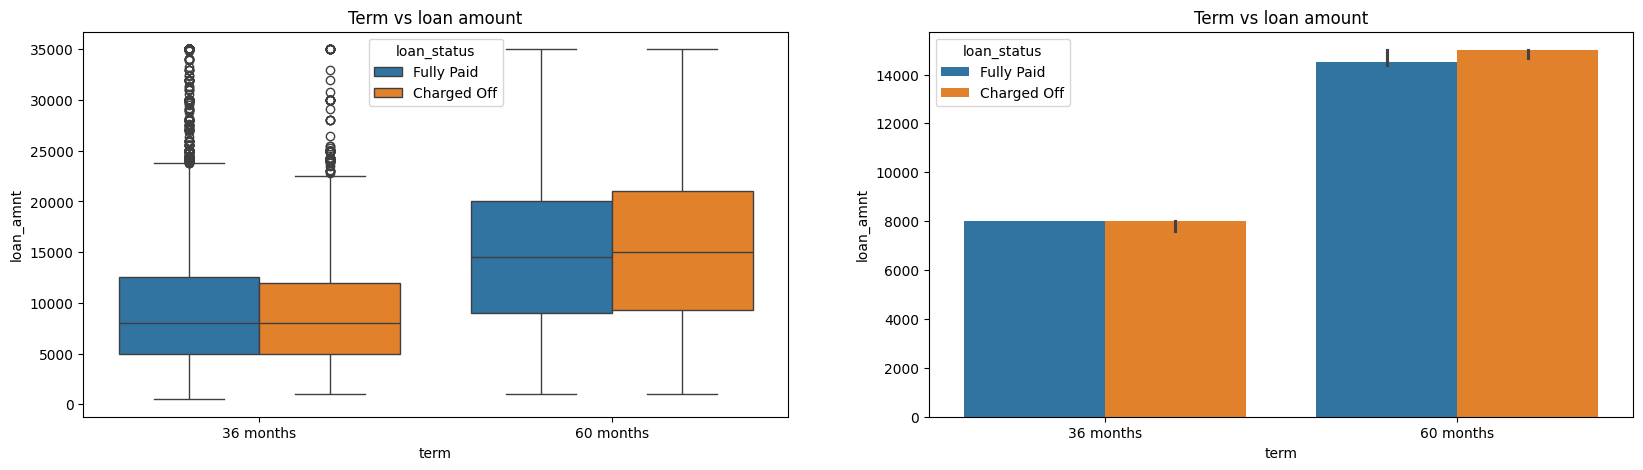

In [ ]:
#Term vs Loan Status
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='term', y='loan_amnt', hue='loan_status', data=loan_data)
plt.title('Term vs loan amount')
plt.subplot(122)
sns.barplot(x='term', y='loan_amnt', hue='loan_status', data=loan_data, estimator=np.median)
plt.title('Term vs loan amount')
plt.show()

Observations:
Loan amount is not a decider for defaults in both 36 adn 60 months.
Borrowers have equal distribtion is both default and non default for 36 and 60 months tenures.

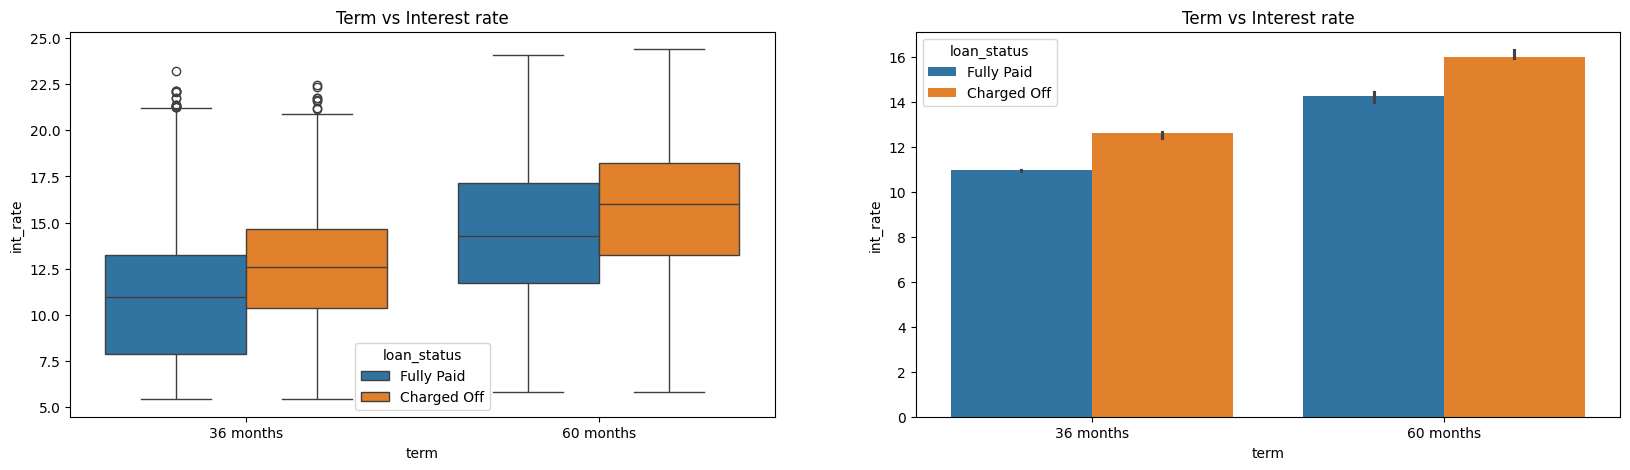

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='term', y='int_rate', hue='loan_status', data=loan_data)
plt.title('Term vs Interest rate')
plt.subplot(122)
sns.barplot(x='term', y='int_rate', hue='loan_status', data=loan_data, estimator=np.median)
plt.title('Term vs Interest rate')
plt.show()

Observations
For higher interest rates the deafult rate is higher in both 36 and 60 months tenure.


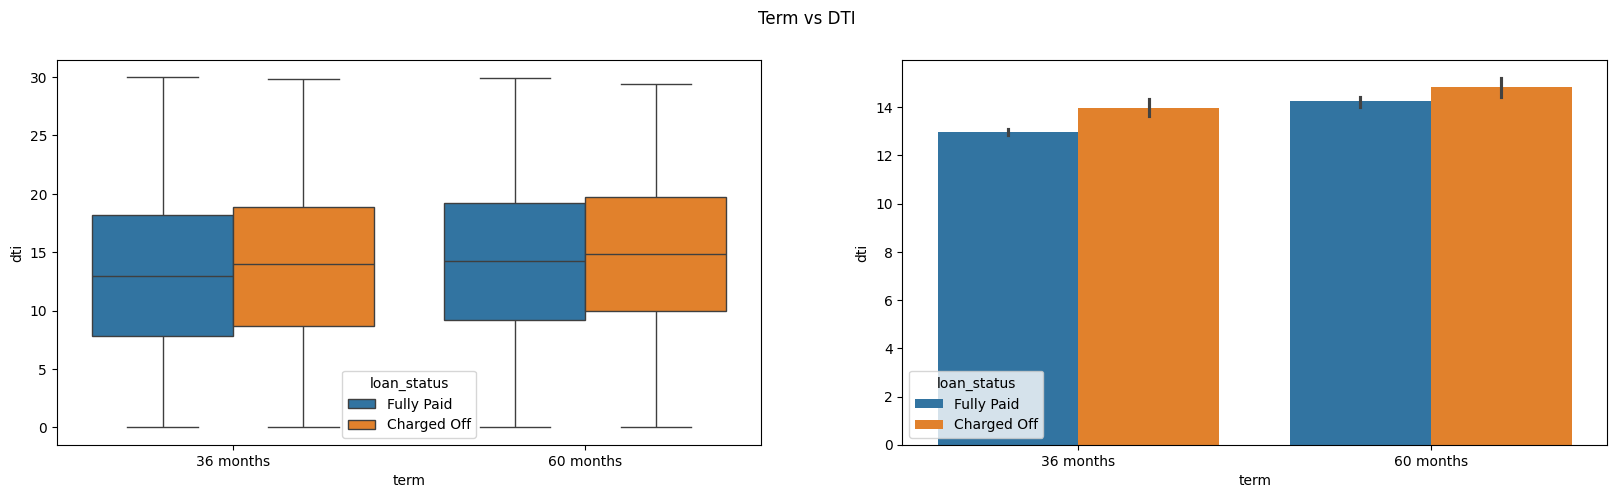

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='term', y='dti', hue='loan_status', data=loan_data)
plt.subplot(122)
sns.barplot(x='term', y='dti', hue='loan_status', data=loan_data, estimator=np.median)
plt.suptitle('Term vs DTI')
plt.show()

Observations:
Comparitively charge-off are higher when compared with fully-paid for the Debit to income ratio.

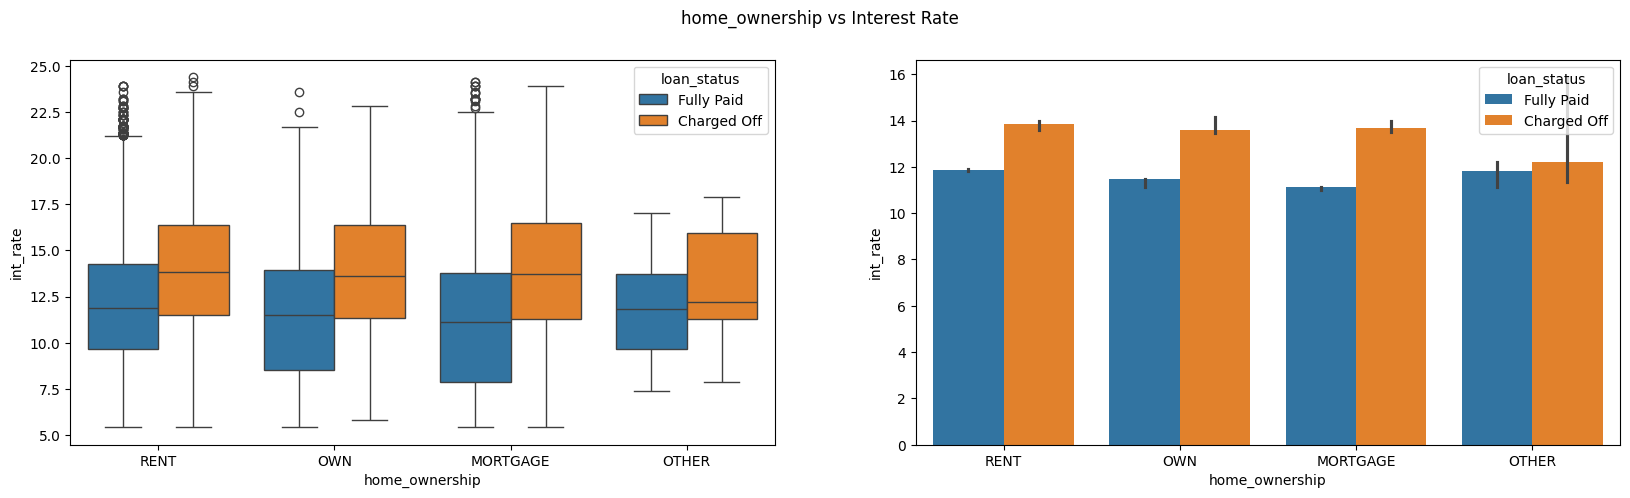

In [ ]:
#Home Ownership
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='home_ownership', y='int_rate', hue='loan_status', data=loan_data)
plt.subplot(122)
sns.barplot(x='home_ownership', y='int_rate', hue='loan_status', data=loan_data, estimator=np.median)
plt.suptitle('home_ownership vs Interest Rate')
plt.show()

Observations:
Irrespictive of Home owner ship, when the interest rate is high the dafault rate also high

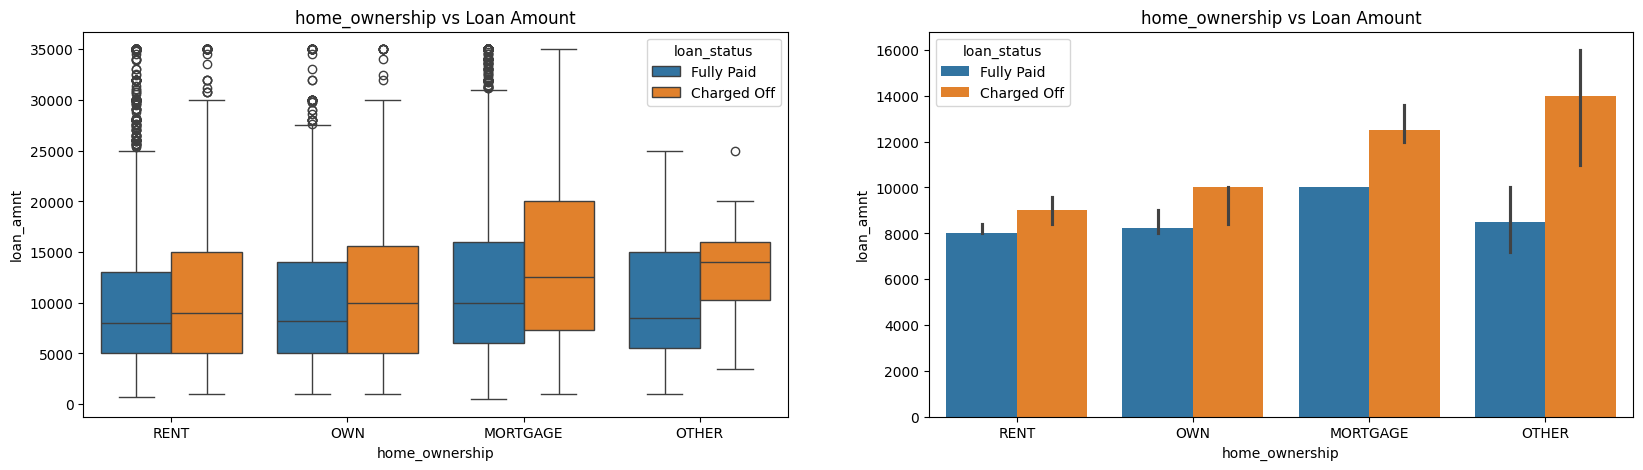

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='home_ownership', y='loan_amnt', hue='loan_status', data=loan_data)
plt.title('home_ownership vs Loan Amount')
plt.subplot(122)
sns.barplot(x='home_ownership', y='loan_amnt', hue='loan_status', data=loan_data, estimator=np.median)
plt.title('home_ownership vs Loan Amount')
plt.show()

Observations:
Borrowers who took higher loan amounts defaulted more than others.

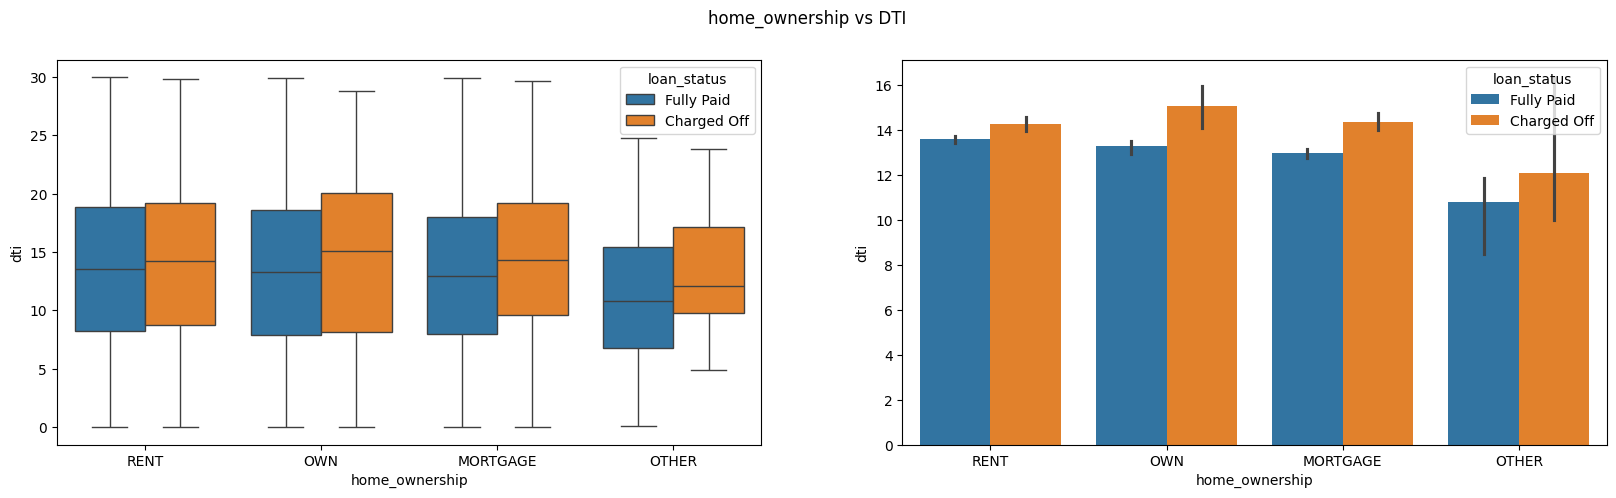

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='home_ownership', y='dti', hue='loan_status', data=loan_data)
plt.subplot(122)
sns.barplot(x='home_ownership', y='dti', hue='loan_status', data=loan_data, estimator=np.median)
plt.suptitle('home_ownership vs DTI')
plt.show()

Observations:

    Borrowers in other home ownership category has less dti than other categories.
    There is equal posibility of home owners defaulting for all the home ownerships.



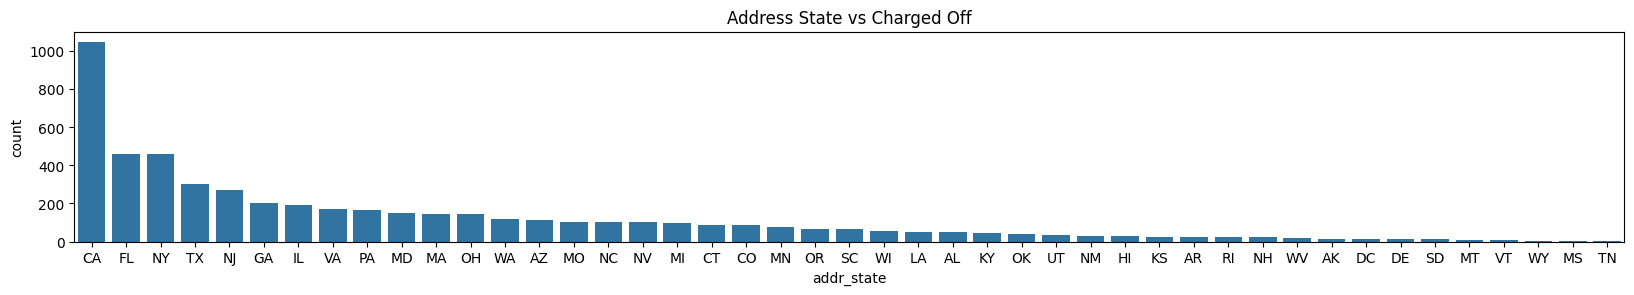

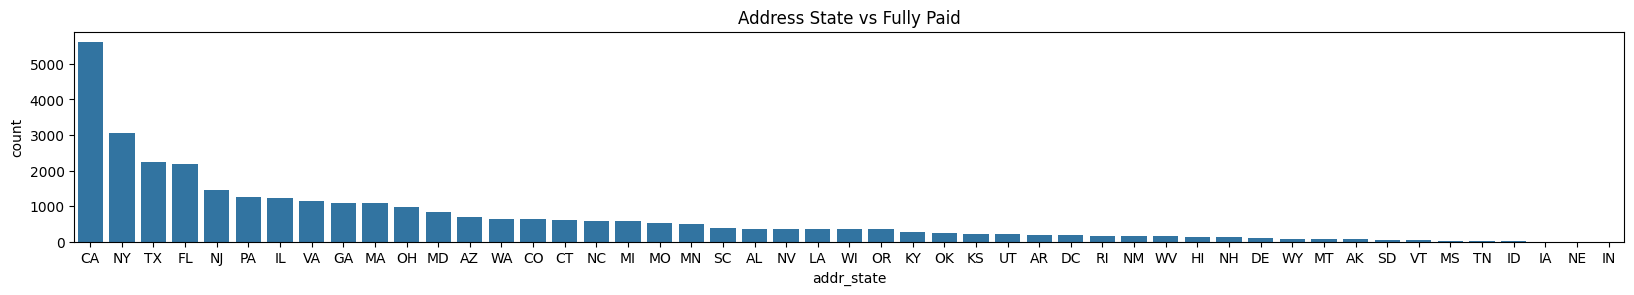

In [ ]:
#Address State
charged_off_df = loan_data[loan_data.loan_status.values == 'Charged Off']
plt.figure(figsize=(20,6))
plt.subplot(211)
sns.countplot(x='addr_state', data=charged_off_df, order=charged_off_df.addr_state.value_counts().index)
plt.title('Address State vs Charged Off')

fp_df = loan_data[loan_data.loan_status.values == 'Fully Paid']
plt.figure(figsize=(20,6))
plt.subplot(212)
sns.countplot(x='addr_state', data=fp_df, order=fp_df.addr_state.value_counts().index)
plt.title('Address State vs Fully Paid')
plt.show()

Observations:
More number of borrowers defaulted in CA , FL and NY states.

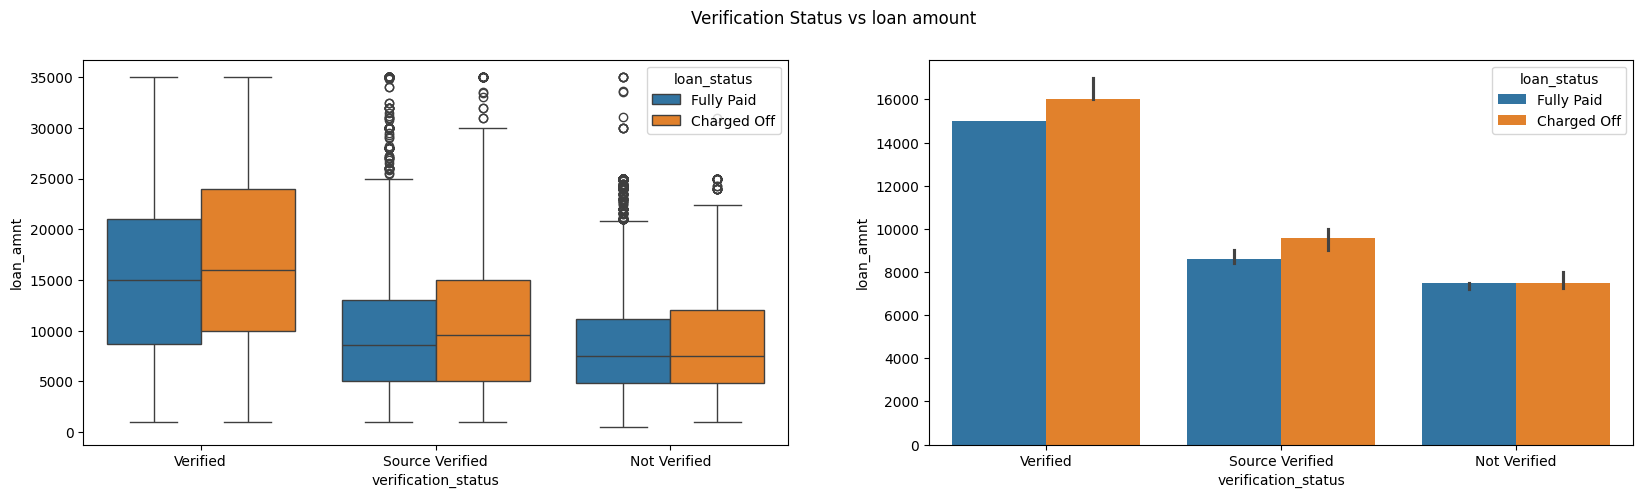

In [ ]:
#Verfication Status
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='verification_status', y='loan_amnt', hue='loan_status', data=loan_data)
plt.subplot(122)
sns.barplot(x='verification_status', y='loan_amnt', hue='loan_status', data=loan_data, estimator=np.median)
plt.suptitle('Verification Status vs loan amount')
plt.show()

Observations:

    Verified loans are given more loan amounts compared to others.
    There is a slight increase in loan amount for verified and source verified loan when they are defaulted.



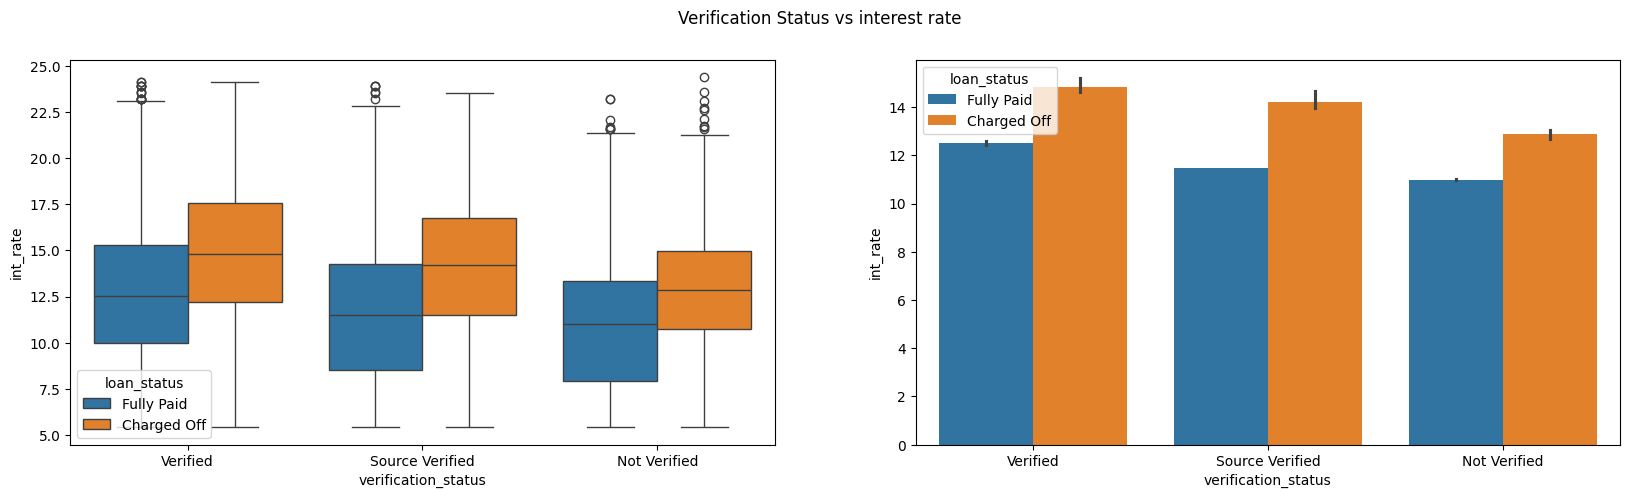

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='verification_status', y='int_rate', hue='loan_status', data=loan_data)
plt.subplot(122)
sns.barplot(x='verification_status', y='int_rate', hue='loan_status', data=loan_data, estimator=np.median)
plt.suptitle('Verification Status vs interest rate')
plt.show()

Observations:
Irrespective of verification status higher interest rates are incurring default of loan.


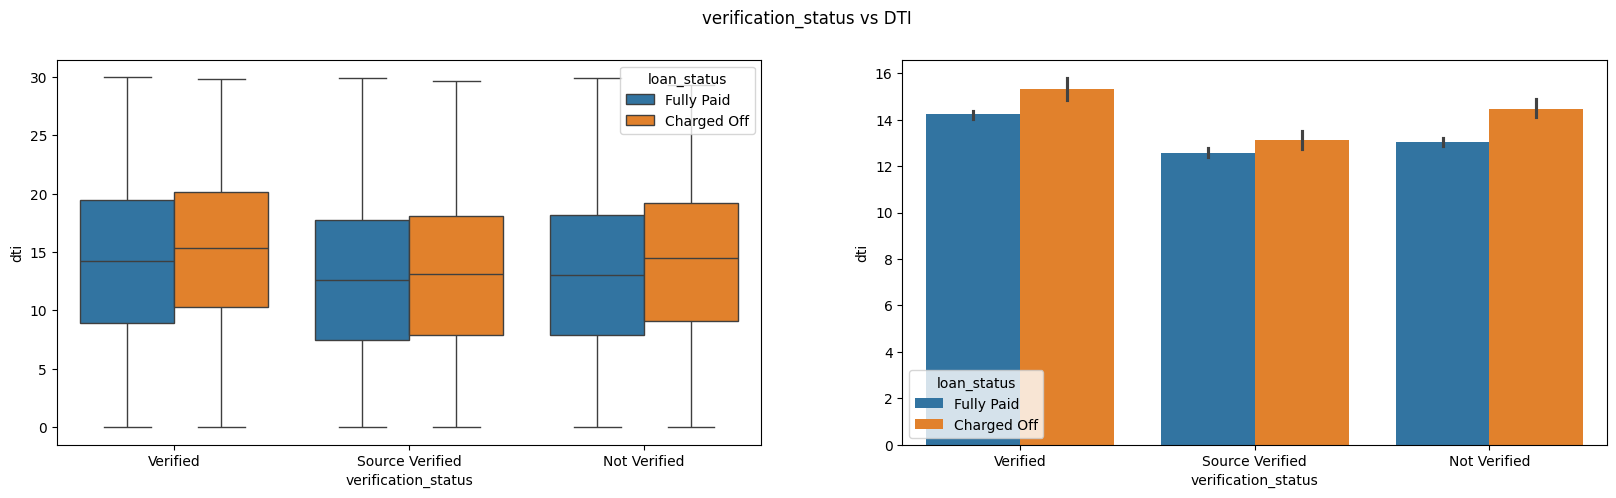

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.boxplot(x='verification_status', y='dti', hue='loan_status', data=loan_data)
plt.subplot(122)
sns.barplot(x='verification_status', y='dti', hue='loan_status', data=loan_data, estimator=np.median)
plt.suptitle('verification_status vs DTI')
plt.show()

Observations:
There is slight increase in the dti mean for defaulted laons for all the verification status categories.

<Figure size 640x480 with 0 Axes>

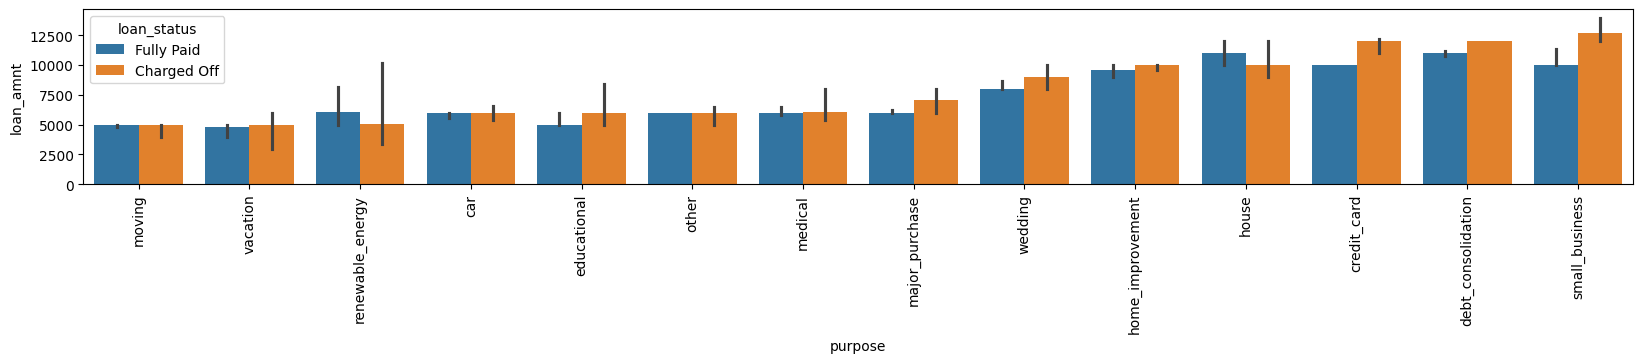

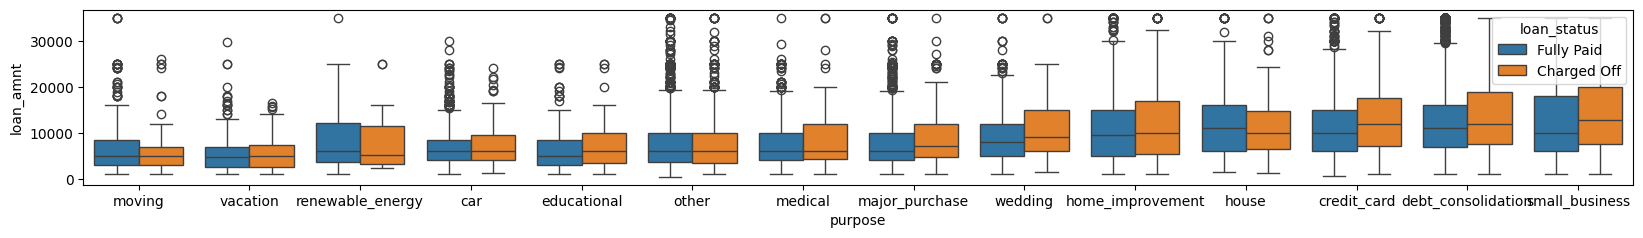

In [ ]:
#Purpose
df = loan_data.groupby(['purpose', 'loan_status'], as_index=False)['loan_amnt'].median()

plt.suptitle('Purpose vs loan amount')
plt.figure(figsize=(20,5))
plt.subplot(211)
sns.barplot(x='purpose', y='loan_amnt', hue='loan_status', data= loan_data, order=df[df.loan_status == 'Charged Off'].sort_values(by='loan_amnt').purpose, estimator=np.median)
plt.xticks(rotation=90)

plt.figure(figsize=(20,5))
plt.subplot(212)
sns.boxplot(x='purpose', y='loan_amnt', hue='loan_status', data= loan_data, order=df[df.loan_status == 'Charged Off'].sort_values(by='loan_amnt').purpose)
plt.show()

Observations:
Small Business has more defaults when the loan amount is also high.


<Figure size 640x480 with 0 Axes>

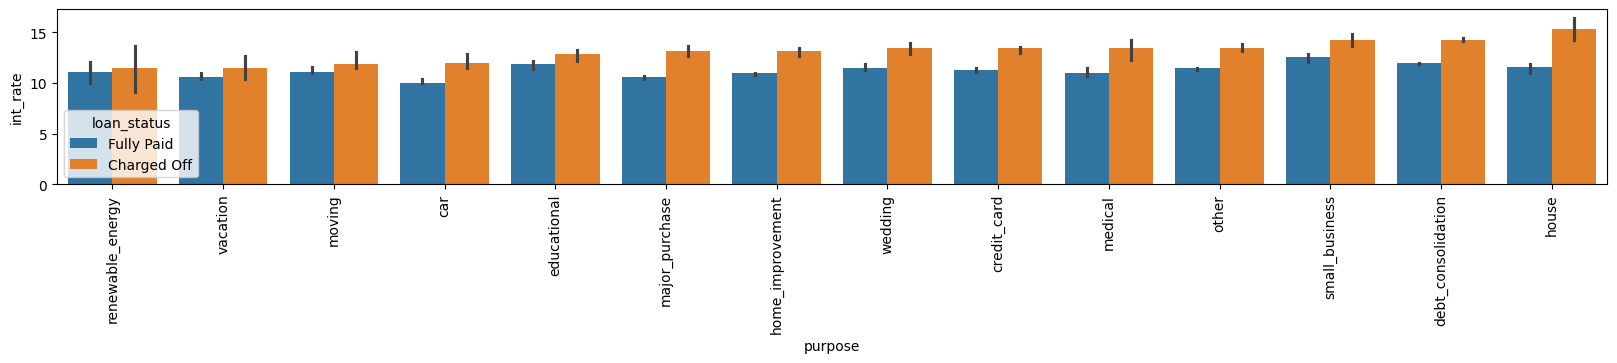

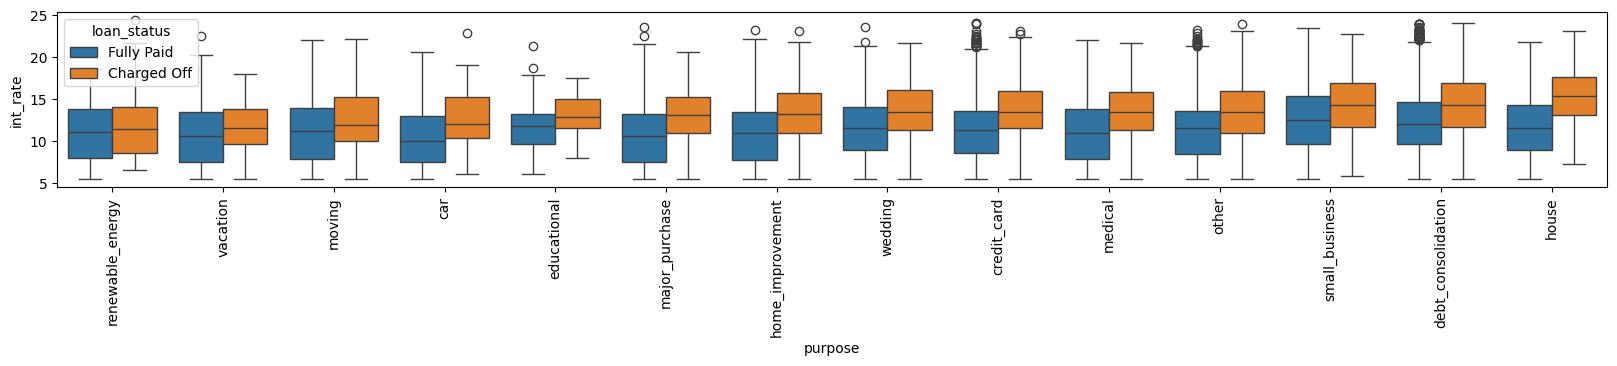

In [ ]:
df = loan_data.groupby(['purpose', 'loan_status'], as_index=False)['int_rate'].median()
purpose_ord = df[df.loan_status == 'Charged Off'].sort_values(by='int_rate').purpose

plt.suptitle('Purpose vs interest rate')
plt.figure(figsize=(20,5))
plt.subplot(211)
sns.barplot(x='purpose', y='int_rate', hue='loan_status', data= loan_data, estimator=np.median, order = purpose_ord)
plt.xticks(rotation=90)

plt.figure(figsize=(20,5))
plt.subplot(212)
sns.boxplot(x='purpose', y='int_rate', hue='loan_status', data= loan_data, order = purpose_ord)
plt.xticks(rotation=90)
plt.show()

Observations:
Home loans with high interest rates are mostly defaulted. Even small business and debt consolidation has similar observation.

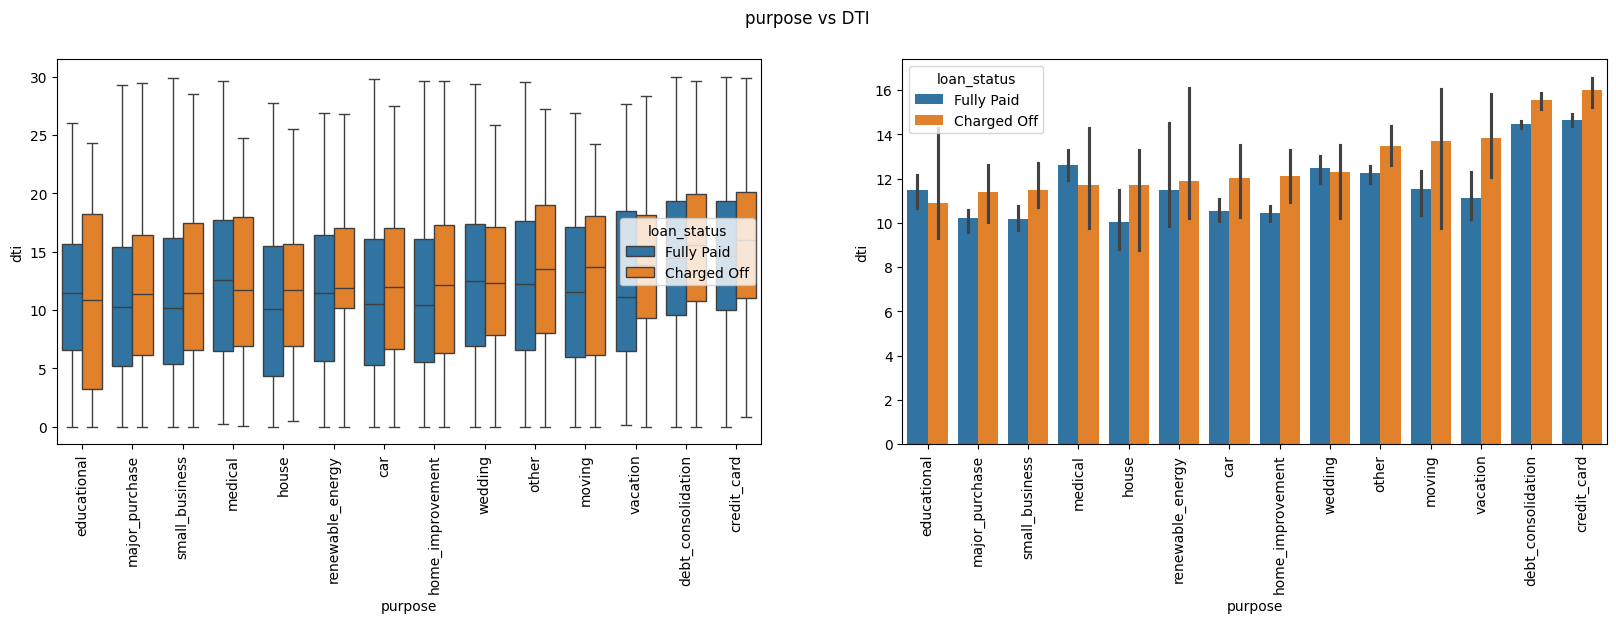

In [ ]:
df = loan_data.groupby(['purpose', 'loan_status'], as_index=False)['dti'].median()
purpose_ord = df[df.loan_status == 'Charged Off'].sort_values(by='dti').purpose

plt.figure(figsize=(20,5))
plt.suptitle('purpose vs DTI')
plt.subplot(121)
sns.boxplot(x='purpose', y='dti', hue='loan_status', data=loan_data, order=purpose_ord)
plt.xticks(rotation=90)
plt.subplot(122)
sns.barplot(x='purpose', y='dti', hue='loan_status', data=loan_data, estimator=np.median, order = purpose_ord)
plt.xticks(rotation=90)
plt.show()

Observations:
Could not observe any pattern from the charts

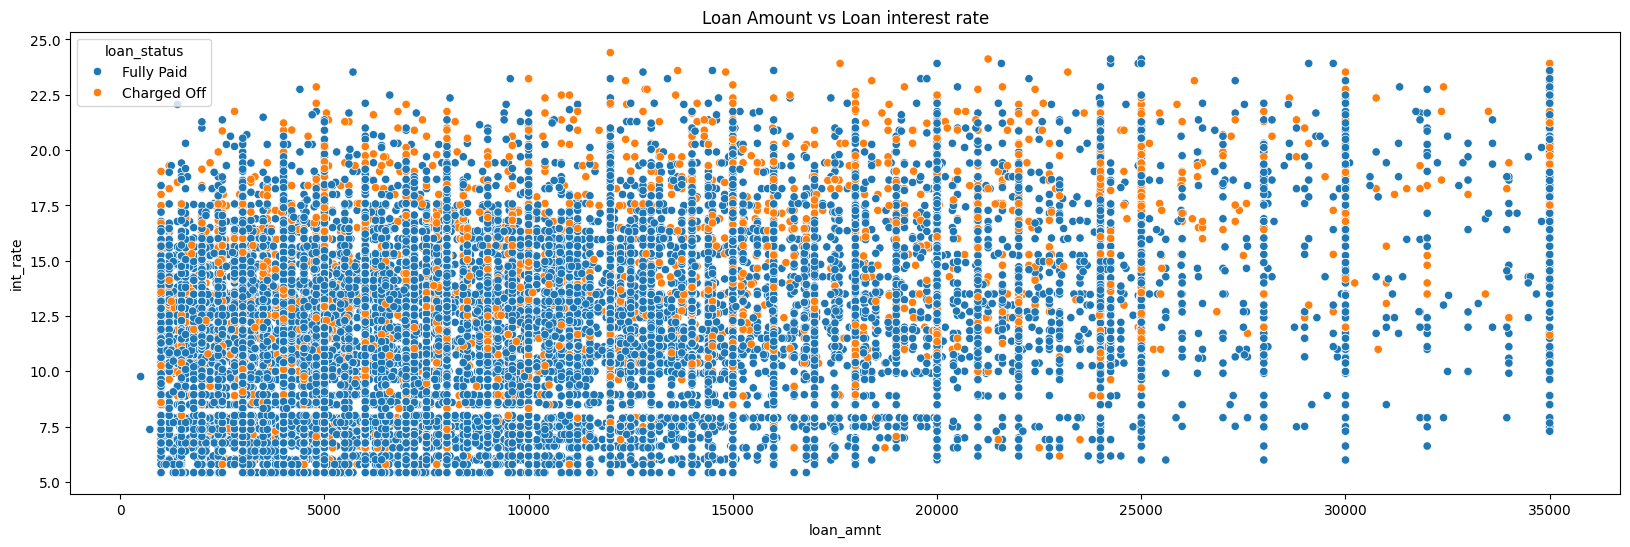

In [ ]:
#Loan Amount vs Interest Rate
plt.figure(figsize=(20,6))
#scatter plot for analysing distribution
sns.scatterplot(x='loan_amnt', y='int_rate', data=loan_data, hue='loan_status')
plt.title('Loan Amount vs Loan interest rate')
plt.show()

Observartions:
Values are pretty much spread accross all the space. There is not specific pattern found in the spread.

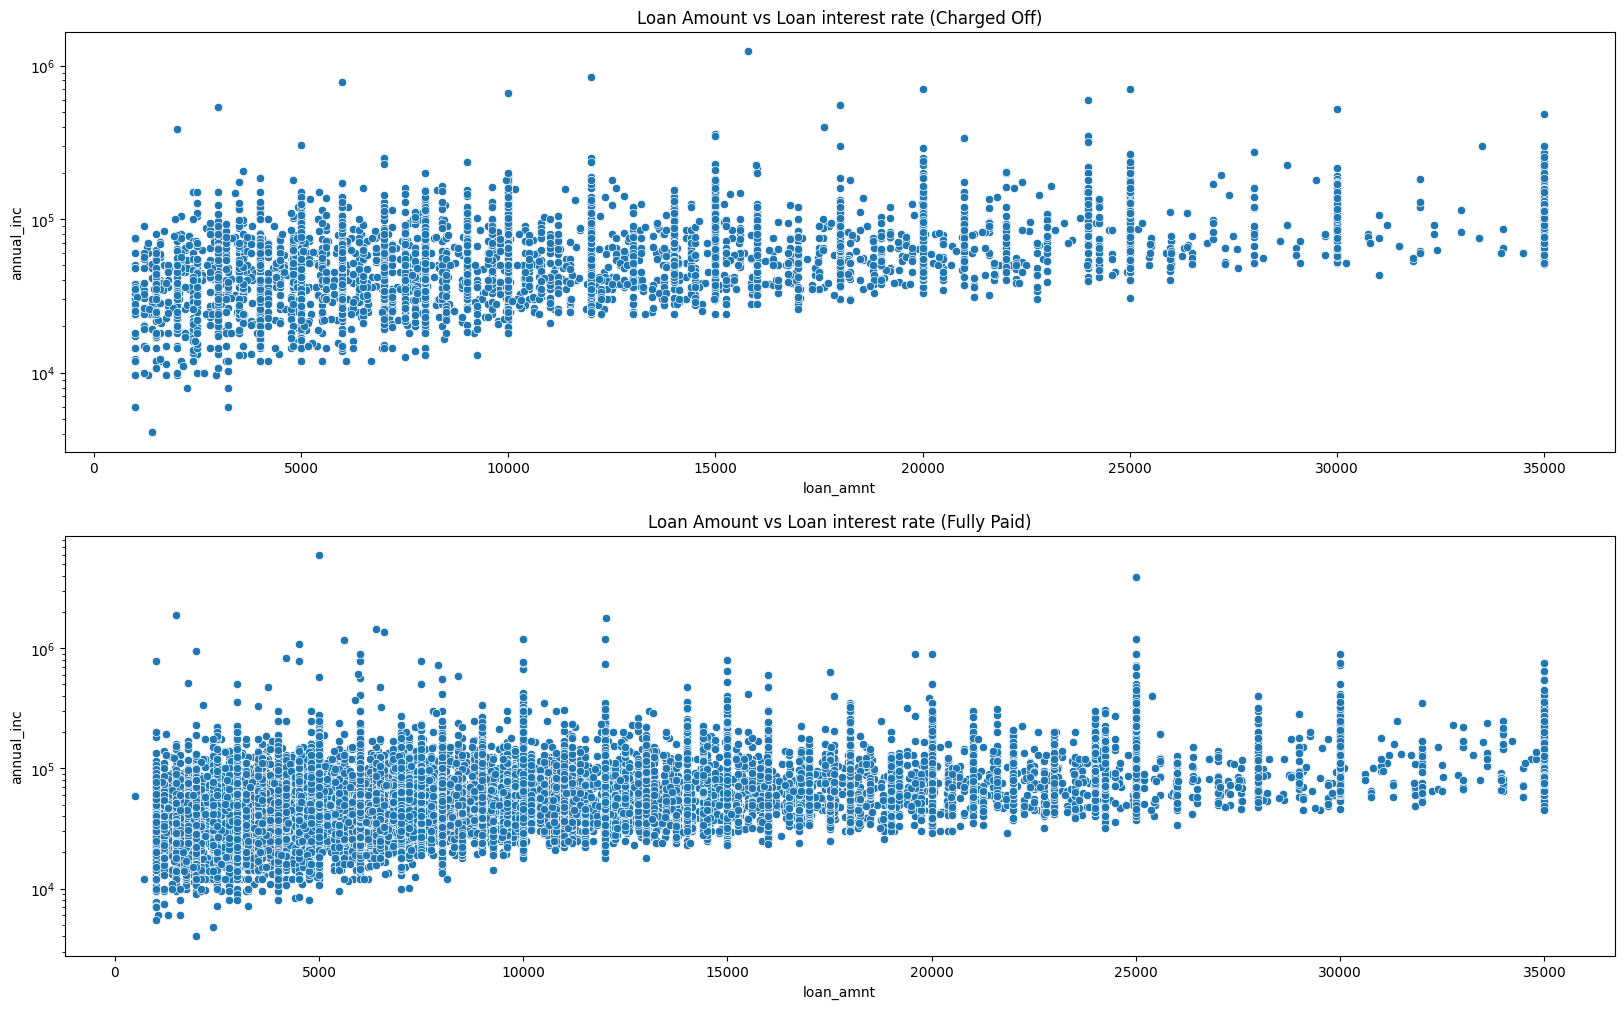

In [ ]:
#Loan Amount vs Annual income
plt.figure(figsize=(20,12))
plt.subplot(211)
sns.scatterplot(x='loan_amnt', y='annual_inc', data=loan_data[loan_data.loan_status == 'Charged Off'])
plt.yscale('log')
plt.title('Loan Amount vs Loan interest rate (Charged Off)')
plt.subplot(212)
sns.scatterplot(x='loan_amnt', y='annual_inc', data=loan_data[loan_data.loan_status == 'Fully Paid'])
plt.yscale('log')
plt.title('Loan Amount vs Loan interest rate (Fully Paid)')
plt.show()

Observations
Both Fully paid and Charged Off loans are having similar pattern versus Annual income. We can fit a linear patter with a line which has very much less slope.

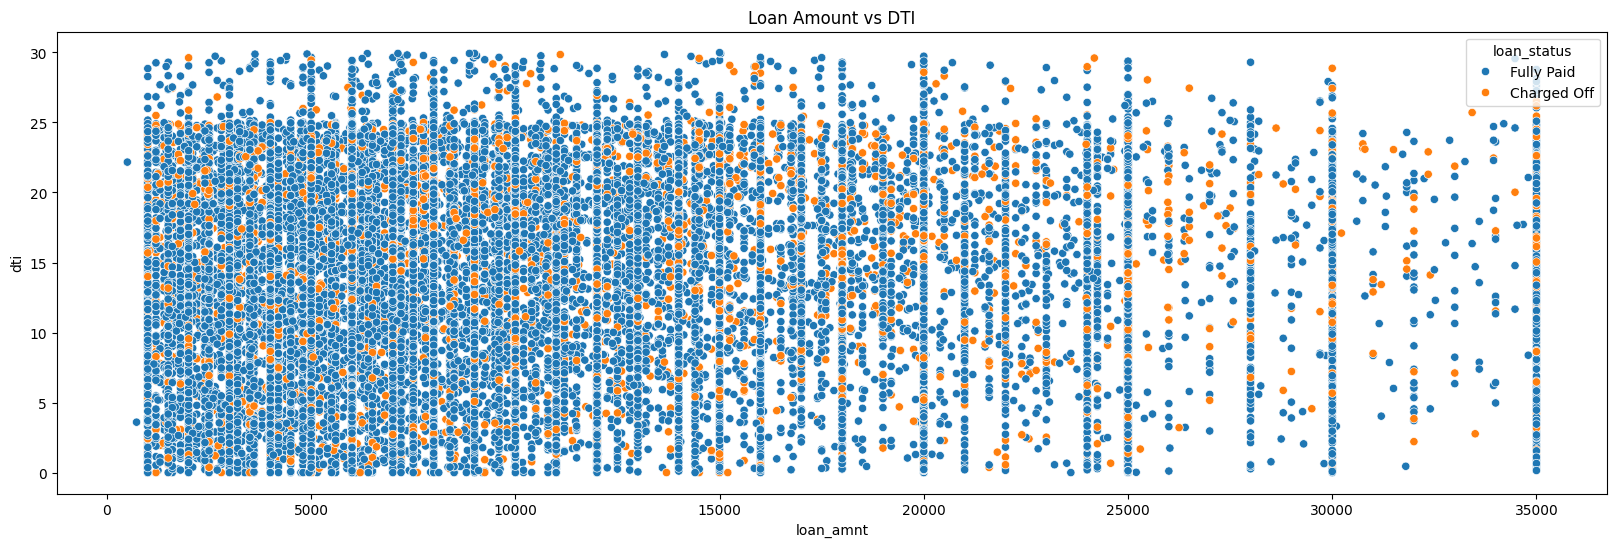

In [ ]:
#Loan Amount vs DTI
plt.figure(figsize=(20,6))
sns.scatterplot(x='loan_amnt', y='dti', data=loan_data, hue='loan_status')
plt.title('Loan Amount vs DTI')
plt.show()

Observartions:
Values are pretty much spread accross all the space. There is not specific pattern found in the spread.

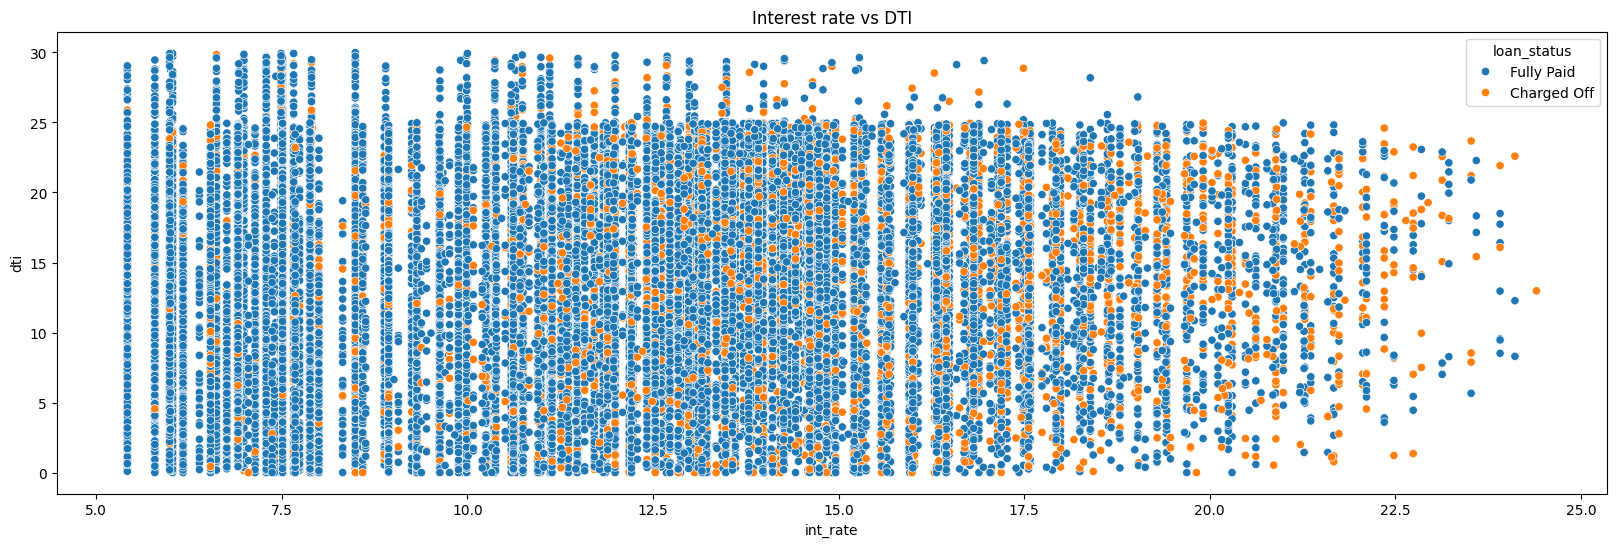

In [ ]:
#Interest Rate vs DTI
plt.figure(figsize=(20,6))
sns.scatterplot(x='int_rate', y='dti', data=loan_data, hue='loan_status')
plt.title('Interest rate vs DTI')
plt.show()

Observations
Values are spread all accross, but we can see one thing here irrespective of DTI when interest rates are high charged off loans are high.

In [ ]:


new_df2 = loan_data.drop(columns=['grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'loan_status', 'purpose', 'zip_code','addr_state', 'term', 'earliest_cr_line_month', 'issue_d_month'])

new_df2.head(5)


,id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,total_pymnt_inv,last_pymnt_amnt,pub_rec_bankruptcies,approved_loan_amnt_ratio,issue_d_year,issue_d_weekday,earliest_cr_line_year
0,1077501,5000,5000,4975.00,10.65,162.87,24000.00,2011-12-01,27.65,0,1985-01-01,1,3,0,13648,83.70,9,5863.16,5833.84,171.62,0.00,99.50,2011,3,1985
1,1077430,2500,2500,2500.00,15.27,59.83,30000.00,2011-12-01,1.00,0,1999-04-01,5,3,0,1687,9.40,4,1008.71,1008.71,119.66,0.00,100.00,2011,3,1999
2,1077175,2400,2400,2400.00,15.96,84.33,12252.00,2011-12-01,8.72,0,2001-11-01,2,2,0,2956,98.50,10,3005.67,3005.67,649.91,0.00,100.00,2011,3,2001
3,1076863,10000,10000,10000.00,13.49,339.31,49200.00,2011-12-01,20.00,0,1996-02-01,1,10,0,5598,21.00,37,12231.89,12231.89,357.48,0.00,100.00,2011,3,1996
5,1075269,5000,5000,5000.00,7.90,156.46,36000.00,2011-12-01,11.20,0,2004-11-01,3,9,0,7963,28.30,12,5632.21,5632.21,161.03,0.00,100.00,2011,3,2004


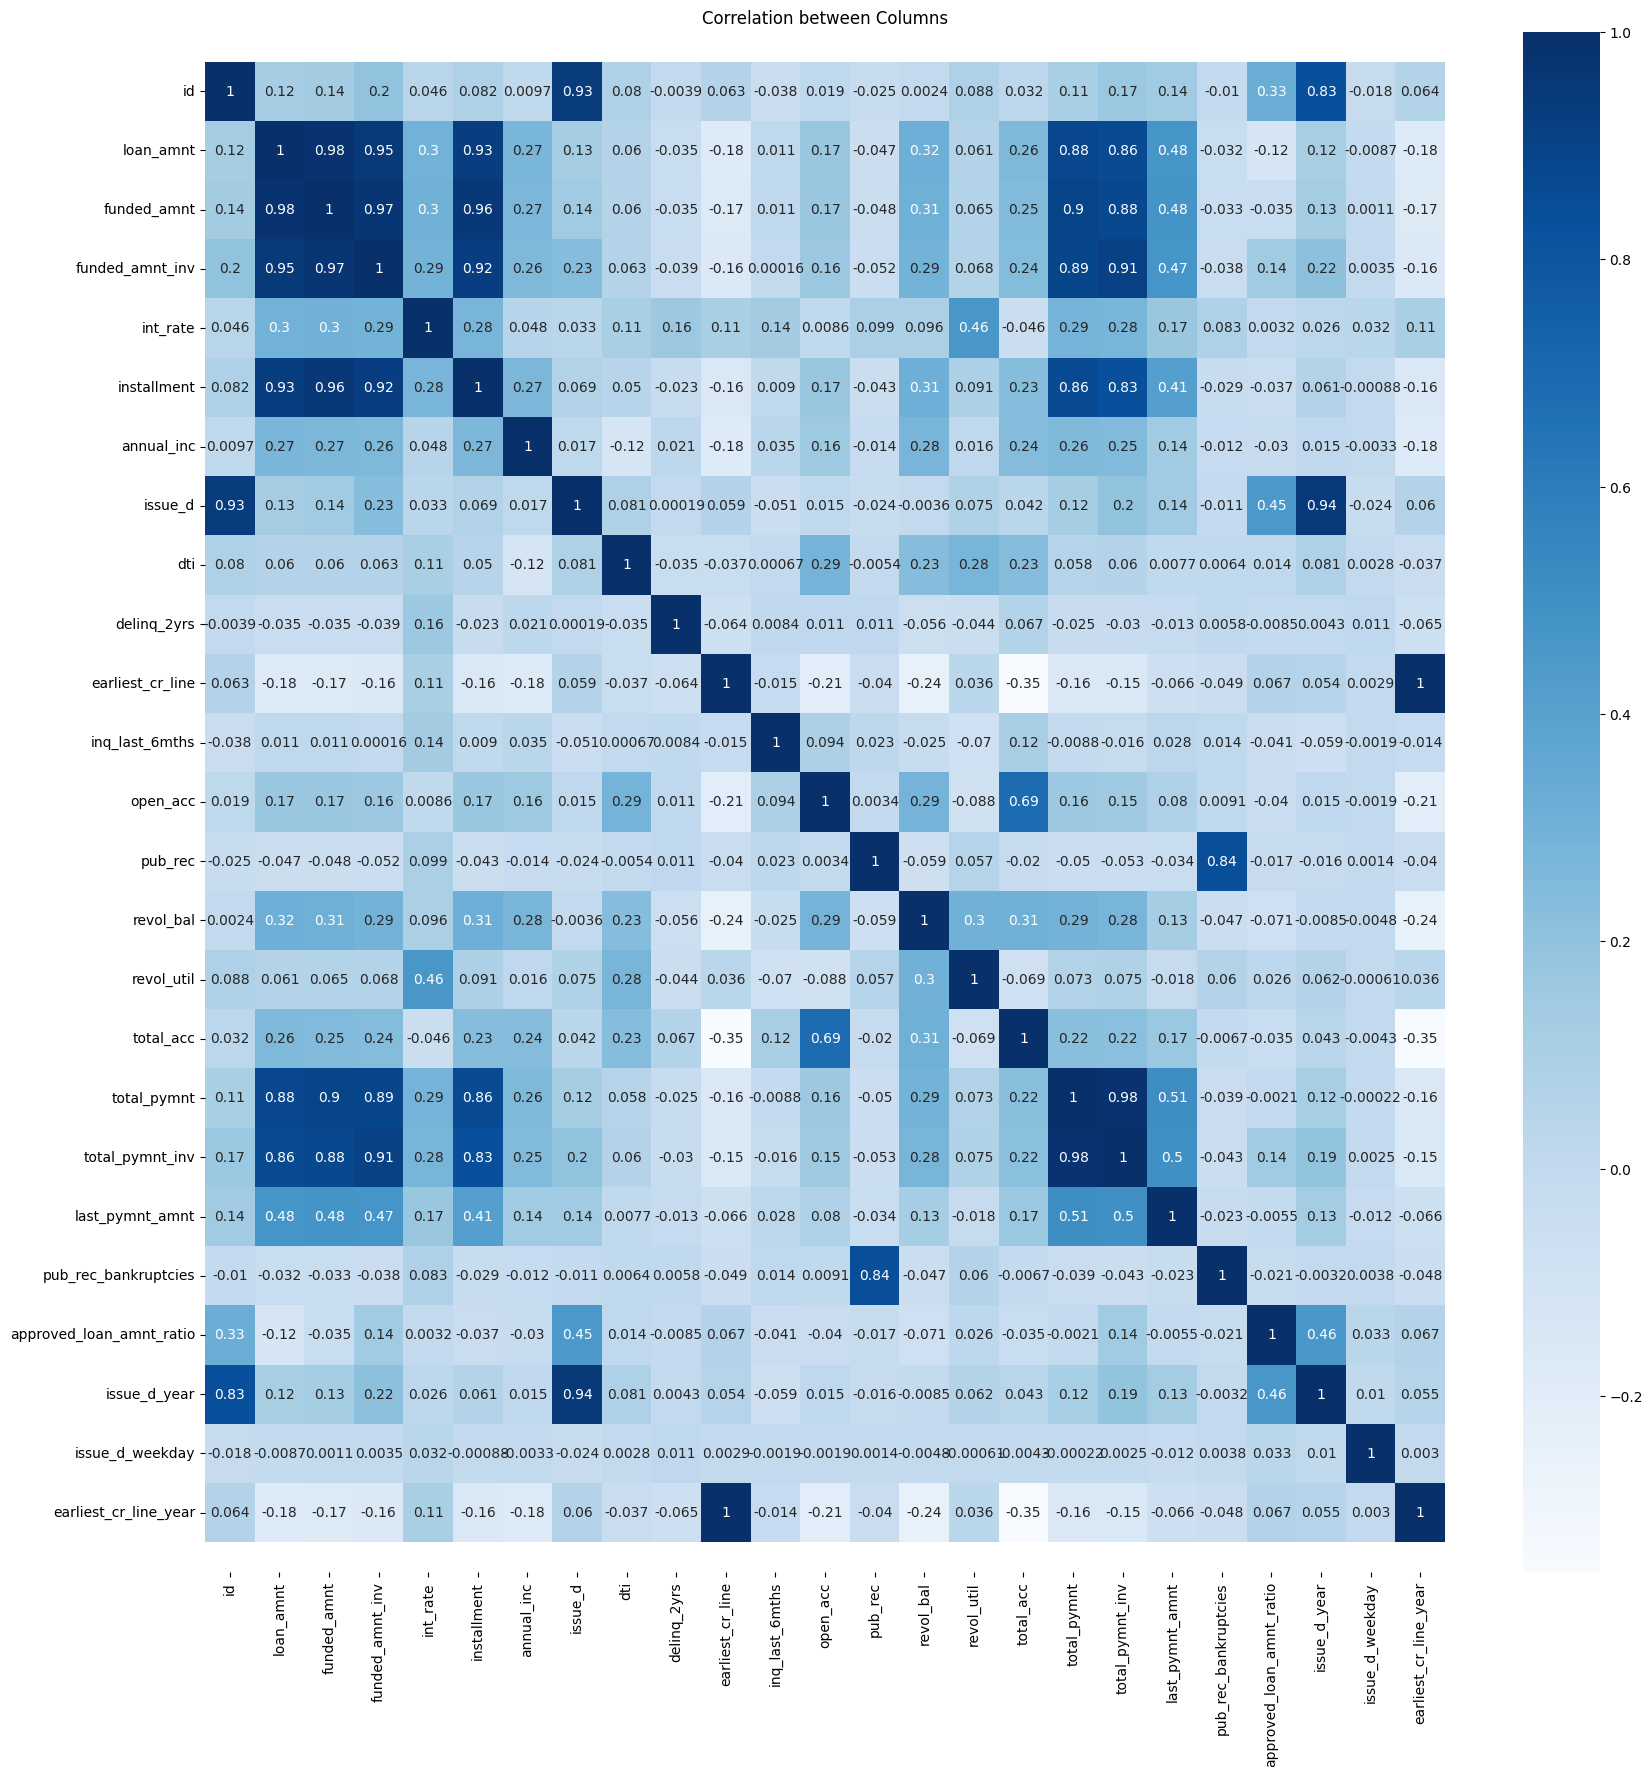

In [ ]:
corr_matrix = new_df2.corr()
plt.figure(figsize=(20,20))
#plotting correlatioon matric on a heat map
ax = sns.heatmap(corr_matrix, annot = True, cmap='Blues')
top, bottom = ax.get_ylim()
ax.set_ylim(top+0.5, bottom-0.5)
plt.title("Correlation between Columns")
plt.show()

Observations:

    Strong Positive Correlations:

    Loan Amount, Funded Amount, Funded Amount Inv: These variables are highly correlated, as expected, since they represent different aspects of the loan amount.
    Total Payment, Total Payment Inv: Similarly, these variables are strongly correlated, indicating a direct relationship between the total amount paid and the total amount invested.

    Moderate Positive Correlations:

    Loan Amount, Interest Rate: There's a moderate positive correlation, suggesting that larger loans might have higher interest rates.
    Installment, Loan Amount: A larger loan amount typically corresponds to higher installments.

    Weak or No Correlations:

    Public Records Bankruptcies, Interest Rate: There's a weak correlation or no correlation between these variables, indicating that bankruptcy history doesn't significantly influence interest rates.

Specific Observations

    Interest Rate: While it has moderate positive correlations with loan amount and installment, it doesn't seem to be strongly correlated with other variables.
    Delinquency: Delinquency (delinq_2yrs) doesn't have strong correlations with most other variables, suggesting it might be a relatively independent factor.
    Public Records Bankruptcies: As mentioned earlier, it doesn't seem to be strongly correlated with interest rates.



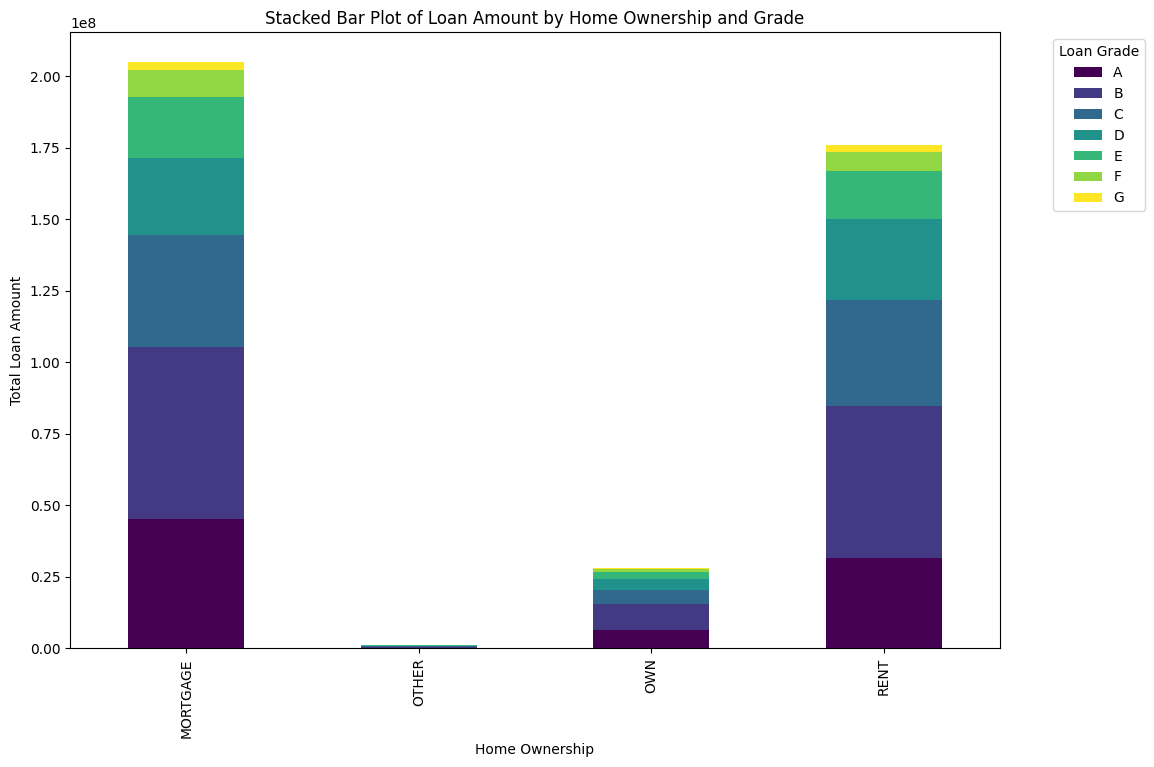

In [ ]:
# Group the data by 'home_ownership' and 'grade' and sum the 'loan_amnt'
grouped_data = loan_data.groupby(['home_ownership', 'grade'])['loan_amnt'].sum().unstack()

# Create the stacked bar plot
plt.figure(figsize=(12, 8))
grouped_data.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Stacked Bar Plot of Loan Amount by Home Ownership and Grade')
plt.xlabel('Home Ownership')
plt.ylabel('Total Loan Amount')
plt.legend(title='Loan Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


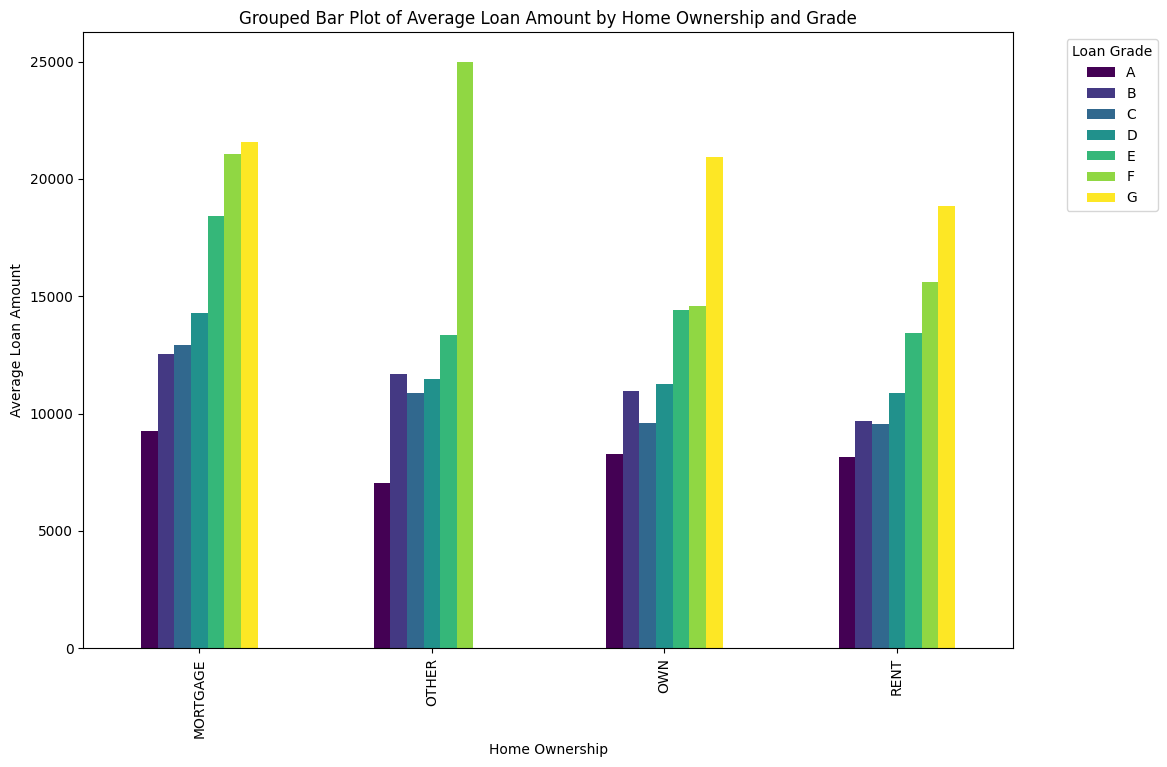

In [ ]:
# Group the data by 'home_ownership' and 'grade' and calculate the mean 'loan_amnt'
grouped_mean_data = loan_data.groupby(['home_ownership', 'grade'])['loan_amnt'].mean().unstack()

# Create the grouped bar plot
plt.figure(figsize=(12, 8))
grouped_mean_data.plot(kind='bar', colormap='viridis', ax=plt.gca())
plt.title('Grouped Bar Plot of Average Loan Amount by Home Ownership and Grade')
plt.xlabel('Home Ownership')
plt.ylabel('Average Loan Amount')
plt.legend(title='Loan Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
# Create a pivot table to summarize the mean loan amount by home ownership and grade
pivot_table = loan_data.pivot_table(values='loan_amnt', index='home_ownership', columns='grade', aggfunc='mean')

# Display the pivot table with headers
pivot_table

grade,A,B,C,D,E,F,G
home_ownership,,,,,,,
MORTGAGE,9257.58,12539.57,12941.25,14285.89,18430.08,21044.00,21572.01
OTHER,7019.79,11704.84,10875.00,11467.65,13350.00,25000.00,NaN
OWN,8261.05,10964.84,9581.89,11250.30,14401.70,14603.02,20921.25
RENT,8141.90,9696.39,9536.16,10869.45,13420.10,15615.68,18843.75


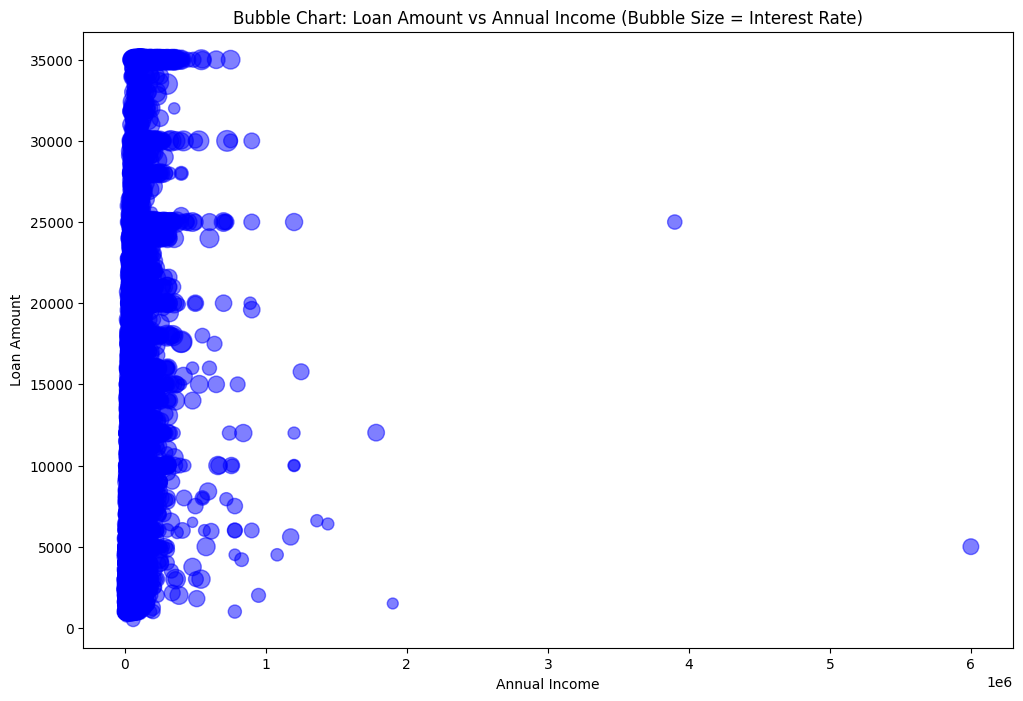

In [ ]:
# Create a bubble chart
plt.figure(figsize=(12, 8))
plt.scatter(loan_data['annual_inc'], loan_data['loan_amnt'], s=loan_data['int_rate']*10, alpha=0.5, color='blue')
plt.title('Bubble Chart: Loan Amount vs Annual Income (Bubble Size = Interest Rate)')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.show()

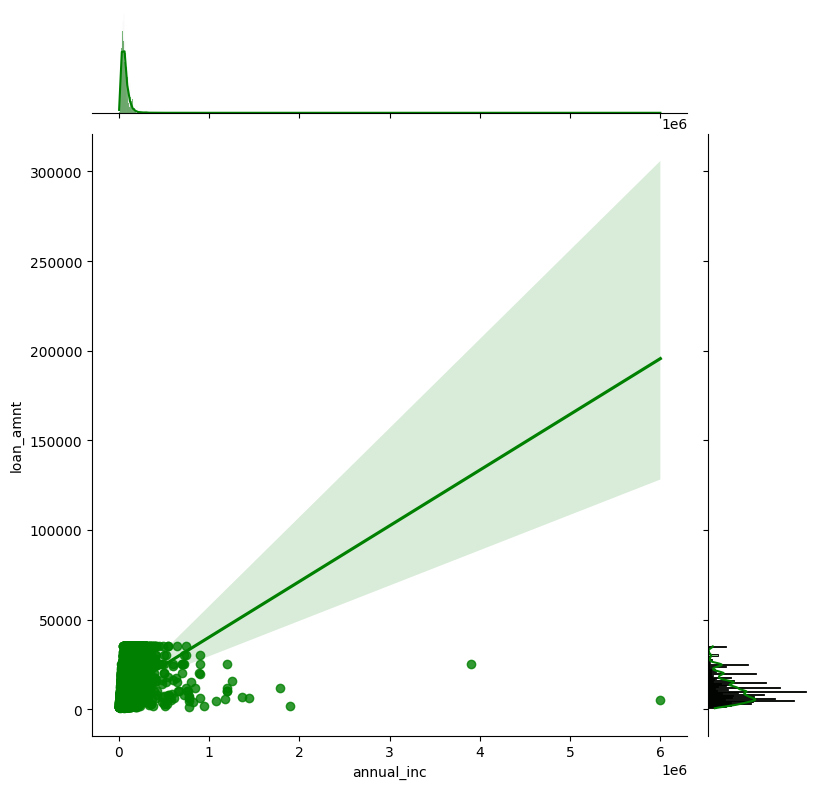

In [ ]:
# Create a joint plot of annual income and loan amount
sns.jointplot(x='annual_inc', y='loan_amnt', data=loan_data, kind='reg', height=8, color='g')

# Show the plot
plt.show()


Scatter Plot (Main Area):

    X-Axis (annual_inc): Represents the annual income, ranging from 0 to about 6 million (noted as 1e6 on the axis).
    Y-Axis (loan_amnt): Represents the loan amount, ranging from 0 to about 300,000. Each point in the scatter plot represents an individual data point corresponding to a borrower's annual income and loan amount.

Linear Regression Line:¶

    The green line running diagonally across the scatter plot represents a linear regression line. This line shows the best fit for the relationship between annual income and loan amount.
    Shaded Area: The shaded area around the regression line represents the confidence interval. This indicates the uncertainty around the estimated relationship. A wider interval suggests more variability in the data.

Marginal Distributions:

    Top Plot (X-axis): A histogram showing the distribution of annual incomes across all data points. It shows that most borrowers have annual incomes clustered towards the lower end (close to 0).
    Right Plot (Y-axis): A similar plot showing the distribution of loan amounts. Most loan amounts are concentrated at the lower end, with fewer larger loans.

Interpretation:
Relationship Between Loan Amount and Annual Income:

    The scatter plot shows that there is a positive relationship between annual income and loan amount: as annual income increases, the loan amount tends to increase as well. This is evident from the upward slope of the regression line.
    However, the scatter of data points is quite dense near the lower end of both variables, indicating that most borrowers have lower incomes and take out smaller loans.

Confidence Interval:

The confidence interval around the regression line is relatively wide, especially as annual income increases. This suggests that there is considerable variability in the relationship between annual income and loan amount. In other words, while there is a general trend of higher income leading to higher loan amounts, it is not a very strong or consistent relationship.
Marginal Distributions:

    The distribution of annual income (top plot) is heavily skewed to the left, with most data points concentrated near lower income levels.
    The distribution of loan amounts (right plot) is similarly skewed, with most loans being smaller amounts. This aligns with the scatter plot, where most points are concentrated in the lower-left corner of the chart.

Outliers:

There are a few outliers in the scatter plot where individuals with very high annual incomes (above 4 million) have taken out relatively small loans (below 50,000). These points are far from the regression line, indicating that they do not follow the general trend.
Overall Observation:

The chart provides a visual summary of the relationship between annual income and loan amount. While there is a positive correlation, as indicated by the upward-sloping regression line, the relationship is not particularly strong, with a lot of variability in the data. The concentration of data points at lower income and loan amounts suggests that most borrowers have modest financial profiles, and the wide confidence interval indicates uncertainty in the exact nature of the relationship. The marginal distributions highlight the skewed nature of both annual income and loan amount distributions, with most values clustered towards the lower end.


Overall Observation:

The chart provides a visual summary of the relationship between annual income and loan amount. While there is a positive correlation, as indicated by the upward-sloping regression line, the relationship is not particularly strong, with a lot of variability in the data. The concentration of data points at lower income and loan amounts suggests that most borrowers have modest financial profiles, and the wide confidence interval indicates uncertainty in the exact nature of the relationship. The marginal distributions highlight the skewed nature of both annual income and loan amount distributions, with most values clustered towards the lower end.